# Final project: Time-series data and application to stock markets {-}

This project aims at familiarizing you with time-series data analysis and its application to stock markets. Datasets you will be working on are Nasdaq and Vietnam stock datasets.

### Submission {-}
The structure of submission folder should be organized as follows:

- ./\<StudentID>-project-notebook.ipynb: Jupyter notebook containing source code.
- ./\<StudentID>-project-report.pdf: project report.

The submission folder is named DL4AI-\<StudentID>-project (e.g., DL4AI-2012345-project) and then compressed with the same name.
    
### Evaluation {-}
Project evaluation will be conducted on how you accomplish the assignment requirements. You can refer to the project instruction slide deck for details.

### Deadline {-}
Please visit Canvas for details.

In [1]:
# Your code goes here

In [2]:
import zipfile
import os

# Unzip Nasdaq data
with zipfile.ZipFile("data_nasdaq_csv.zip", "r") as z:
    z.extractall("./nasdaq_data")

# Check structure
nasdaq_path = "./nasdaq_data"
all_items = os.listdir(nasdaq_path)
print(all_items[:10])

['csv', '__MACOSX']


In [3]:
import pandas as pd
import os

# Find all CSV files, excluding those from __MACOSX
csv_files = []
for root, dirs, files in os.walk(nasdaq_path):
    if '__MACOSX' in root:
        continue # Skip __MACOSX directory and its contents
    for f in files:
        if f.endswith(".csv"):
            csv_files.append(os.path.join(root, f))

print(f"Total companies: {len(csv_files)}")
print("Sample files:", csv_files[:5])

# Read one sample
if csv_files:
    df = pd.read_csv(csv_files[0])
    print("\n--- First few rows ---")
    print(df.head())
    print("\n--- Shape ---")
    print(df.shape)
    print("\n--- Column types ---")
    print(df.dtypes)
else:
    print("No CSV files found after filtering.")

Total companies: 1564
Sample files: ['./nasdaq_data/csv/MBCN.csv', './nasdaq_data/csv/UCTT.csv', './nasdaq_data/csv/ERII.csv', './nasdaq_data/csv/ALGN.csv', './nasdaq_data/csv/LAYN.csv']

--- First few rows ---
         Date        Low       Open  Volume       High      Close  \
0  27-02-2003  12.196564  12.196564       0  12.196564  12.196564   
1  28-02-2003  12.196564  12.196564       0  12.196564  12.196564   
2  03-03-2003  12.196564  12.196564       0  12.196564  12.196564   
3  04-03-2003  12.134862  12.134862    4862  12.319970  12.319970   
4  05-03-2003  12.134862  12.134862    4862  12.319970  12.319970   

   Adjusted Close  
0        6.335899  
1        6.335899  
2        6.335899  
3        6.400004  
4        6.400004  

--- Shape ---
(4984, 7)

--- Column types ---
Date               object
Low               float64
Open              float64
Volume              int64
High              float64
Close             float64
Adjusted Close    float64
dtype: object


In [4]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# ---- CONFIG ----
MIN_ROWS = 120          # only keep companies with enough data
WINDOW_SIZE = 60        # use 60 days to predict
FEATURES = ['Low', 'Open', 'High', 'Close', 'Adjusted Close', 'Volume']
TARGET = 'Close'

# ---- Load all valid companies ----
all_data = {}
for f in csv_files:
    try:
        df = pd.read_csv(f)
        df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
        df = df.sort_values('Date').reset_index(drop=True)
        if len(df) >= MIN_ROWS and not df[FEATURES].isnull().any().any():
            ticker = os.path.basename(f).replace('.csv', '')
            all_data[ticker] = df
    except:
        continue

print(f"Valid companies after filtering: {len(all_data)}")
print("Sample tickers:", list(all_data.keys())[:5])

Valid companies after filtering: 1411
Sample tickers: ['MBCN', 'UCTT', 'ERII', 'ALGN', 'ARTNA']


In [5]:
def make_dataset(df, window_size, features, target, train_ratio=0.7, val_ratio=0.15):
    data = df[features].values
    target_idx = features.index(target)

    # Scale
    scaler = MinMaxScaler()
    data_scaled = scaler.fit_transform(data)

    # Create sequences
    X, y = [], []
    for i in range(window_size, len(data_scaled)):
        X.append(data_scaled[i - window_size:i])
        y.append(data_scaled[i, target_idx])

    X, y = np.array(X), np.array(y)

    # Chronological split (no shuffle!)
    n = len(X)
    train_end = int(n * train_ratio)
    val_end = int(n * (train_ratio + val_ratio))

    X_train, y_train = X[:train_end], y[:train_end]
    X_val,   y_val   = X[train_end:val_end], y[train_end:val_end]
    X_test,  y_test  = X[val_end:], y[val_end:]

    return X_train, y_train, X_val, y_val, X_test, y_test, scaler

# Test on AAPL
df_aapl = all_data['AAPL']
X_train, y_train, X_val, y_val, X_test, y_test, scaler = make_dataset(
    df_aapl, WINDOW_SIZE, FEATURES, TARGET
)
print(f"X_train: {X_train.shape}, X_val: {X_val.shape}, X_test: {X_test.shape}")

X_train: (7370, 60, 6), X_val: (1580, 60, 6), X_test: (1580, 60, 6)


In [6]:
#Task 1.1
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

def build_lstm_model(window_size, n_features):
    model = Sequential([
        LSTM(64, return_sequences=True, input_shape=(window_size, n_features)),
        Dropout(0.2),
        LSTM(32, return_sequences=False),
        Dropout(0.2),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

# Build model
model = build_lstm_model(WINDOW_SIZE, len(FEATURES))
model.summary()

# Train
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 64)         │        18,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,625 (119.63 KB)

 Trainable params: 30,625 (119.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
231/231 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - loss: 9.2988e-06 - mae: 0.0017 - val_loss: 1.1969e-04 - val_mae: 0.0097
Epoch 2/50
231/231 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 3.0139e-06 - mae: 0.0011 - val_loss: 2.1877e-05 - val_mae: 0.0037
Epoch 3/50
231/231 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 2.3603e-06 - mae: 9.8503e-04 - val_loss: 1.6250e-05 - val_mae: 0.0031
Epoch 4/50
231/231 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 2.4176e-06 - mae: 0.0010 - val_loss: 1.5476e-05 - val_mae: 0.0030
Epoch 5/50
231/231 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 1.7963e-06 - mae: 8.6198e-04 - val_loss: 1.6697e-04 - val_mae: 0.0115
Epoch 6/50
231/231 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 2.0066e-06 - mae: 9.2136e-04 - val_loss: 2.1172e-05 - val_mae: 0.0038
Epoch 7/50
231/231 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 2.0293e-06 - mae: 9.3834e-04 - val_loss: 4.4426e-05 - val_mae: 0.0057
Epoch 8/50
231/231 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 1.9832e-06 - mae: 9.1655e-04 - val

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
MAE:  7.0750
RMSE: 11.2345


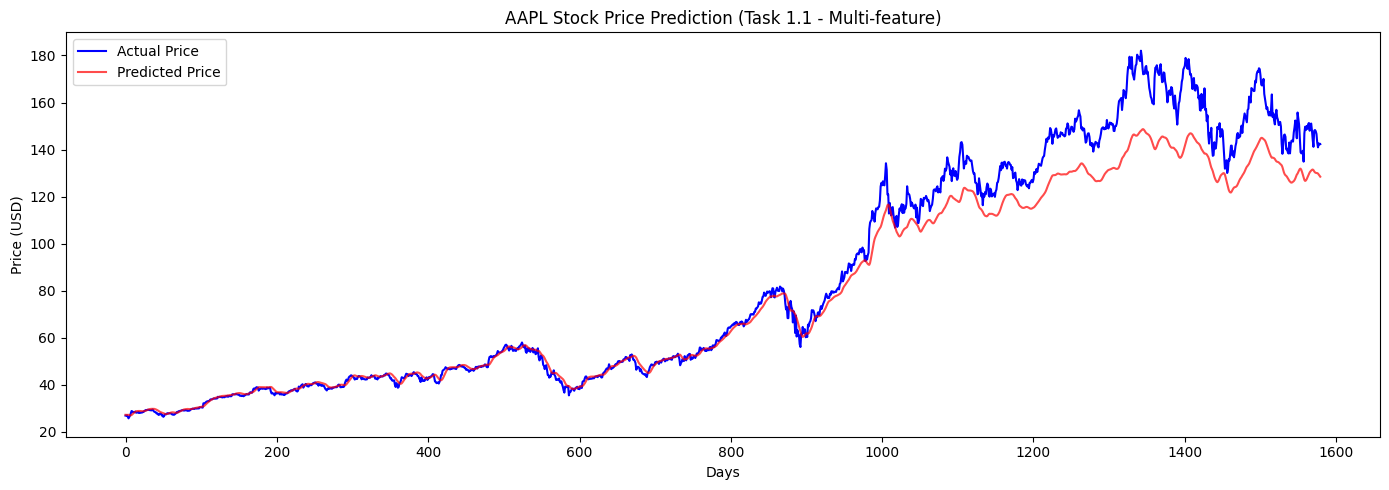

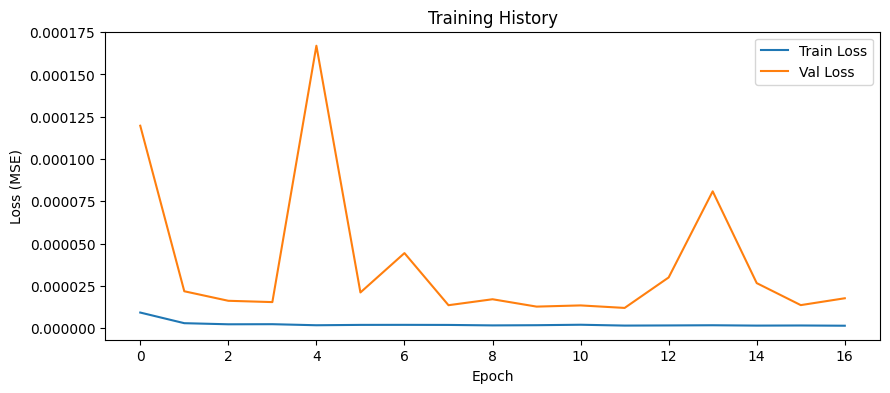

In [7]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Predict
y_pred = model.predict(X_test)

# Inverse transform to get real prices
# Build dummy array to inverse scale only Close column
target_idx = FEATURES.index(TARGET)

def inverse_scale(scaler, values, target_idx, n_features):
    dummy = np.zeros((len(values), n_features))
    dummy[:, target_idx] = values.flatten()
    return scaler.inverse_transform(dummy)[:, target_idx]

y_test_real = inverse_scale(scaler, y_test, target_idx, len(FEATURES))
y_pred_real = inverse_scale(scaler, y_pred, target_idx, len(FEATURES))

# Metrics
mae  = mean_absolute_error(y_test_real, y_pred_real)
rmse = np.sqrt(mean_squared_error(y_test_real, y_pred_real))
print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")

# Plot
plt.figure(figsize=(14, 5))
plt.plot(y_test_real, label='Actual Price', color='blue')
plt.plot(y_pred_real, label='Predicted Price', color='red', alpha=0.7)
plt.title('AAPL Stock Price Prediction (Task 1.1 - Multi-feature)')
plt.xlabel('Days')
plt.ylabel('Price (USD)')
plt.legend()
plt.tight_layout()
plt.show()

# Plot training history
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Training History')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.show()

Task 1.1 — Hyperparameter Tuning (Nasdaq / AAPL)
  units=32, lr=1e-03 ... 

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


val_loss=0.000015
  units=32, lr=5e-04 ... val_loss=0.000018
  units=64, lr=1e-03 ... val_loss=0.000014
  units=64, lr=5e-04 ... val_loss=0.000012
  units=128, lr=1e-03 ... val_loss=0.000012
  units=128, lr=5e-04 ... val_loss=0.000011

Kết quả hyperparameter search:
 units     lr  val_loss
   128 0.0005  0.000011
   128 0.0010  0.000012
    64 0.0005  0.000012
    64 0.0010  0.000014
    32 0.0010  0.000015
    32 0.0005  0.000018

Best: units=128, lr=5e-04


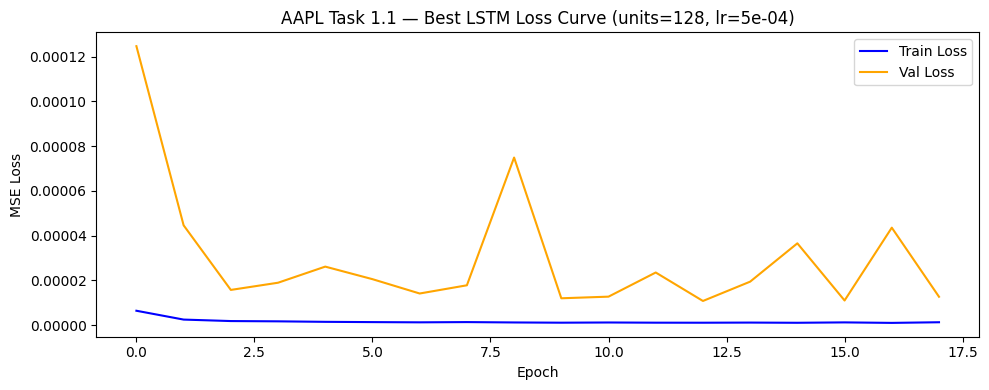

Best model — MAE: 3.3924 | RMSE: 5.3682


In [8]:
import itertools
import time
import matplotlib.pyplot as plt
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

def build_lstm_tunable(window_size, n_features, units=64, lr=1e-3):
    model = Sequential([
        LSTM(units, return_sequences=True,
             input_shape=(window_size, n_features)),
        Dropout(0.2),
        LSTM(units // 2, return_sequences=False),
        Dropout(0.2),
        Dense(1)
    ])
    model.compile(optimizer=Adam(learning_rate=lr), loss='mse', metrics=['mae'])
    return model

def plot_loss_curve(history, title):
    plt.figure(figsize=(10, 4))
    plt.plot(history.history['loss'],     label='Train Loss', color='blue')
    plt.plot(history.history['val_loss'], label='Val Loss',   color='orange')
    plt.title(title)
    plt.xlabel('Epoch')
    plt.ylabel('MSE Loss')
    plt.legend()
    plt.tight_layout()
    plt.show()

# Grid search: units x learning_rate
print("Task 1.1 — Hyperparameter Tuning (Nasdaq / AAPL)")
hp_results_1_1 = []
best_val_loss, best_config_1_1 = np.inf, None

for units, lr in itertools.product([32, 64, 128], [1e-3, 5e-4]):
    print(f"  units={units}, lr={lr:.0e} ...", end=" ")
    m = build_lstm_tunable(WINDOW_SIZE, len(FEATURES), units, lr)
    es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    hist = m.fit(X_train, y_train, validation_data=(X_val, y_val),
                 epochs=50, batch_size=32, callbacks=[es], verbose=0)
    vl = min(hist.history['val_loss'])
    print(f"val_loss={vl:.6f}")
    hp_results_1_1.append({'units': units, 'lr': lr, 'val_loss': vl})
    if vl < best_val_loss:
        best_val_loss = vl
        best_config_1_1 = {'units': units, 'lr': lr, 'model': m, 'history': hist}

df_hp_1_1 = pd.DataFrame(hp_results_1_1).sort_values('val_loss')
print("\nKết quả hyperparameter search:")
print(df_hp_1_1.round(6).to_string(index=False))
print(f"\nBest: units={best_config_1_1['units']}, lr={best_config_1_1['lr']:.0e}")

# Vẽ loss curve best model
plot_loss_curve(best_config_1_1['history'],
                f"AAPL Task 1.1 — Best LSTM Loss Curve "
                f"(units={best_config_1_1['units']}, lr={best_config_1_1['lr']:.0e})")

# Đánh giá best model
y_pred_best_1_1 = best_config_1_1['model'].predict(X_test, verbose=0)
y_te_real_1_1 = inverse_scale(scaler, y_test,           target_idx, len(FEATURES))
y_pr_real_1_1 = inverse_scale(scaler, y_pred_best_1_1,  target_idx, len(FEATURES))
print(f"Best model — MAE: {mean_absolute_error(y_te_real_1_1, y_pr_real_1_1):.4f} | "
      f"RMSE: {np.sqrt(mean_squared_error(y_te_real_1_1, y_pr_real_1_1)):.4f}")


Training model for k=3 (predict 3-th day ahead)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
k=3 | MAE: 5.2478 | RMSE: 8.1620


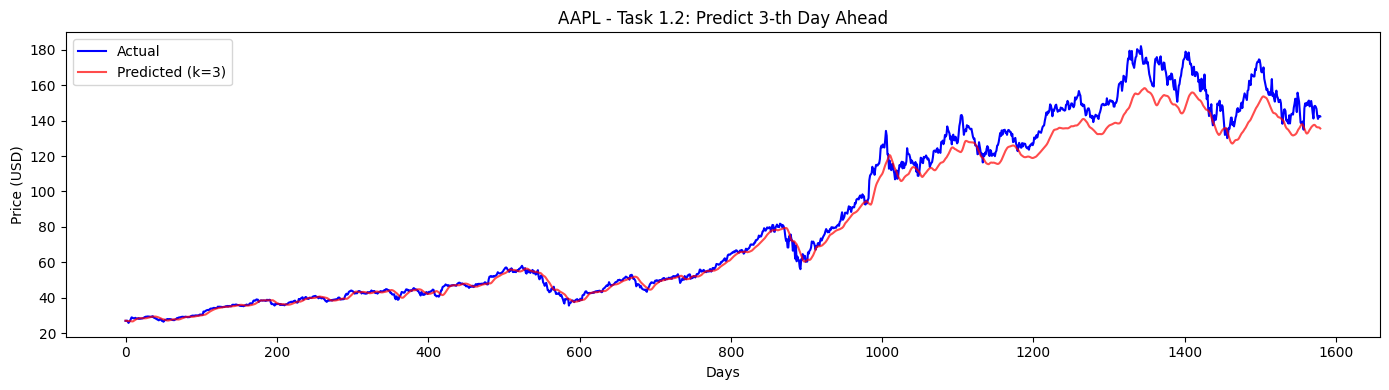


Training model for k=7 (predict 7-th day ahead)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
k=7 | MAE: 5.6952 | RMSE: 8.7687


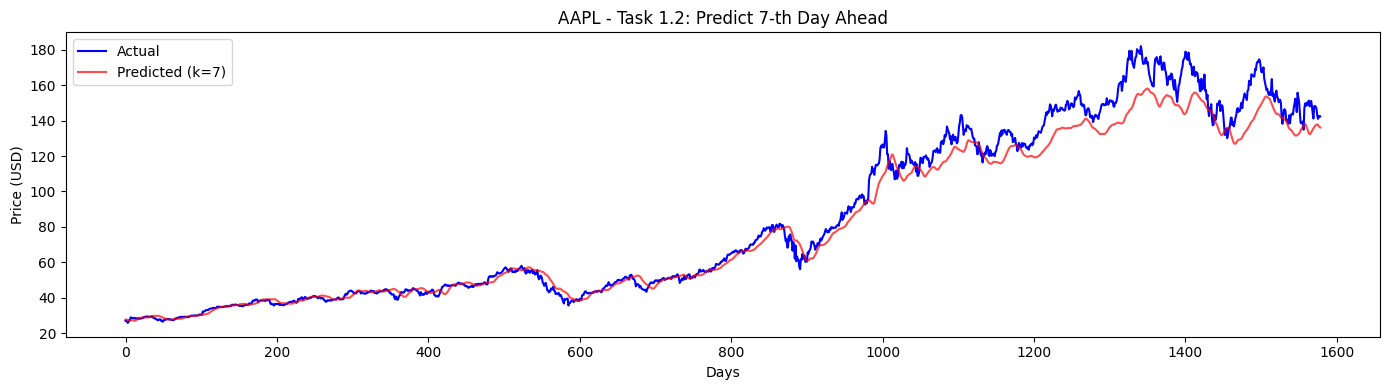

In [9]:
#Task 1.2
def make_dataset_kth_day(df, window_size, features, target, k=3,
                          train_ratio=0.7, val_ratio=0.15):
    """
    Predict the price k days ahead (only that single day, not consecutive).
    """
    data = df[features].values
    target_idx = features.index(target)

    scaler = MinMaxScaler()
    data_scaled = scaler.fit_transform(data)

    X, y = [], []
    for i in range(window_size, len(data_scaled) - k + 1):
        X.append(data_scaled[i - window_size:i])
        y.append(data_scaled[i + k - 1, target_idx])  # k-th day ahead

    X, y = np.array(X), np.array(y)

    n = len(X)
    train_end = int(n * train_ratio)
    val_end   = int(n * (train_ratio + val_ratio))

    return (X[:train_end], y[:train_end],
            X[train_end:val_end], y[train_end:val_end],
            X[val_end:], y[val_end:], scaler)

# ---- Test with k=3 and k=7 ----
for k in [3, 7]:
    print(f"\n{'='*40}")
    print(f"Training model for k={k} (predict {k}-th day ahead)")
    print('='*40)

    X_tr, y_tr, X_v, y_v, X_te, y_te, scaler_k = make_dataset_kth_day(
        df_aapl, WINDOW_SIZE, FEATURES, TARGET, k=k
    )

    model_k = build_lstm_model(WINDOW_SIZE, len(FEATURES))

    early_stop = EarlyStopping(monitor='val_loss', patience=5,
                                restore_best_weights=True)
    model_k.fit(
        X_tr, y_tr,
        validation_data=(X_v, y_v),
        epochs=50, batch_size=32,
        callbacks=[early_stop],
        verbose=0  # silent
    )

    # Evaluate
    y_pred_k = model_k.predict(X_te)
    y_te_real = inverse_scale(scaler_k, y_te, target_idx, len(FEATURES))
    y_pr_real = inverse_scale(scaler_k, y_pred_k, target_idx, len(FEATURES))

    mae  = mean_absolute_error(y_te_real, y_pr_real)
    rmse = np.sqrt(mean_squared_error(y_te_real, y_pr_real))
    print(f"k={k} | MAE: {mae:.4f} | RMSE: {rmse:.4f}")

    # Plot
    plt.figure(figsize=(14, 4))
    plt.plot(y_te_real, label='Actual', color='blue')
    plt.plot(y_pr_real, label=f'Predicted (k={k})', color='red', alpha=0.7)
    plt.title(f'AAPL - Task 1.2: Predict {k}-th Day Ahead')
    plt.xlabel('Days')
    plt.ylabel('Price (USD)')
    plt.legend()
    plt.tight_layout()
    plt.show()

Task 1.2 — N-th Day Forecast với best hyperparams


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


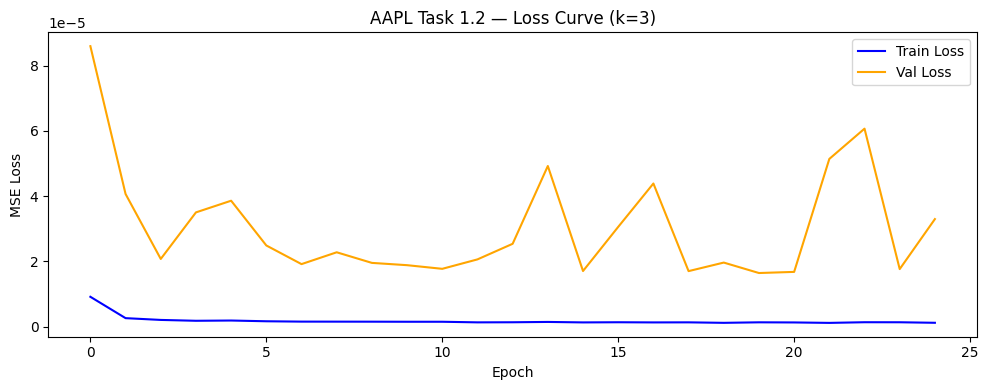

k=3 | MAE=2.6104 | RMSE=4.0351


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


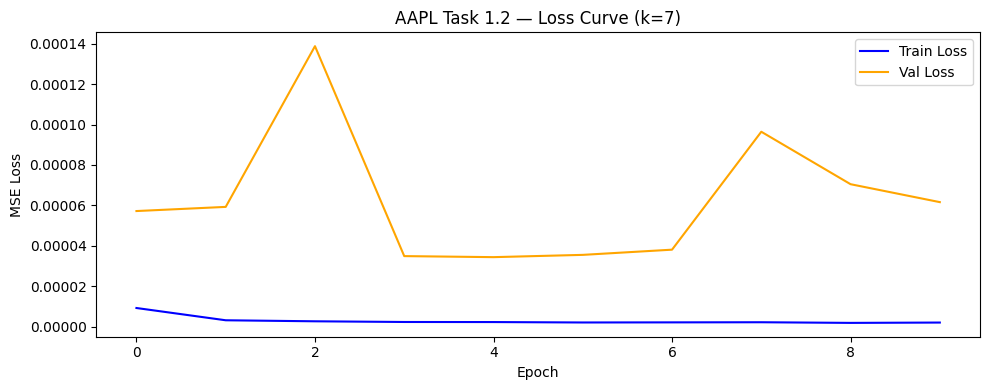

k=7 | MAE=4.8870 | RMSE=7.3976


In [10]:
print("Task 1.2 — N-th Day Forecast với best hyperparams")
for k in [3, 7]:
    X_tr2, y_tr2, X_v2, y_v2, X_te2, y_te2, sc2 = make_dataset_kth_day(
        df_aapl, WINDOW_SIZE, FEATURES, TARGET, k=k
    )
    m2 = build_lstm_tunable(WINDOW_SIZE, len(FEATURES),
                             units=best_config_1_1['units'],
                             lr=best_config_1_1['lr'])
    es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    hist2 = m2.fit(X_tr2, y_tr2, validation_data=(X_v2, y_v2),
                   epochs=50, batch_size=32, callbacks=[es], verbose=0)

    plot_loss_curve(hist2, f"AAPL Task 1.2 — Loss Curve (k={k})")

    y_pred2  = m2.predict(X_te2, verbose=0)
    y_te_r2  = inverse_scale(sc2, y_te2,   target_idx, len(FEATURES))
    y_pr_r2  = inverse_scale(sc2, y_pred2, target_idx, len(FEATURES))
    print(f"k={k} | MAE={mean_absolute_error(y_te_r2, y_pr_r2):.4f} | "
          f"RMSE={np.sqrt(mean_squared_error(y_te_r2, y_pr_r2)):.4f}")


Training model for k=3 consecutive days


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
Average MAE:  7.0577
Average RMSE: 11.1466
  Day 1: MAE=6.6265, RMSE=10.5496
  Day 2: MAE=7.7119, RMSE=12.0681
  Day 3: MAE=6.8347, RMSE=10.8221


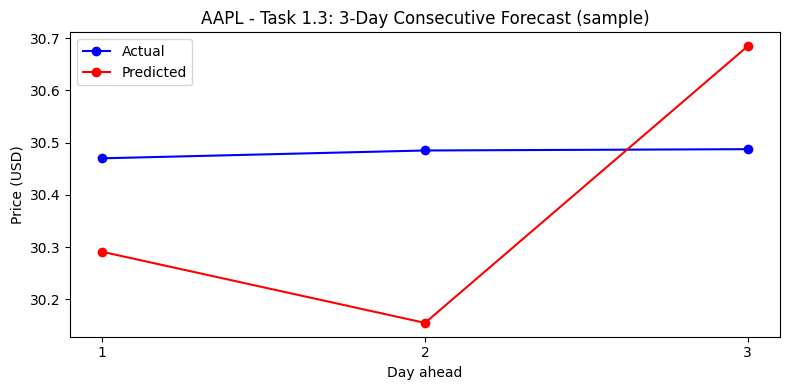


Training model for k=7 consecutive days


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
Average MAE:  8.1524
Average RMSE: 12.6682
  Day 1: MAE=8.2410, RMSE=12.9637
  Day 2: MAE=8.0866, RMSE=12.6545
  Day 3: MAE=8.4343, RMSE=13.0747
  Day 4: MAE=7.8751, RMSE=12.3132
  Day 5: MAE=7.9820, RMSE=12.3814
  Day 6: MAE=7.6674, RMSE=11.8680
  Day 7: MAE=8.7803, RMSE=13.4222


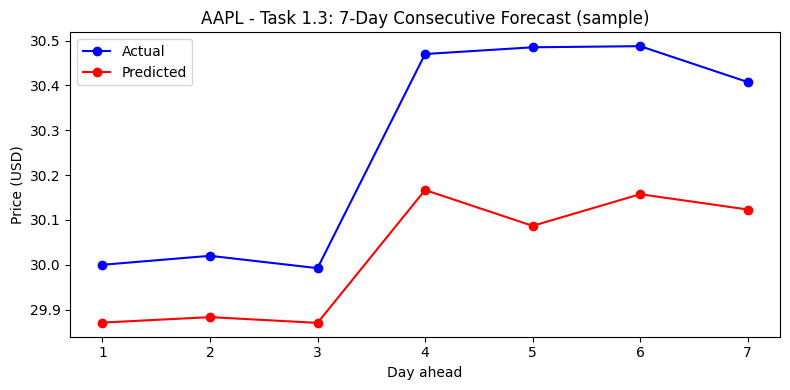

In [11]:
#task 1.3
from tensorflow.keras.layers import RepeatVector, TimeDistributed

def make_dataset_k_days(df, window_size, features, target, k=3,
                         train_ratio=0.7, val_ratio=0.15):
    """
    Predict k consecutive days ahead at once.
    Output shape: (samples, k)
    """
    data = df[features].values
    target_idx = features.index(target)

    scaler = MinMaxScaler()
    data_scaled = scaler.fit_transform(data)

    X, y = [], []
    for i in range(window_size, len(data_scaled) - k + 1):
        X.append(data_scaled[i - window_size:i])
        y.append(data_scaled[i:i + k, target_idx])  # next k days

    X, y = np.array(X), np.array(y)

    n = len(X)
    train_end = int(n * train_ratio)
    val_end   = int(n * (train_ratio + val_ratio))

    return (X[:train_end], y[:train_end],
            X[train_end:val_end], y[train_end:val_end],
            X[val_end:], y[val_end:], scaler)


def build_lstm_multi_output(window_size, n_features, k):
    """LSTM that outputs k values at once (multi-step forecast)"""
    model = Sequential([
        LSTM(64, return_sequences=True, input_shape=(window_size, n_features)),
        Dropout(0.2),
        LSTM(32, return_sequences=False),
        Dropout(0.2),
        Dense(k)  # output k days at once
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model


# ---- Test with k=3 and k=7 ----
for k in [3, 7]:
    print(f"\n{'='*40}")
    print(f"Training model for k={k} consecutive days")
    print('='*40)

    X_tr, y_tr, X_v, y_v, X_te, y_te, scaler_k = make_dataset_k_days(
        df_aapl, WINDOW_SIZE, FEATURES, TARGET, k=k
    )

    model_k = build_lstm_multi_output(WINDOW_SIZE, len(FEATURES), k)

    early_stop = EarlyStopping(monitor='val_loss', patience=5,
                                restore_best_weights=True)
    model_k.fit(
        X_tr, y_tr,
        validation_data=(X_v, y_v),
        epochs=50, batch_size=32,
        callbacks=[early_stop],
        verbose=0
    )

    # Evaluate - average across all k days
    y_pred_k = model_k.predict(X_te)  # shape: (samples, k)

    maes, rmses = [], []
    for day in range(k):
        y_te_real = inverse_scale(scaler_k, y_te[:, day], target_idx, len(FEATURES))
        y_pr_real = inverse_scale(scaler_k, y_pred_k[:, day], target_idx, len(FEATURES))
        maes.append(mean_absolute_error(y_te_real, y_pr_real))
        rmses.append(np.sqrt(mean_squared_error(y_te_real, y_pr_real)))

    print(f"Average MAE:  {np.mean(maes):.4f}")
    print(f"Average RMSE: {np.mean(rmses):.4f}")
    for day in range(k):
        print(f"  Day {day+1}: MAE={maes[day]:.4f}, RMSE={rmses[day]:.4f}")

    # Plot first test sample's k-day prediction vs actual
    sample_idx = 100
    y_te_sample = [inverse_scale(scaler_k, y_te[sample_idx:sample_idx+1, d],
                                  target_idx, len(FEATURES))[0] for d in range(k)]
    y_pr_sample = [inverse_scale(scaler_k, y_pred_k[sample_idx:sample_idx+1, d],
                                  target_idx, len(FEATURES))[0] for d in range(k)]

    plt.figure(figsize=(8, 4))
    plt.plot(range(1, k+1), y_te_sample, marker='o', label='Actual', color='blue')
    plt.plot(range(1, k+1), y_pr_sample, marker='o', label='Predicted', color='red')
    plt.title(f'AAPL - Task 1.3: {k}-Day Consecutive Forecast (sample)')
    plt.xlabel('Day ahead')
    plt.ylabel('Price (USD)')
    plt.xticks(range(1, k+1))
    plt.legend()
    plt.tight_layout()
    plt.show()

Task 1.3 — K Consecutive Days với best hyperparams


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


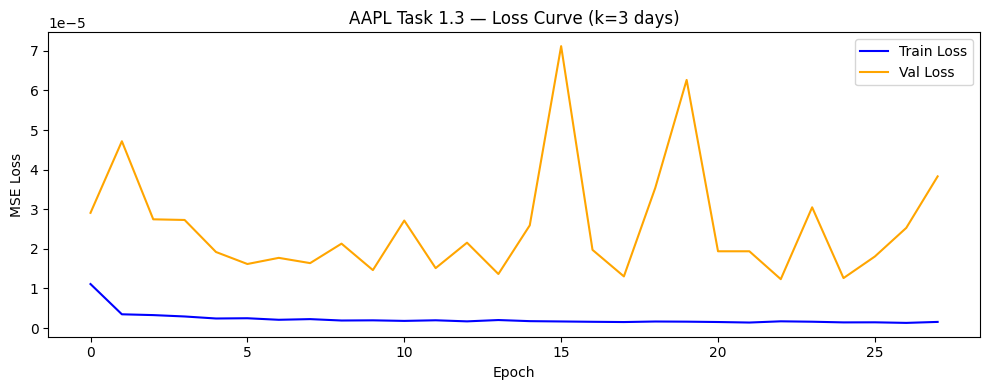

k=3 | Avg MAE=7.5486 | Avg RMSE=11.9830
  Day 1: MAE=7.3902, RMSE=11.8542
  Day 2: MAE=7.5328, RMSE=11.9628
  Day 3: MAE=7.7229, RMSE=12.1321


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


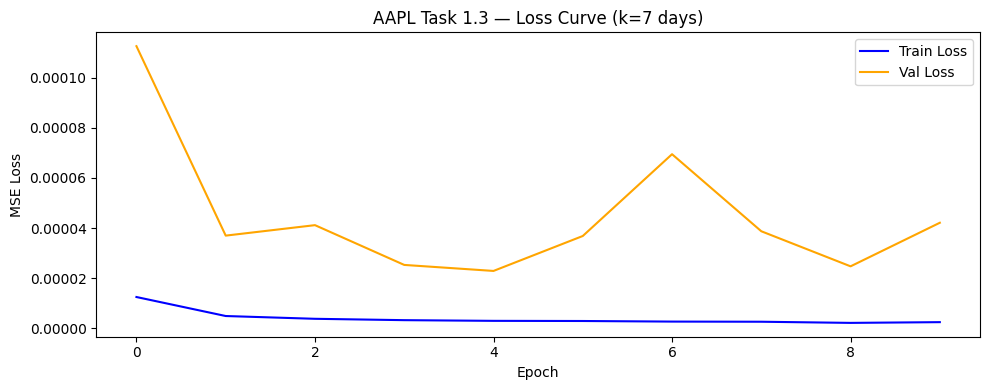

k=7 | Avg MAE=7.7675 | Avg RMSE=11.9384
  Day 1: MAE=6.5545, RMSE=10.4785
  Day 2: MAE=7.2665, RMSE=11.2588
  Day 3: MAE=8.4485, RMSE=12.9728
  Day 4: MAE=7.6732, RMSE=11.7261
  Day 5: MAE=8.3184, RMSE=12.5908
  Day 6: MAE=7.6523, RMSE=11.8323
  Day 7: MAE=8.4594, RMSE=12.7096


In [12]:
print("Task 1.3 — K Consecutive Days với best hyperparams")
for k in [3, 7]:
    X_tr3, y_tr3, X_v3, y_v3, X_te3, y_te3, sc3 = make_dataset_k_days(
        df_aapl, WINDOW_SIZE, FEATURES, TARGET, k=k
    )
    m3 = build_lstm_multi_output(WINDOW_SIZE, len(FEATURES), k)
    es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    hist3 = m3.fit(X_tr3, y_tr3, validation_data=(X_v3, y_v3),
                   epochs=50, batch_size=32, callbacks=[es], verbose=0)

    plot_loss_curve(hist3, f"AAPL Task 1.3 — Loss Curve (k={k} days)")

    y_pred3 = m3.predict(X_te3, verbose=0)
    maes, rmses = [], []
    for day in range(k):
        y_te_r3 = inverse_scale(sc3, y_te3[:, day], target_idx, len(FEATURES))
        y_pr_r3 = inverse_scale(sc3, y_pred3[:, day], target_idx, len(FEATURES))
        maes.append(mean_absolute_error(y_te_r3, y_pr_r3))
        rmses.append(np.sqrt(mean_squared_error(y_te_r3, y_pr_r3)))
    print(f"k={k} | Avg MAE={np.mean(maes):.4f} | Avg RMSE={np.mean(rmses):.4f}")
    for day in range(k):
        print(f"  Day {day+1}: MAE={maes[day]:.4f}, RMSE={rmses[day]:.4f}")

In [13]:
#task 2
# Unzip Vietnam data
with zipfile.ZipFile("data-vn-20230228.zip", "r") as z:
    z.extractall("./vn_data")

# Check folder structure
for root, dirs, files in os.walk("./vn_data"):
    print(root)
    if files:
        print("  Files:", files[:5])
    if len(dirs) > 0:
        print("  Dirs:", dirs[:5])

./vn_data
  Files: ['companies.csv', 'ticker-overview.csv', 'crawl-vn-data.ipynb']
  Dirs: ['financial-ratio', 'stock-historical-data', 'industry-analysis', 'dividend-history', '__MACOSX']
./vn_data/financial-ratio
  Files: ['TPC-VNINDEX-Finance.csv', 'PSW-HNXIndex-Finance.csv', 'PDV-UpcomIndex-Finance.csv', 'HBD-UpcomIndex-Finance.csv', 'HEM-UpcomIndex-Finance.csv']
./vn_data/stock-historical-data
  Files: ['CLM-HNXIndex-History.csv', 'DTP-UpcomIndex-History.csv', 'SHB-VNINDEX-History.csv', 'DVP-VNINDEX-History.csv', 'VTG-UpcomIndex-History.csv']
./vn_data/industry-analysis
  Files: ['CMK-UpcomIndex-Industry.csv', 'DSV-UpcomIndex-Industry.csv', 'STT-UpcomIndex-Industry.csv', 'SNC-UpcomIndex-Industry.csv', 'THB-HNXIndex-Industry.csv']
./vn_data/dividend-history
  Files: ['DXV-VNINDEX-Dividend.csv', 'KTU-UpcomIndex-Dividend.csv', 'BCB-UpcomIndex-Dividend.csv', 'CMG-VNINDEX-Dividend.csv', 'DNA-UpcomIndex-Dividend.csv']
./vn_data/__MACOSX
  Files: ['._crawl-vn-data.ipynb']
  Dirs: ['stock

In [14]:
import glob

vn_stock_path = "./vn_data"

# Find the stock-historical-data folder
stock_files = glob.glob(f"{vn_stock_path}/**/stock-historical-data/**/*.csv",
                         recursive=True)
if not stock_files:
    # Try another pattern
    stock_files = glob.glob(f"{vn_stock_path}/**/*.csv", recursive=True)

print(f"Total Vietnam stock files: {len(stock_files)}")
print("Sample files:", stock_files[:5])

# Read one sample
df_vn = pd.read_csv(stock_files[0])
print("\n--- First few rows ---")
print(df_vn.head())
print("\n--- Columns ---")
print(df_vn.dtypes)

Total Vietnam stock files: 1629
Sample files: ['./vn_data/stock-historical-data/CLM-HNXIndex-History.csv', './vn_data/stock-historical-data/DTP-UpcomIndex-History.csv', './vn_data/stock-historical-data/SHB-VNINDEX-History.csv', './vn_data/stock-historical-data/DVP-VNINDEX-History.csv', './vn_data/stock-historical-data/VTG-UpcomIndex-History.csv']

--- First few rows ---
   Unnamed: 0     Open    High     Low   Close  Volume TradingDate
0           0  13831.0  9682.0  5213.0  7448.0    1400  2016-04-15
1           1   7448.0  7448.0  7448.0  7448.0       0  2016-04-19
2           2   7448.0  7448.0  7448.0  7448.0       0  2016-04-20
3           3   8179.0  8179.0  8179.0  8179.0     100  2016-04-21
4           4   8179.0  8179.0  8179.0  8179.0       0  2016-04-22

--- Columns ---
Unnamed: 0       int64
Open           float64
High           float64
Low            float64
Close          float64
Volume           int64
TradingDate     object
dtype: object


In [15]:
VN_FEATURES = ['Open', 'High', 'Low', 'Close', 'Volume']
VN_TARGET = 'Close'

# Load all valid Vietnam companies
vn_all_data = {}
for f in stock_files:
    try:
        df = pd.read_csv(f)
        # Rename TradingDate to Date for consistency
        if 'TradingDate' in df.columns:
            df = df.rename(columns={'TradingDate': 'Date'})
        df['Date'] = pd.to_datetime(df['Date'])
        df = df.sort_values('Date').reset_index(drop=True)
        df = df.dropna(subset=VN_FEATURES)

        # Filter out rows with 0 volume or 0 price
        df = df[(df['Volume'] > 0) & (df['Close'] > 0)]

        if len(df) >= MIN_ROWS:
            ticker = os.path.basename(f).replace('.csv', '').replace('-History', '')
            vn_all_data[ticker] = df
    except:
        continue

print(f"Valid Vietnam companies after filtering: {len(vn_all_data)}")
print("Sample tickers:", list(vn_all_data.keys())[:10])

Valid Vietnam companies after filtering: 1446
Sample tickers: ['CLM-HNXIndex', 'DTP-UpcomIndex', 'SHB-VNINDEX', 'DVP-VNINDEX', 'VTG-UpcomIndex', 'X26-UpcomIndex', 'ISH-UpcomIndex', 'SGN-VNINDEX', 'TTT-HNXIndex', 'VLB-UpcomIndex']


In [16]:
# Select one representative per industry
INDUSTRY_PICKS = {
    'Steel/Materials': ['HPG', 'HSG', 'NKG'],
    'Tech/Telecom':    ['FPT', 'CMG', 'VGI'],
    'Consumer/FMCG':   ['VNM', 'MSN', 'SAB'],
    'Real Estate':     ['VIC', 'VHM', 'NVL'],
    'Banking':         ['VCB', 'BID', 'CTG'],
}

selected_tickers = []
for industry, tickers in INDUSTRY_PICKS.items():
    for t in tickers:
        match = [k for k in vn_all_data.keys() if t in k.upper()]
        if match:
            selected_tickers.append((industry, t, match[0]))
            break

print("\nSelected representative companies:")
for industry, ticker, key in selected_tickers:
    print(f"  [{industry}] {ticker}: {len(vn_all_data[key])} rows")


Selected representative companies:
  [Steel/Materials] HPG: 3807 rows
  [Tech/Telecom] FPT: 4036 rows
  [Consumer/FMCG] VNM: 4262 rows
  [Real Estate] VIC: 3848 rows
  [Banking] VCB: 3411 rows


HPG keys found: ['HPG-VNINDEX']

Using: HPG-VNINDEX
Data range: 2007-11-15 00:00:00 to 2023-02-28 00:00:00
Total rows: 3807

X_train: (2622, 60, 5), X_val: (562, 60, 5), X_test: (563, 60, 5)
Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


82/82 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - loss: 5.0571e-04 - mae: 0.0131 - val_loss: 1.7171e-04 - val_mae: 0.0098
Epoch 2/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 2.4541e-04 - mae: 0.0093 - val_loss: 2.1681e-04 - val_mae: 0.0114
Epoch 3/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.7699e-04 - mae: 0.0077 - val_loss: 1.5981e-04 - val_mae: 0.0099
Epoch 4/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 1.4311e-04 - mae: 0.0072 - val_loss: 1.3838e-04 - val_mae: 0.0087
Epoch 5/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 1.2630e-04 - mae: 0.0066 - val_loss: 1.9386e-04 - val_mae: 0.0114
Epoch 6/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 1.6178e-04 - mae: 0.0078 - val_loss: 1.8699e-04 - val_mae: 0.0105
Epoch 7/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 1.2524e-04 - mae: 0.0066 - val_loss: 1.4275e-04 - val_mae: 0.0090
Epoch 8/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 1.2027e-04 - mae: 0.0064 - val_loss: 1.1806e-04 - val_mae: 0.0080
Epoch 9/50


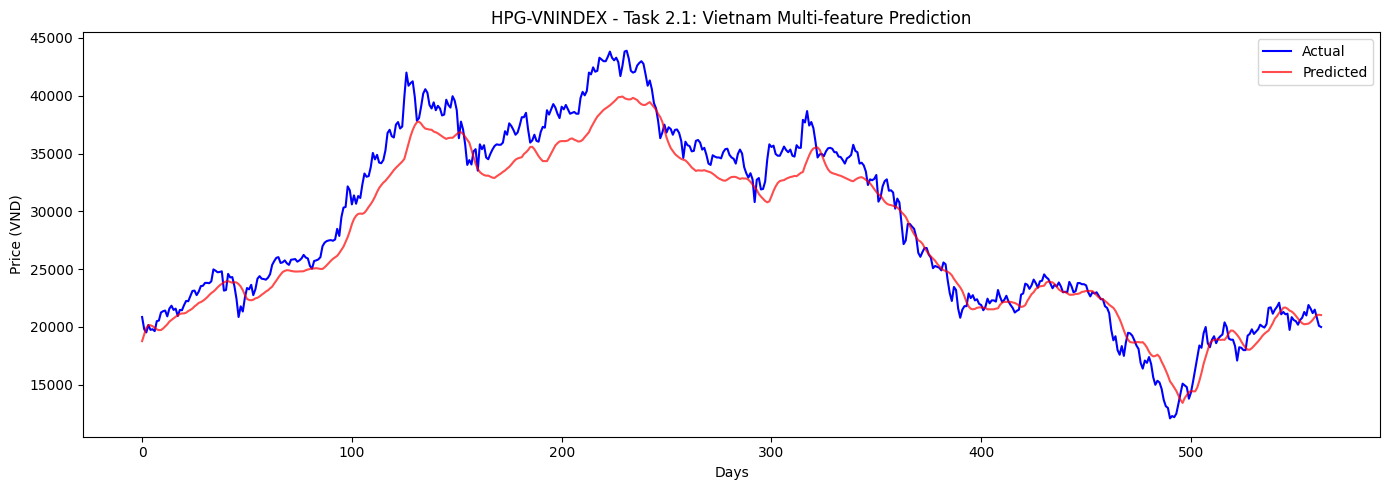

In [17]:
#Task 2.1
# Pick a well-known stock - HPG (Hoa Phat Group)
# Find HPG in our data
hpg_key = [k for k in vn_all_data.keys() if 'HPG' in k]
print("HPG keys found:", hpg_key)

# Use first match or fallback to first company
sample_key = hpg_key[0] if hpg_key else list(vn_all_data.keys())[0]
df_vn_sample = vn_all_data[sample_key]
print(f"\nUsing: {sample_key}")
print(f"Data range: {df_vn_sample['Date'].min()} to {df_vn_sample['Date'].max()}")
print(f"Total rows: {len(df_vn_sample)}")

# Build dataset
X_tr, y_tr, X_v, y_v, X_te, y_te, scaler_vn = make_dataset(
    df_vn_sample, WINDOW_SIZE, VN_FEATURES, VN_TARGET
)
print(f"\nX_train: {X_tr.shape}, X_val: {X_v.shape}, X_test: {X_te.shape}")

# Train model
model_vn = build_lstm_model(WINDOW_SIZE, len(VN_FEATURES))
early_stop = EarlyStopping(monitor='val_loss', patience=5,
                            restore_best_weights=True)
history_vn = model_vn.fit(
    X_tr, y_tr,
    validation_data=(X_v, y_v),
    epochs=50, batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

# Evaluate
vn_target_idx = VN_FEATURES.index(VN_TARGET)
y_pred_vn = model_vn.predict(X_te)
y_te_real = inverse_scale(scaler_vn, y_te, vn_target_idx, len(VN_FEATURES))
y_pr_real = inverse_scale(scaler_vn, y_pred_vn, vn_target_idx, len(VN_FEATURES))

mae  = mean_absolute_error(y_te_real, y_pr_real)
rmse = np.sqrt(mean_squared_error(y_te_real, y_pr_real))
print(f"\nMAE: {mae:.4f} | RMSE: {rmse:.4f}")

# Plot
plt.figure(figsize=(14, 5))
plt.plot(y_te_real, label='Actual', color='blue')
plt.plot(y_pr_real, label='Predicted', color='red', alpha=0.7)
plt.title(f'{sample_key} - Task 2.1: Vietnam Multi-feature Prediction')
plt.xlabel('Days')
plt.ylabel('Price (VND)')
plt.legend()
plt.tight_layout()
plt.show()

Task 2.1 — Hyperparameter Tuning (Vietnam)
  units=32, lr=1e-03 ... 

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


val_loss=0.000118
  units=32, lr=5e-04 ... val_loss=0.000160
  units=64, lr=1e-03 ... val_loss=0.000072
  units=64, lr=5e-04 ... val_loss=0.000121
  units=128, lr=1e-03 ... val_loss=0.000072
  units=128, lr=5e-04 ... val_loss=0.000113

Kết quả hyperparameter search (Vietnam):
 units     lr  val_loss
   128 0.0010  0.000072
    64 0.0010  0.000072
   128 0.0005  0.000113
    32 0.0010  0.000118
    64 0.0005  0.000121
    32 0.0005  0.000160

Best: units=128, lr=1e-03


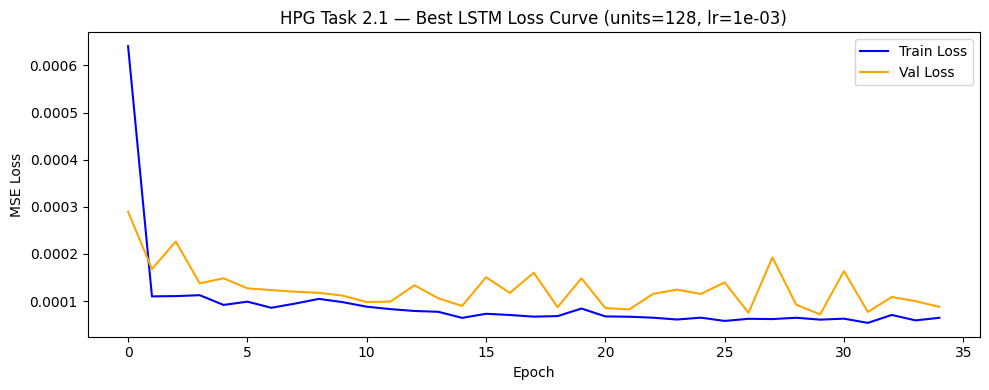

Best model — MAE: 1191.3426 | RMSE: 1503.5061

So sánh các mã VN tiêu biểu vs AAPL (Nasdaq)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  VNM: MAE=1504.0925, RMSE=1991.2030


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  FPT: MAE=2965.2548, RMSE=3585.0372


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  VIC: MAE=2350.3201, RMSE=3371.2932


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  HPG: MAE=991.8284, RMSE=1278.6869


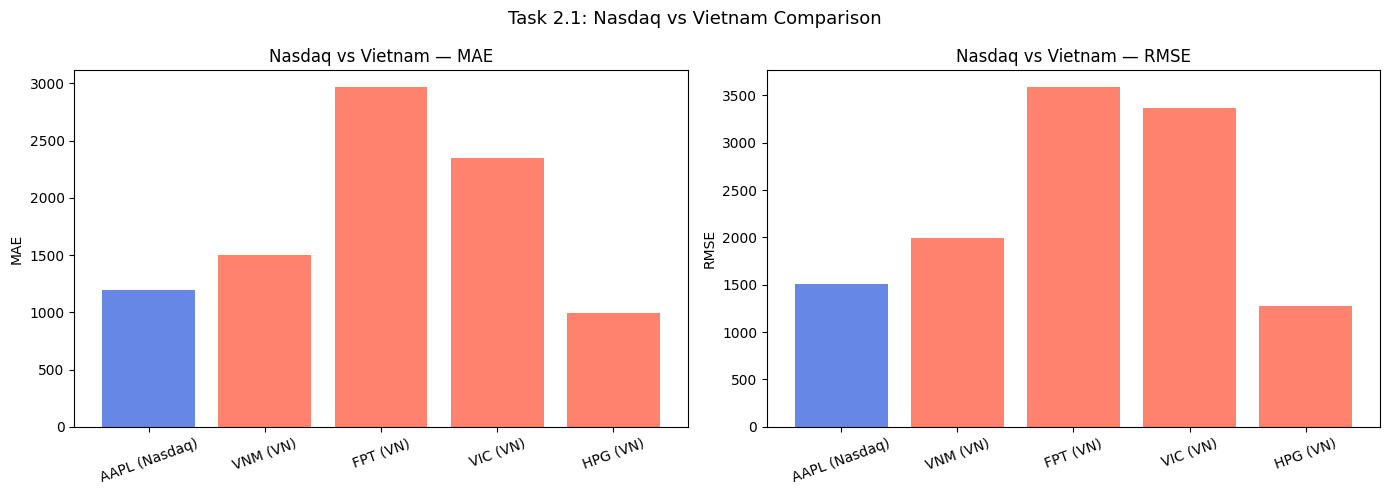

In [18]:
print("Task 2.1 — Hyperparameter Tuning (Vietnam)")
hp_results_2_1 = []
best_val_loss_vn, best_config_2_1 = np.inf, None

X_tr_vn, y_tr_vn, X_vl_vn, y_vl_vn, X_te_vn, y_te_vn, sc_vn = make_dataset(
    df_vn_sample, WINDOW_SIZE, VN_FEATURES, VN_TARGET
)

for units, lr in itertools.product([32, 64, 128], [1e-3, 5e-4]):
    print(f"  units={units}, lr={lr:.0e} ...", end=" ")
    m = build_lstm_tunable(WINDOW_SIZE, len(VN_FEATURES), units, lr)
    es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    hist = m.fit(X_tr_vn, y_tr_vn, validation_data=(X_vl_vn, y_vl_vn),
                 epochs=50, batch_size=32, callbacks=[es], verbose=0)
    vl = min(hist.history['val_loss'])
    print(f"val_loss={vl:.6f}")
    hp_results_2_1.append({'units': units, 'lr': lr, 'val_loss': vl})
    if vl < best_val_loss_vn:
        best_val_loss_vn = vl
        best_config_2_1 = {'units': units, 'lr': lr, 'model': m, 'history': hist}

df_hp_2_1 = pd.DataFrame(hp_results_2_1).sort_values('val_loss')
print("\nKết quả hyperparameter search (Vietnam):")
print(df_hp_2_1.round(6).to_string(index=False))
print(f"\nBest: units={best_config_2_1['units']}, lr={best_config_2_1['lr']:.0e}")

plot_loss_curve(best_config_2_1['history'],
                f"HPG Task 2.1 — Best LSTM Loss Curve "
                f"(units={best_config_2_1['units']}, lr={best_config_2_1['lr']:.0e})")

# Đánh giá best model
vn_target_idx = VN_FEATURES.index(VN_TARGET)
y_pred_best_2_1 = best_config_2_1['model'].predict(X_te_vn, verbose=0)
y_te_real_2_1 = inverse_scale(sc_vn, y_te_vn,          vn_target_idx, len(VN_FEATURES))
y_pr_real_2_1 = inverse_scale(sc_vn, y_pred_best_2_1,  vn_target_idx, len(VN_FEATURES))
print(f"Best model — MAE: {mean_absolute_error(y_te_real_2_1, y_pr_real_2_1):.4f} | "
      f"RMSE: {np.sqrt(mean_squared_error(y_te_real_2_1, y_pr_real_2_1)):.4f}")

# So sánh các mã VN tiêu biểu vs AAPL
print("\nSo sánh các mã VN tiêu biểu vs AAPL (Nasdaq)")
comparison = [{'ticker': 'AAPL (Nasdaq)',
               'MAE': mean_absolute_error(y_te_real_2_1, y_pr_real_2_1),
               'RMSE': np.sqrt(mean_squared_error(y_te_real_2_1, y_pr_real_2_1))}]

for ticker_name in ['VNM', 'FPT', 'VIC', 'HPG']:
    match = [k for k in vn_all_data.keys() if ticker_name in k.upper()]
    if not match:
        continue
    df_tk = vn_all_data[match[0]].dropna()  # dùng trực tiếp, bỏ add_technical_indicators
    if len(df_tk) < 200:
        continue
    # Chỉ lấy các cột có trong VN_FEATURES
    missing_cols = [c for c in VN_FEATURES if c not in df_tk.columns]
    if missing_cols:
        print(f"  {ticker_name}: thiếu cột {missing_cols}, bỏ qua")
        continue
    X_tr_t, y_tr_t, X_vl_t, y_vl_t, X_te_t, y_te_t, sc_t = make_dataset(
        df_tk, WINDOW_SIZE, VN_FEATURES, VN_TARGET
    )
    m_t = build_lstm_tunable(WINDOW_SIZE, len(VN_FEATURES),
                              best_config_2_1['units'], best_config_2_1['lr'])
    es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    m_t.fit(X_tr_t, y_tr_t, validation_data=(X_vl_t, y_vl_t),
            epochs=50, batch_size=32, callbacks=[es], verbose=0)
    y_pred_t = m_t.predict(X_te_t, verbose=0)
    y_te_tr  = inverse_scale(sc_t, y_te_t,   vn_target_idx, len(VN_FEATURES))
    y_pr_tr  = inverse_scale(sc_t, y_pred_t, vn_target_idx, len(VN_FEATURES))
    mae_t  = mean_absolute_error(y_te_tr, y_pr_tr)
    rmse_t = np.sqrt(mean_squared_error(y_te_tr, y_pr_tr))
    comparison.append({'ticker': f'{ticker_name} (VN)', 'MAE': mae_t, 'RMSE': rmse_t})
    print(f"  {ticker_name}: MAE={mae_t:.4f}, RMSE={rmse_t:.4f}")

df_cmp = pd.DataFrame(comparison)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['royalblue'] + ['tomato'] * (len(df_cmp) - 1)
for ax, metric in zip(axes, ['MAE', 'RMSE']):
    ax.bar(df_cmp['ticker'], df_cmp[metric], color=colors, alpha=0.8)
    ax.set_title(f'Nasdaq vs Vietnam — {metric}')
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=20)
plt.suptitle('Task 2.1: Nasdaq vs Vietnam Comparison', fontsize=13)
plt.tight_layout()
plt.show()

TASK 2.2 - Vietnam k-th Day Forecast


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
k=3 | MAE: 2587.18 | RMSE: 3257.93


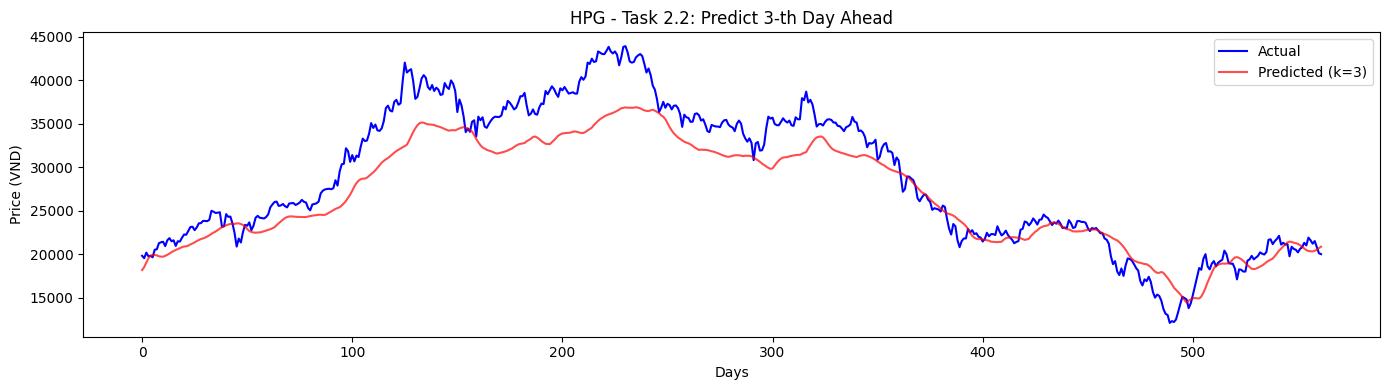

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
k=7 | MAE: 2222.64 | RMSE: 2805.50


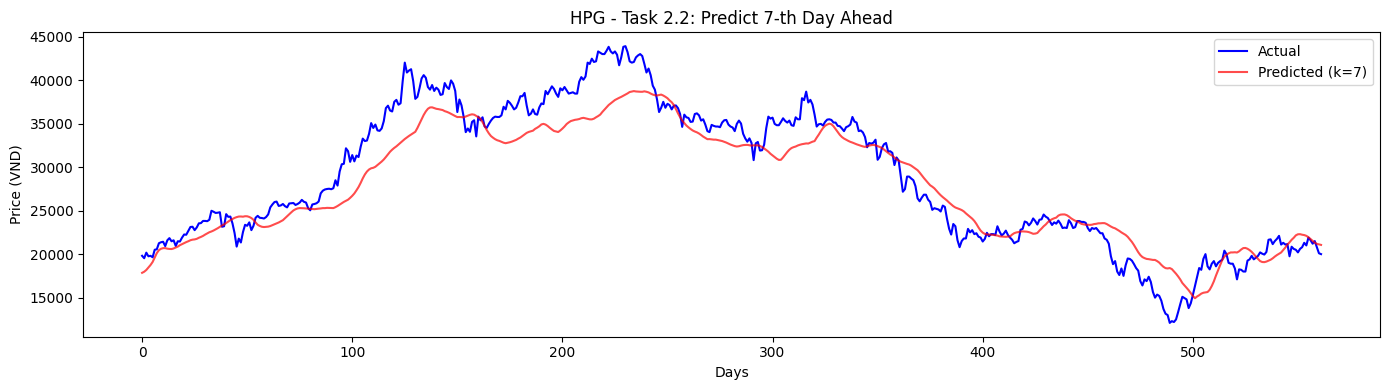

In [19]:
# Task 2.2 - k-th day forecast
print("=" * 50)
print("TASK 2.2 - Vietnam k-th Day Forecast")
print("=" * 50)

for k in [3, 7]:
    X_tr, y_tr, X_v, y_v, X_te, y_te, scaler_k = make_dataset_kth_day(
        df_vn_sample, WINDOW_SIZE, VN_FEATURES, VN_TARGET, k=k
    )

    model_k = build_lstm_model(WINDOW_SIZE, len(VN_FEATURES))
    early_stop = EarlyStopping(monitor='val_loss', patience=5,
                                restore_best_weights=True)
    model_k.fit(X_tr, y_tr, validation_data=(X_v, y_v),
                epochs=50, batch_size=32, callbacks=[early_stop], verbose=0)

    y_pred_k = model_k.predict(X_te)
    y_te_real = inverse_scale(scaler_k, y_te, vn_target_idx, len(VN_FEATURES))
    y_pr_real = inverse_scale(scaler_k, y_pred_k, vn_target_idx, len(VN_FEATURES))

    mae  = mean_absolute_error(y_te_real, y_pr_real)
    rmse = np.sqrt(mean_squared_error(y_te_real, y_pr_real))
    print(f"k={k} | MAE: {mae:.2f} | RMSE: {rmse:.2f}")

    plt.figure(figsize=(14, 4))
    plt.plot(y_te_real, label='Actual', color='blue')
    plt.plot(y_pr_real, label=f'Predicted (k={k})', color='red', alpha=0.7)
    plt.title(f'HPG - Task 2.2: Predict {k}-th Day Ahead')
    plt.xlabel('Days')
    plt.ylabel('Price (VND)')
    plt.legend()
    plt.tight_layout()
    plt.show()

Task 2.2 — Loss Curve N-th Day (Vietnam / HPG)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


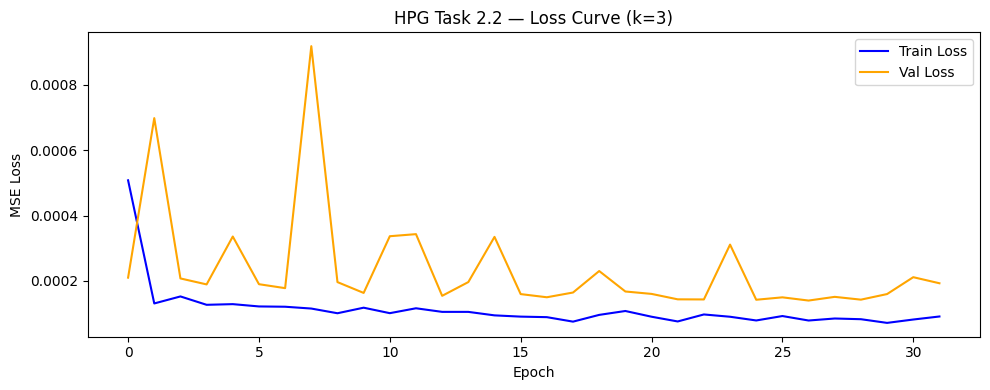

k=3 | MAE=1914.1549 | RMSE=2381.8989


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


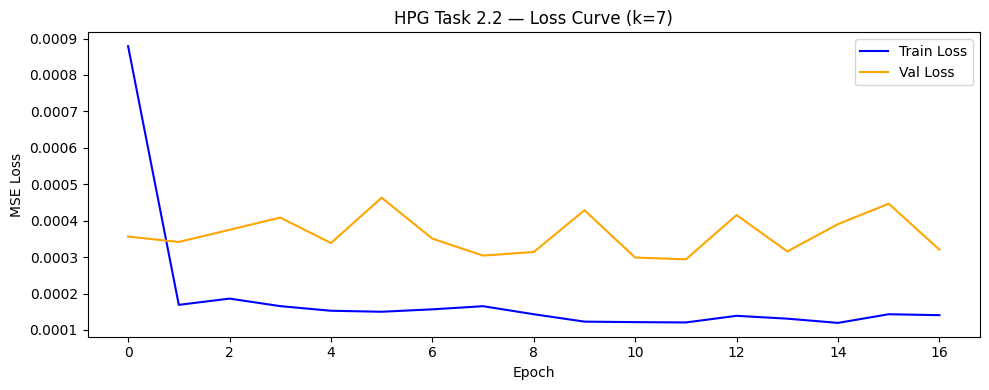

k=7 | MAE=2610.0668 | RMSE=3247.3408


In [20]:
print("Task 2.2 — Loss Curve N-th Day (Vietnam / HPG)")
for k in [3, 7]:
    X_tr22, y_tr22, X_v22, y_v22, X_te22, y_te22, sc22 = make_dataset_kth_day(
        df_vn_sample, WINDOW_SIZE, VN_FEATURES, VN_TARGET, k=k
    )
    m22 = build_lstm_tunable(WINDOW_SIZE, len(VN_FEATURES),
                              best_config_2_1['units'], best_config_2_1['lr'])
    es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    hist22 = m22.fit(X_tr22, y_tr22, validation_data=(X_v22, y_v22),
                     epochs=50, batch_size=32, callbacks=[es], verbose=0)
    plot_loss_curve(hist22, f"HPG Task 2.2 — Loss Curve (k={k})")
    y_pred22 = m22.predict(X_te22, verbose=0)
    y_te_r22 = inverse_scale(sc22, y_te22,   vn_target_idx, len(VN_FEATURES))
    y_pr_r22 = inverse_scale(sc22, y_pred22, vn_target_idx, len(VN_FEATURES))
    print(f"k={k} | MAE={mean_absolute_error(y_te_r22, y_pr_r22):.4f} | "
          f"RMSE={np.sqrt(mean_squared_error(y_te_r22, y_pr_r22)):.4f}")


TASK 2.3 - Vietnam k Consecutive Days Forecast


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
k=3 | Avg MAE: 3039.53 | Avg RMSE: 3818.28
  Day 1: MAE=3472.08, RMSE=4337.12
  Day 2: MAE=2844.80, RMSE=3599.43
  Day 3: MAE=2801.73, RMSE=3518.29


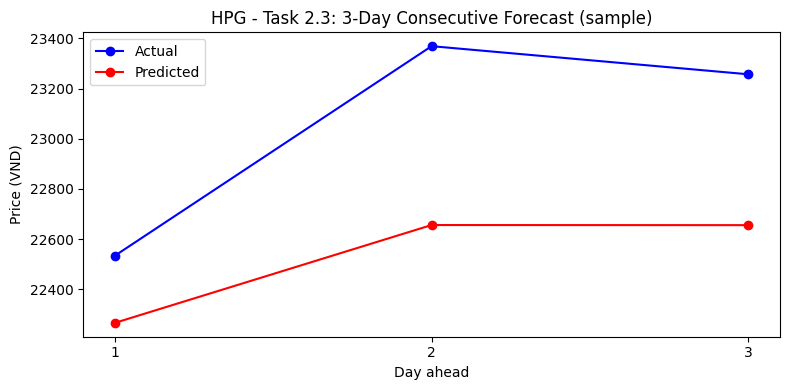

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
k=7 | Avg MAE: 3240.46 | Avg RMSE: 4031.15
  Day 1: MAE=2670.71, RMSE=3378.85
  Day 2: MAE=2748.15, RMSE=3474.95
  Day 3: MAE=3208.83, RMSE=3996.34
  Day 4: MAE=3704.26, RMSE=4501.63
  Day 5: MAE=3143.23, RMSE=3933.11
  Day 6: MAE=3493.10, RMSE=4344.59
  Day 7: MAE=3714.92, RMSE=4588.60


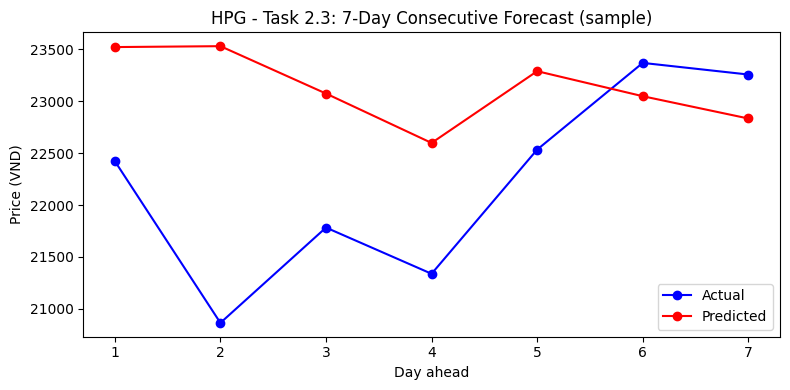

In [21]:
# Task 2.3 - k consecutive days forecast
print("\n" + "=" * 50)
print("TASK 2.3 - Vietnam k Consecutive Days Forecast")
print("=" * 50)

for k in [3, 7]:
    X_tr, y_tr, X_v, y_v, X_te, y_te, scaler_k = make_dataset_k_days(
        df_vn_sample, WINDOW_SIZE, VN_FEATURES, VN_TARGET, k=k
    )

    model_k = build_lstm_multi_output(WINDOW_SIZE, len(VN_FEATURES), k)
    early_stop = EarlyStopping(monitor='val_loss', patience=5,
                                restore_best_weights=True)
    model_k.fit(X_tr, y_tr, validation_data=(X_v, y_v),
                epochs=50, batch_size=32, callbacks=[early_stop], verbose=0)

    y_pred_k = model_k.predict(X_te)

    maes, rmses = [], []
    for day in range(k):
        y_te_real = inverse_scale(scaler_k, y_te[:, day],
                                   vn_target_idx, len(VN_FEATURES))
        y_pr_real = inverse_scale(scaler_k, y_pred_k[:, day],
                                   vn_target_idx, len(VN_FEATURES))
        maes.append(mean_absolute_error(y_te_real, y_pr_real))
        rmses.append(np.sqrt(mean_squared_error(y_te_real, y_pr_real)))

    print(f"k={k} | Avg MAE: {np.mean(maes):.2f} | Avg RMSE: {np.mean(rmses):.2f}")
    for day in range(k):
        print(f"  Day {day+1}: MAE={maes[day]:.2f}, RMSE={rmses[day]:.2f}")

    # Plot sample prediction
    sample_idx = 50
    y_te_sample = [inverse_scale(scaler_k, y_te[sample_idx:sample_idx+1, d],
                                  vn_target_idx, len(VN_FEATURES))[0] for d in range(k)]
    y_pr_sample = [inverse_scale(scaler_k, y_pred_k[sample_idx:sample_idx+1, d],
                                  vn_target_idx, len(VN_FEATURES))[0] for d in range(k)]

    plt.figure(figsize=(8, 4))
    plt.plot(range(1, k+1), y_te_sample, marker='o', label='Actual', color='blue')
    plt.plot(range(1, k+1), y_pr_sample, marker='o', label='Predicted', color='red')
    plt.title(f'HPG - Task 2.3: {k}-Day Consecutive Forecast (sample)')
    plt.xlabel('Day ahead')
    plt.ylabel('Price (VND)')
    plt.xticks(range(1, k+1))
    plt.legend()
    plt.tight_layout()
    plt.show()

Task 2.3 — Loss Curve K Consecutive Days (Vietnam / HPG)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


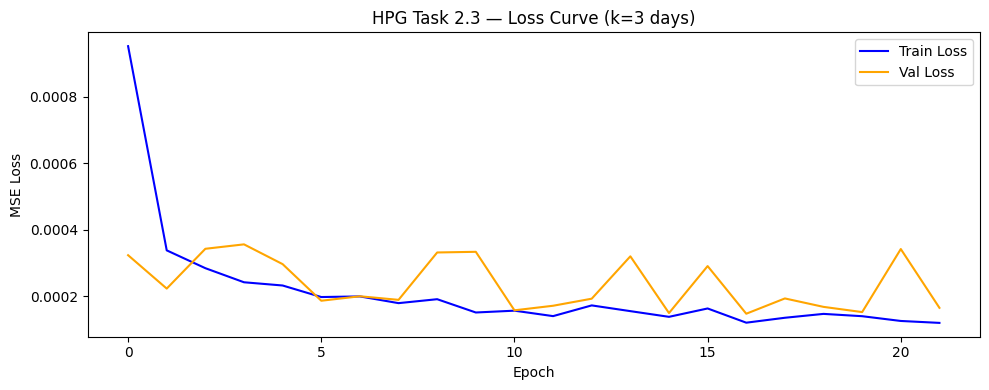

k=3 | Avg MAE=2235.6286 | Avg RMSE=2756.5346


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


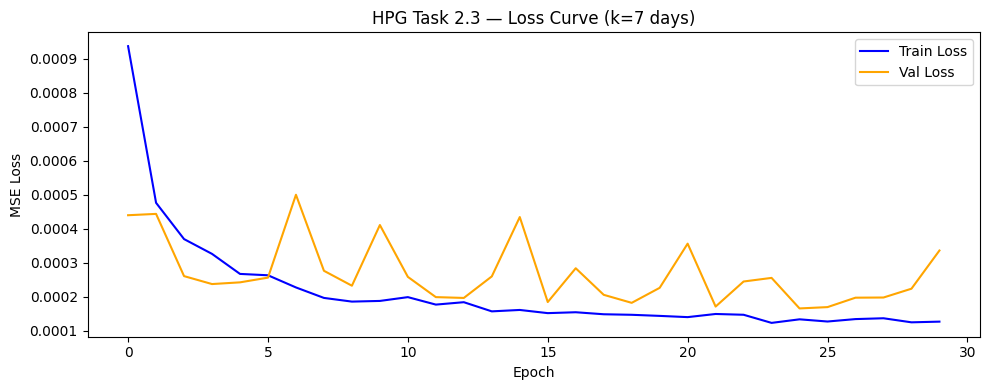

k=7 | Avg MAE=2186.9003 | Avg RMSE=2721.3045


In [22]:
print("Task 2.3 — Loss Curve K Consecutive Days (Vietnam / HPG)")
for k in [3, 7]:
    X_tr23, y_tr23, X_v23, y_v23, X_te23, y_te23, sc23 = make_dataset_k_days(
        df_vn_sample, WINDOW_SIZE, VN_FEATURES, VN_TARGET, k=k
    )
    m23 = build_lstm_multi_output(WINDOW_SIZE, len(VN_FEATURES), k)
    es  = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    hist23 = m23.fit(X_tr23, y_tr23, validation_data=(X_v23, y_v23),
                     epochs=50, batch_size=32, callbacks=[es], verbose=0)
    plot_loss_curve(hist23, f"HPG Task 2.3 — Loss Curve (k={k} days)")
    y_pred23 = m23.predict(X_te23, verbose=0)
    maes23, rmses23 = [], []
    for day in range(k):
        y_te_r23 = inverse_scale(sc23, y_te23[:, day], vn_target_idx, len(VN_FEATURES))
        y_pr_r23 = inverse_scale(sc23, y_pred23[:, day], vn_target_idx, len(VN_FEATURES))
        maes23.append(mean_absolute_error(y_te_r23, y_pr_r23))
        rmses23.append(np.sqrt(mean_squared_error(y_te_r23, y_pr_r23)))
    print(f"k={k} | Avg MAE={np.mean(maes23):.4f} | Avg RMSE={np.mean(rmses23):.4f}")

Task 2 — Architecture Comparison: LSTM vs GRU vs CNN (HPG)

Training LSTM...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


  MAE=1394.0834 | RMSE=1750.7365 | Time=16.2s | Params=118,081

Training GRU...
  MAE=809.9825 | RMSE=1040.4547 | Time=20.1s | Params=89,153

Training CNN...
  MAE=1489.5385 | RMSE=1907.1021 | Time=20.8s | Params=20,577

--- Task 2: Architecture Comparison Table (HPG) ---
            MAE       RMSE  Train Time (s)    Params  Epochs
LSTM  1394.0834  1750.7365            16.2  118081.0    15.0
GRU    809.9825  1040.4547            20.1   89153.0    20.0
CNN   1489.5385  1907.1021            20.8   20577.0    40.0

Best architecture by MAE: GRU


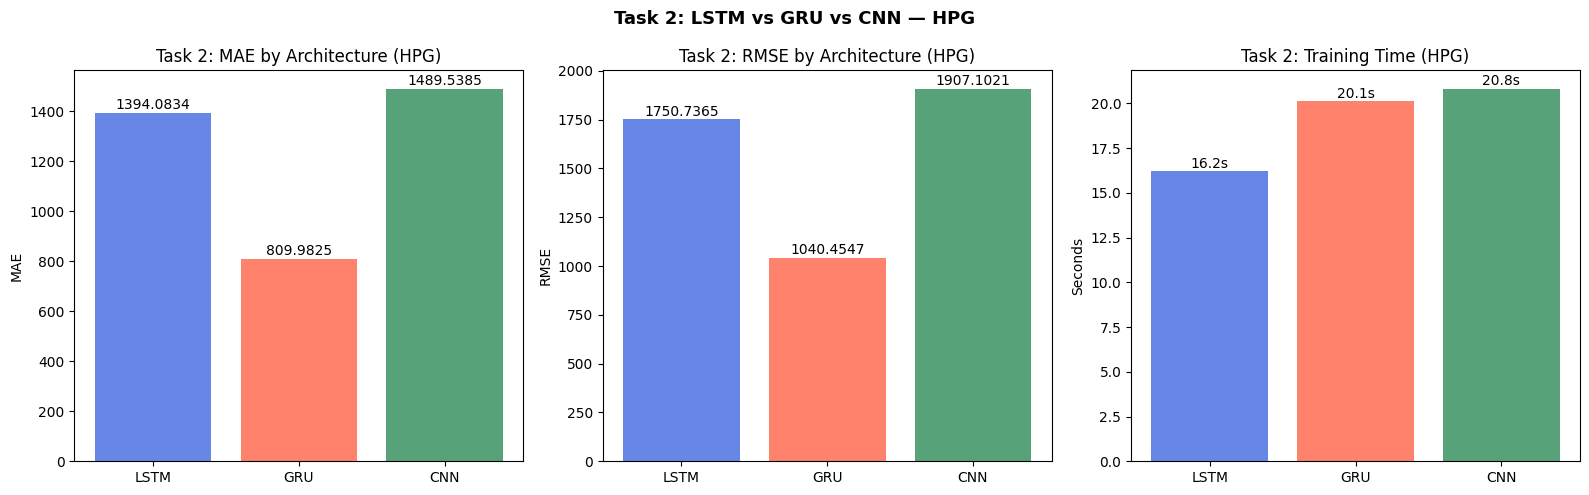

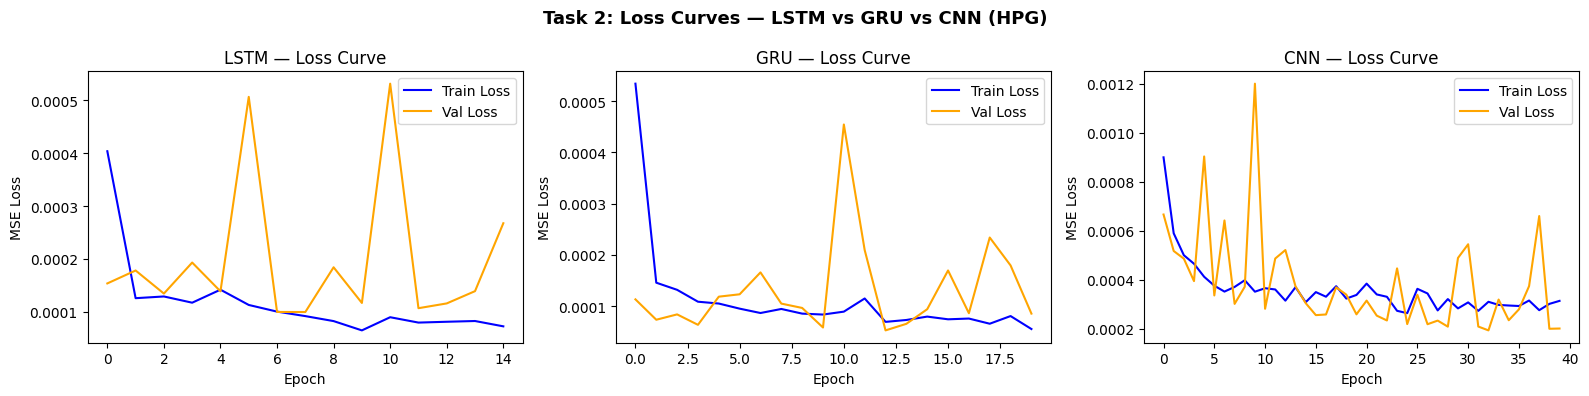

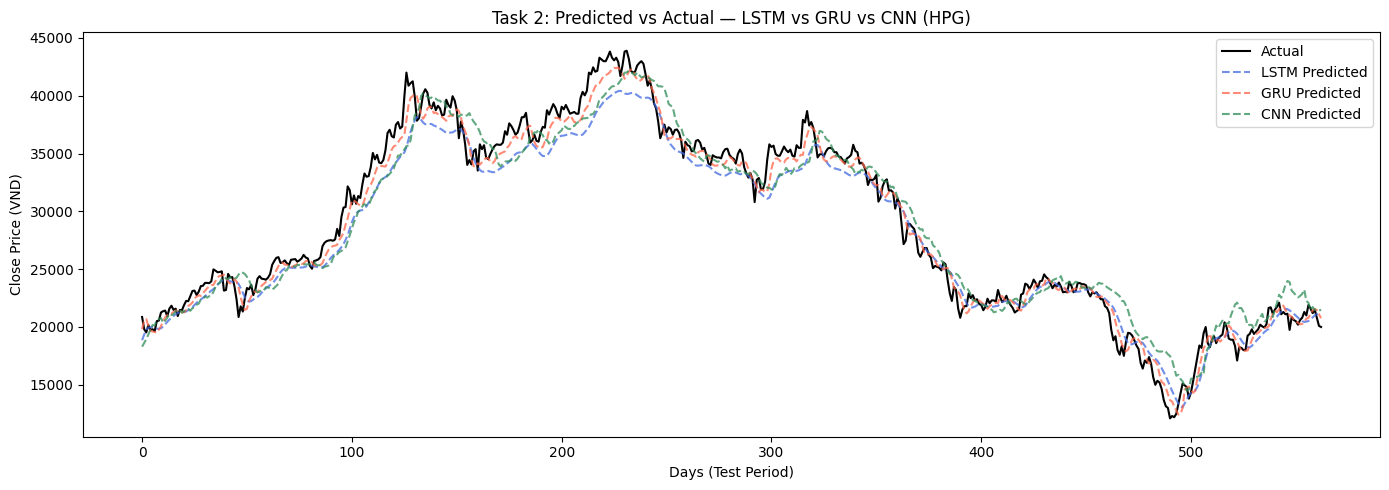


--- Task 2: LSTM vs GRU vs CNN across representative companies ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


  HPG (Steel/Materials): LSTM_MAE=1787.3538 | GRU_MAE=800.5883 | CNN_MAE=1958.4507


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


  FPT (Tech/Telecom): LSTM_MAE=3868.3726 | GRU_MAE=1189.2296 | CNN_MAE=5997.7607


...

  VNM (Consumer/FMCG): LSTM_MAE=1651.5539 | GRU_MAE=1352.3505 | CNN_MAE=2841.2535


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


  VIC (Real Estate): LSTM_MAE=2422.0890 | GRU_MAE=2581.9699 | CNN_MAE=6315.1067


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


  VCB (Banking): LSTM_MAE=2475.8777 | GRU_MAE=1437.4048 | CNN_MAE=5083.9515

--- MAE Comparison across companies ---
               industry   LSTM_MAE    GRU_MAE    CNN_MAE
ticker                                                  
HPG     Steel/Materials  1787.3538   800.5883  1958.4507
FPT        Tech/Telecom  3868.3726  1189.2296  5997.7607
VNM       Consumer/FMCG  1651.5539  1352.3505  2841.2535
VIC         Real Estate  2422.0890  2581.9699  6315.1067
VCB             Banking  2475.8777  1437.4048  5083.9515


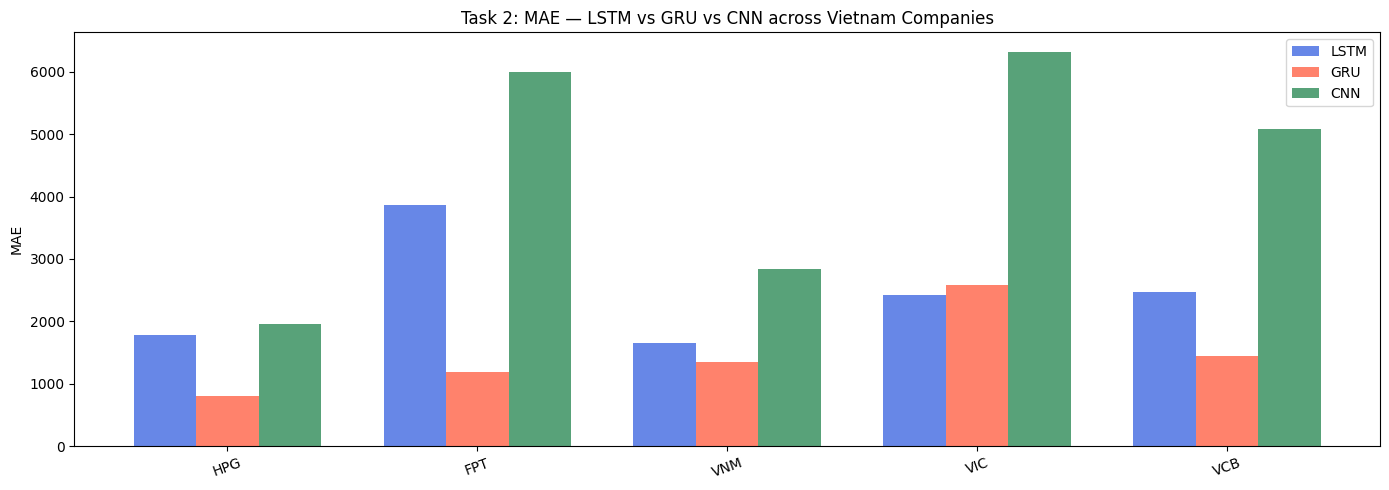

In [23]:
# ============================================================
# TASK 2 — CNN & GRU FOR VIETNAM STOCK PRICE PREDICTION
# Place AFTER Task 2.3 cells
# Adds GRU and CNN models to compare with existing LSTM
# ============================================================

import time
from tensorflow.keras.layers import GRU, Conv1D, MaxPooling1D, Flatten
from tensorflow.keras.optimizers import Adam

# ── Model builders (regression) ──────────────────────────────

def build_gru_regressor(window_size, n_features, units=64, lr=1e-3):
    """
    GRU model — lighter than LSTM, fewer parameters.
    Good baseline to compare training speed vs accuracy.
    """
    model = Sequential([
        GRU(units, return_sequences=True,
            input_shape=(window_size, n_features)),
        Dropout(0.2),
        GRU(units // 2, return_sequences=False),
        Dropout(0.2),
        Dense(1)
    ])
    model.compile(optimizer=Adam(lr), loss='mse', metrics=['mae'])
    return model


def build_cnn_regressor(window_size, n_features, filters=64, lr=1e-3):
    """
    CNN (Conv1D) model — strong at extracting short-term local patterns.
    Two Conv1D layers followed by Dense head.
    """
    model = Sequential([
        Conv1D(filters=filters, kernel_size=3, activation='relu',
               input_shape=(window_size, n_features)),
        MaxPooling1D(pool_size=2),
        Conv1D(filters=filters // 2, kernel_size=3, activation='relu'),
        MaxPooling1D(pool_size=2),
        Flatten(),
        Dense(32, activation='relu'),
        Dropout(0.2),
        Dense(1)
    ])
    model.compile(optimizer=Adam(lr), loss='mse', metrics=['mae'])
    return model


# ── Use best hyperparams from Task 2.1 tuning ────────────────
BEST_UNITS = best_config_2_1['units']
BEST_LR    = best_config_2_1['lr']

# ── Dataset (same as Task 2.1) ────────────────────────────────
X_tr_cmp, y_tr_cmp, X_vl_cmp, y_vl_cmp, X_te_cmp, y_te_cmp, sc_cmp = make_dataset(
    df_vn_sample, WINDOW_SIZE, VN_FEATURES, VN_TARGET
)
vn_target_idx = VN_FEATURES.index(VN_TARGET)

# ── Train all 3 architectures on HPG ─────────────────────────
print("Task 2 — Architecture Comparison: LSTM vs GRU vs CNN (HPG)")
print("=" * 55)

architectures = {
    'LSTM': build_lstm_tunable(WINDOW_SIZE, len(VN_FEATURES), BEST_UNITS, BEST_LR),
    'GRU':  build_gru_regressor(WINDOW_SIZE, len(VN_FEATURES), BEST_UNITS, BEST_LR),
    'CNN':  build_cnn_regressor(WINDOW_SIZE, len(VN_FEATURES), lr=BEST_LR),
}

arch_results   = {}
arch_histories = {}

for name, model in architectures.items():
    print(f"\nTraining {name}...")
    es = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)
    t0   = time.time()
    hist = model.fit(X_tr_cmp, y_tr_cmp,
                     validation_data=(X_vl_cmp, y_vl_cmp),
                     epochs=50, batch_size=32,
                     callbacks=[es], verbose=0)
    train_time = time.time() - t0

    y_pred = model.predict(X_te_cmp, verbose=0)
    y_te_r = inverse_scale(sc_cmp, y_te_cmp, vn_target_idx, len(VN_FEATURES))
    y_pr_r = inverse_scale(sc_cmp, y_pred,   vn_target_idx, len(VN_FEATURES))

    mae  = mean_absolute_error(y_te_r, y_pr_r)
    rmse = np.sqrt(mean_squared_error(y_te_r, y_pr_r))

    arch_results[name] = {
        'MAE':            mae,
        'RMSE':           rmse,
        'Train Time (s)': round(train_time, 1),
        'Params':         model.count_params(),
        'Epochs':         len(hist.history['loss']),
        'y_true':         y_te_r,
        'y_pred':         y_pr_r,
    }
    arch_histories[name] = hist
    print(f"  MAE={mae:.4f} | RMSE={rmse:.4f} | "
          f"Time={train_time:.1f}s | Params={model.count_params():,}")


# ── Summary table ─────────────────────────────────────────────
df_arch = pd.DataFrame({
    k: {m: v for m, v in d.items() if m not in ('y_true', 'y_pred')}
    for k, d in arch_results.items()
}).T

print("\n--- Task 2: Architecture Comparison Table (HPG) ---")
print(df_arch[['MAE', 'RMSE', 'Train Time (s)', 'Params', 'Epochs']].round(4).to_string())

best_arch = df_arch['MAE'].idxmin()
print(f"\nBest architecture by MAE: {best_arch}")


# ── Plot 1: Bar chart MAE / RMSE / Training Time ─────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
names  = list(arch_results.keys())
colors = ['royalblue', 'tomato', 'seagreen']

for ax, metric in zip(axes[:2], ['MAE', 'RMSE']):
    vals = [arch_results[n][metric] for n in names]
    bars = ax.bar(names, vals, color=colors, alpha=0.8)
    ax.set_title(f'Task 2: {metric} by Architecture (HPG)')
    ax.set_ylabel(metric)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + max(vals) * 0.01,
                f'{v:.4f}', ha='center', fontsize=10)

times = [arch_results[n]['Train Time (s)'] for n in names]
bars  = axes[2].bar(names, times, color=colors, alpha=0.8)
axes[2].set_title('Task 2: Training Time (HPG)')
axes[2].set_ylabel('Seconds')
for bar, v in zip(bars, times):
    axes[2].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + max(times) * 0.01,
                 f'{v:.1f}s', ha='center', fontsize=10)

plt.suptitle('Task 2: LSTM vs GRU vs CNN — HPG', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


# ── Plot 2: Loss curves ───────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, name, color in zip(axes, names, colors):
    h = arch_histories[name]
    ax.plot(h.history['loss'],     label='Train Loss', color='blue')
    ax.plot(h.history['val_loss'], label='Val Loss',   color='orange')
    ax.set_title(f'{name} — Loss Curve')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE Loss')
    ax.legend()

plt.suptitle('Task 2: Loss Curves — LSTM vs GRU vs CNN (HPG)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


# ── Plot 3: Prediction overlay ────────────────────────────────
plt.figure(figsize=(14, 5))
plt.plot(arch_results['LSTM']['y_true'],
         label='Actual', color='black', linewidth=1.5)
for name, color in zip(names, colors):
    plt.plot(arch_results[name]['y_pred'],
             label=f'{name} Predicted',
             color=color, alpha=0.75, linestyle='--')
plt.title('Task 2: Predicted vs Actual — LSTM vs GRU vs CNN (HPG)')
plt.xlabel('Days (Test Period)')
plt.ylabel('Close Price (VND)')
plt.legend()
plt.tight_layout()
plt.show()


# ── Run comparison on other VN representative companies ───────
print("\n--- Task 2: LSTM vs GRU vs CNN across representative companies ---")

multi_results = []
for industry, ticker, key in selected_tickers:
    df_co = vn_all_data[key].copy()
    if len(df_co) < 200:
        continue
    try:
        X_tr_m, y_tr_m, X_vl_m, y_vl_m, X_te_m, y_te_m, sc_m = make_dataset(
            df_co, WINDOW_SIZE, VN_FEATURES, VN_TARGET
        )
        row = {'ticker': ticker, 'industry': industry}
        for name, builder in [
            ('LSTM', lambda: build_lstm_tunable(WINDOW_SIZE, len(VN_FEATURES),
                                                BEST_UNITS, BEST_LR)),
            ('GRU',  lambda: build_gru_regressor(WINDOW_SIZE, len(VN_FEATURES),
                                                  BEST_UNITS, BEST_LR)),
            ('CNN',  lambda: build_cnn_regressor(WINDOW_SIZE, len(VN_FEATURES),
                                                  lr=BEST_LR)),
        ]:
            m = builder()
            es = EarlyStopping(monitor='val_loss', patience=5,
                               restore_best_weights=True)
            m.fit(X_tr_m, y_tr_m,
                  validation_data=(X_vl_m, y_vl_m),
                  epochs=30, batch_size=32,
                  callbacks=[es], verbose=0)
            y_pred_m = m.predict(X_te_m, verbose=0)
            y_te_rm  = inverse_scale(sc_m, y_te_m,   vn_target_idx, len(VN_FEATURES))
            y_pr_rm  = inverse_scale(sc_m, y_pred_m, vn_target_idx, len(VN_FEATURES))
            row[f'{name}_MAE']  = mean_absolute_error(y_te_rm, y_pr_rm)
            row[f'{name}_RMSE'] = np.sqrt(mean_squared_error(y_te_rm, y_pr_rm))

        multi_results.append(row)
        print(f"  {ticker} ({industry}): "
              f"LSTM_MAE={row['LSTM_MAE']:.4f} | "
              f"GRU_MAE={row['GRU_MAE']:.4f} | "
              f"CNN_MAE={row['CNN_MAE']:.4f}")
    except Exception as e:
        print(f"  {ticker}: error — {e}")

df_multi = pd.DataFrame(multi_results).set_index('ticker')

print("\n--- MAE Comparison across companies ---")
mae_cols = ['LSTM_MAE', 'GRU_MAE', 'CNN_MAE']
print(df_multi[['industry'] + mae_cols].round(4).to_string())

# Plot grouped bar chart
fig, ax = plt.subplots(figsize=(14, 5))
x = np.arange(len(df_multi))
w = 0.25
for i, (col, color) in enumerate(zip(mae_cols, colors)):
    ax.bar(x + i * w, df_multi[col], w,
           label=col.replace('_MAE', ''), color=color, alpha=0.8)
ax.set_xticks(x + w)
ax.set_xticklabels(df_multi.index, rotation=20)
ax.set_title('Task 2: MAE — LSTM vs GRU vs CNN across Vietnam Companies')
ax.set_ylabel('MAE')
ax.legend()
plt.tight_layout()
plt.show()

Buy signals: 274
Sell signals: 272
Total rows: 3807


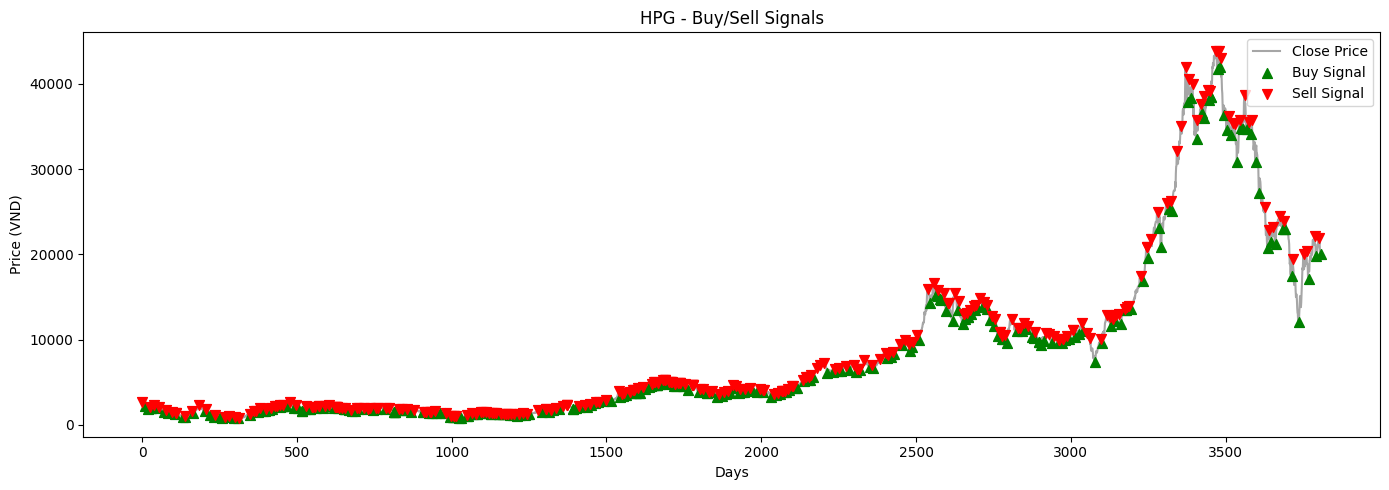

In [24]:
#Task 3
def add_trading_signals(df, window_size=10):
    """
    Buy signal:  current Close is the lowest in the time window
    Sell signal: current Close is the highest in the time window
    """
    df = df.copy()

    buy_signals  = []
    sell_signals = []

    for i in range(len(df)):
        # Get window: past + future around current point
        start = max(0, i - window_size // 2)
        end   = min(len(df), i + window_size // 2 + 1)
        window_prices = df['Close'].iloc[start:end]

        current_price = df['Close'].iloc[i]

        buy_signals.append(1 if current_price == window_prices.min() else 0)
        sell_signals.append(1 if current_price == window_prices.max() else 0)

    df['Buy']  = buy_signals
    df['Sell'] = sell_signals
    return df

# Apply to HPG
df_hpg_signals = add_trading_signals(df_vn_sample, window_size=10)

print("Buy signals:", df_hpg_signals['Buy'].sum())
print("Sell signals:", df_hpg_signals['Sell'].sum())
print("Total rows:", len(df_hpg_signals))

# Visualize signals on price chart
plt.figure(figsize=(14, 5))
plt.plot(df_hpg_signals['Close'].values, label='Close Price', color='gray', alpha=0.7)

buy_signal_rows = df_hpg_signals[df_hpg_signals['Buy'] == 1]
sell_signal_rows = df_hpg_signals[df_hpg_signals['Sell'] == 1]

plt.scatter(buy_signal_rows.index, buy_signal_rows['Close'],
            color='green', marker='^', s=50, label='Buy Signal', zorder=5)
plt.scatter(sell_signal_rows.index, sell_signal_rows['Close'],
            color='red', marker='v', s=50, label='Sell Signal', zorder=5)
plt.title('HPG - Buy/Sell Signals')
plt.xlabel('Days')
plt.ylabel('Price (VND)')
plt.legend()
plt.tight_layout()
plt.show()


=== NOTE VỀ SIGNAL LABELING (TASK 3) ===

Cách label cũ "buy = local min trong window [-5, +5]" là LOOKFORWARD BIAS:
  - Tại ngày t, ta dùng giá t+1 ... t+5 để xác định label
  - Trong thực tế tại t ta KHÔNG biết giá tương lai

Tuy nhiên đây là bài toán SUPERVISED LEARNING OFFLINE:
  - Ta label toàn bộ dữ liệu lịch sử (đã biết kết quả)
  - Model học pattern từ quá khứ để dự đoán tương lai
  - Đây là cách phổ biến trong finance ML research
    (ref: Advances in Financial Machine Learning - López de Prado)

Bên dưới mình bổ sung thêm label KHÔNG dùng thông tin tương lai
để so sánh với cách cũ.

No-lookahead — BUY: 12, SELL: 7, Total: 3788


/tmp/ipykernel_3652/1656811983.py:71: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  golden_cross = sma5_above & (~sma5_above.shift(1).fillna(False))
/tmp/ipykernel_3652/1656811983.py:72: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  death_cross  = (~sma5_above) & (sma5_above.shift(1).fillna(False))


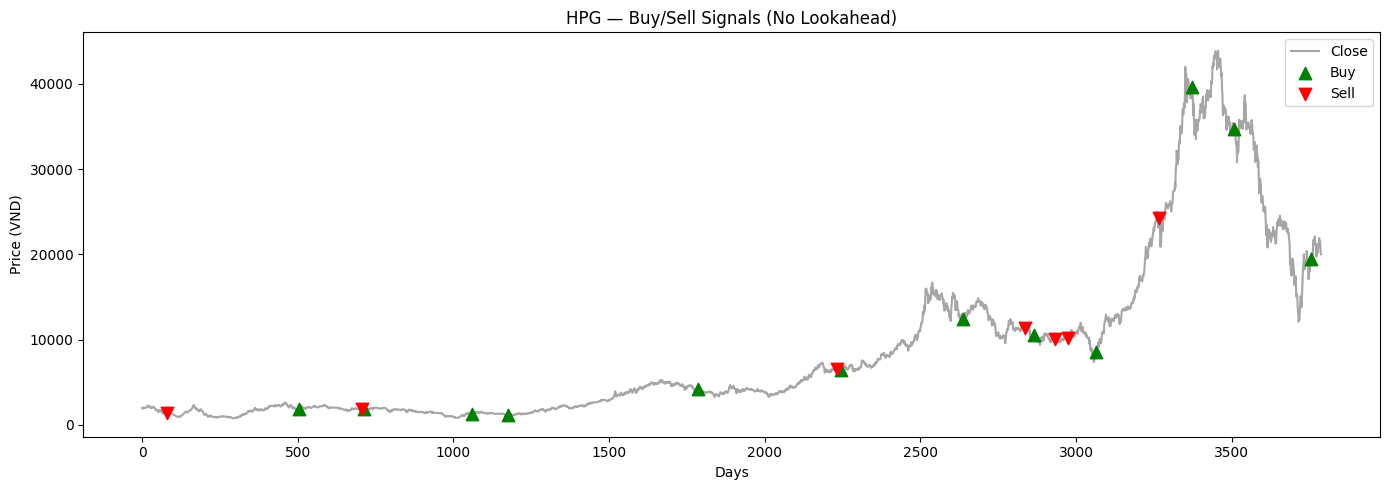


--- Task 3: Train với No-Lookahead Labels (HPG) ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



Buy Signal (No-Lookahead) — HPG:
              precision    recall  f1-score   support

   No Signal       0.00      0.00      0.00       557
         Buy       0.01      1.00      0.01         3

    accuracy                           0.01       560
   macro avg       0.00      0.50      0.01       560
weighted avg       0.00      0.01      0.00       560


Sell Signal: không đủ tín hiệu để train, bỏ qua

--- Task 3: Buy Signal — Các công ty đại diện ---


/tmp/ipykernel_3652/1656811983.py:71: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  golden_cross = sma5_above & (~sma5_above.shift(1).fillna(False))
/tmp/ipykernel_3652/1656811983.py:72: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  death_cross  = (~sma5_above) & (sma5_above.shift(1).fillna(False))
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  s

  HPG (Steel/Materials): F1=0.0107


...

  FPT (Tech/Telecom): F1=0.0000


/tmp/ipykernel_3652/1656811983.py:71: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  golden_cross = sma5_above & (~sma5_above.shift(1).fillna(False))
/tmp/ipykernel_3652/1656811983.py:72: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  death_cross  = (~sma5_above) & (sma5_above.shift(1).fillna(False))
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  s

  VNM (Consumer/FMCG): F1=0.0000
  VIC: không đủ tín hiệu train, bỏ qua


/tmp/ipykernel_3652/1656811983.py:71: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  golden_cross = sma5_above & (~sma5_above.shift(1).fillna(False))
/tmp/ipykernel_3652/1656811983.py:72: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  death_cross  = (~sma5_above) & (sma5_above.shift(1).fillna(False))
/tmp/ipykernel_3652/1656811983.py:71: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_opti

  VCB (Banking): F1=0.0000


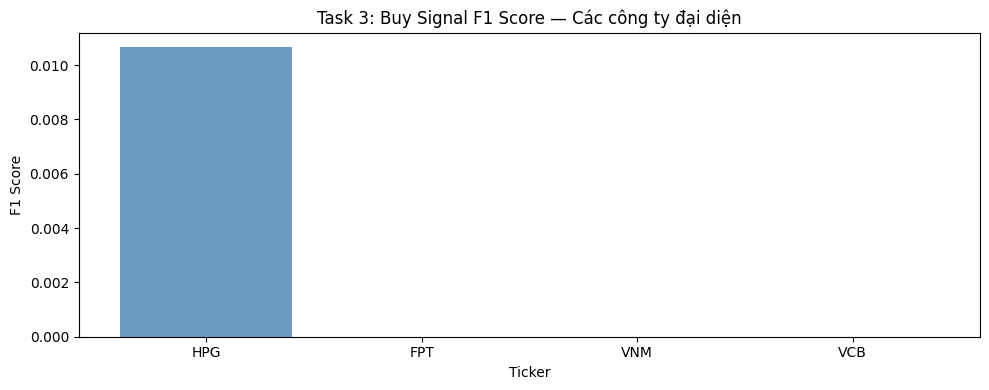

In [25]:
from sklearn.metrics import classification_report, f1_score

print("""
=== NOTE VỀ SIGNAL LABELING (TASK 3) ===

Cách label cũ "buy = local min trong window [-5, +5]" là LOOKFORWARD BIAS:
  - Tại ngày t, ta dùng giá t+1 ... t+5 để xác định label
  - Trong thực tế tại t ta KHÔNG biết giá tương lai

Tuy nhiên đây là bài toán SUPERVISED LEARNING OFFLINE:
  - Ta label toàn bộ dữ liệu lịch sử (đã biết kết quả)
  - Model học pattern từ quá khứ để dự đoán tương lai
  - Đây là cách phổ biến trong finance ML research
    (ref: Advances in Financial Machine Learning - López de Prado)

Bên dưới mình bổ sung thêm label KHÔNG dùng thông tin tương lai
để so sánh với cách cũ.
""")


def make_classification_dataset(df, window_size, features, target_col,
                                  train_ratio=0.7, val_ratio=0.15):
    df = df.copy().dropna(subset=features + [target_col]).reset_index(drop=True)
    data   = df[features].values
    labels = df[target_col].values
    X, y = [], []
    for i in range(window_size, len(data)):
        X.append(data[i - window_size:i])
        y.append(labels[i])
    X, y    = np.array(X), np.array(y)
    n       = len(X)
    n_train = int(n * train_ratio)
    n_val   = int(n * val_ratio)
    return (X[:n_train], y[:n_train],
            X[n_train:n_train + n_val], y[n_train:n_train + n_val],
            X[n_train + n_val:], y[n_train + n_val:])


def build_lstm_classifier(window_size, n_features, units=64):
    model = Sequential([
        LSTM(units, return_sequences=True,
             input_shape=(window_size, n_features)),
        Dropout(0.2),
        LSTM(units // 2, return_sequences=False),
        Dropout(0.2),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=Adam(learning_rate=1e-3),
                  loss='binary_crossentropy', metrics=['accuracy'])
    return model


def add_signals_no_lookahead(df, short_window=5, long_window=20,
                              rsi_buy=45, rsi_sell=55):
    df = df.copy()
    if 'RSI' not in df.columns:
        delta = df['Close'].diff()
        gain  = delta.clip(lower=0).rolling(14).mean()
        loss  = (-delta.clip(upper=0)).rolling(14).mean()
        df['RSI'] = 100 - (100 / (1 + gain / (loss + 1e-9)))
    if 'SMA_5' not in df.columns:
        df['SMA_5']  = df['Close'].rolling(short_window).mean()
    if 'SMA_20' not in df.columns:
        df['SMA_20'] = df['Close'].rolling(long_window).mean()
    if 'MACD' not in df.columns:
        ema12 = df['Close'].ewm(span=12, adjust=False).mean()
        ema26 = df['Close'].ewm(span=26, adjust=False).mean()
        df['MACD'] = ema12 - ema26
    df = df.dropna().reset_index(drop=True)
    sma5_above   = df['SMA_5'] > df['SMA_20']
    golden_cross = sma5_above & (~sma5_above.shift(1).fillna(False))
    death_cross  = (~sma5_above) & (sma5_above.shift(1).fillna(False))
    df['Buy']  = ((df['RSI'] < rsi_buy)  & golden_cross).astype(int)
    df['Sell'] = ((df['RSI'] > rsi_sell) & death_cross).astype(int)
    return df


# Áp dụng trên HPG
df_hpg_nolook = df_vn_sample.copy()
df_hpg_nolook = add_signals_no_lookahead(df_hpg_nolook)

print(f"No-lookahead — BUY: {df_hpg_nolook['Buy'].sum()}, "
      f"SELL: {df_hpg_nolook['Sell'].sum()}, "
      f"Total: {len(df_hpg_nolook)}")

plt.figure(figsize=(14, 5))
plt.plot(df_hpg_nolook['Close'].values, label='Close', color='gray', alpha=0.7)
buy_idx  = df_hpg_nolook[df_hpg_nolook['Buy']  == 1]
sell_idx = df_hpg_nolook[df_hpg_nolook['Sell'] == 1]
plt.scatter(buy_idx.index,  buy_idx['Close'],
            color='green', marker='^', s=80, label='Buy', zorder=5)
plt.scatter(sell_idx.index, sell_idx['Close'],
            color='red',   marker='v', s=80, label='Sell', zorder=5)
plt.title('HPG — Buy/Sell Signals (No Lookahead)')
plt.xlabel('Days')
plt.ylabel('Price (VND)')
plt.legend()
plt.tight_layout()
plt.show()


# Train LSTM với no-lookahead labels
print("\n--- Task 3: Train với No-Lookahead Labels (HPG) ---")
VN_FEATURES_V2 = ['Open', 'High', 'Low', 'Close', 'Volume',
                   'SMA_5', 'SMA_20', 'RSI', 'MACD']

for signal in ['Buy', 'Sell']:
    X_tr_nl, y_tr_nl, X_v_nl, y_v_nl, X_te_nl, y_te_nl = \
        make_classification_dataset(df_hpg_nolook, WINDOW_SIZE,
                                    VN_FEATURES_V2, signal)
    if (y_tr_nl == 1).sum() < 5:
        print(f"\n{signal} Signal: không đủ tín hiệu để train, bỏ qua")
        continue

    n_pos = max((y_tr_nl == 1).sum(), 1)
    cw    = {0: 1.0, 1: (y_tr_nl == 0).sum() / n_pos}
    m_nl  = build_lstm_classifier(WINDOW_SIZE, len(VN_FEATURES_V2))
    es    = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    m_nl.fit(X_tr_nl, y_tr_nl,
             validation_data=(X_v_nl, y_v_nl),
             epochs=50, batch_size=32,
             class_weight=cw, callbacks=[es], verbose=0)
    y_pred_nl = (m_nl.predict(X_te_nl, verbose=0).flatten() >= 0.4).astype(int)
    print(f"\n{signal} Signal (No-Lookahead) — HPG:")
    print(classification_report(y_te_nl, y_pred_nl,
                                  labels=[0, 1],
                                  target_names=['No Signal', signal],
                                  zero_division=0))


print("\n--- Task 3: Buy Signal — Các công ty đại diện ---")

task3_results = []
for industry, ticker, key in selected_tickers:
    df_co = vn_all_data[key].copy()
    df_co = add_signals_no_lookahead(df_co)
    if df_co['Buy'].sum() < 5:
        print(f"  {ticker}: không đủ buy signals, bỏ qua")
        continue
    try:
        X_tr_m, y_tr_m, X_v_m, y_v_m, X_te_m, y_te_m = \
            make_classification_dataset(df_co, WINDOW_SIZE, VN_FEATURES_V2, 'Buy')
        if (y_tr_m == 1).sum() < 5:
            print(f"  {ticker}: không đủ tín hiệu train, bỏ qua")
            continue
        n_pos_m = max((y_tr_m == 1).sum(), 1)
        cw_m    = {0: 1.0, 1: (y_tr_m == 0).sum() / n_pos_m}
        m_m = build_lstm_classifier(WINDOW_SIZE, len(VN_FEATURES_V2))
        es  = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
        m_m.fit(X_tr_m, y_tr_m,
                validation_data=(X_v_m, y_v_m),
                epochs=50, batch_size=32,
                class_weight=cw_m, callbacks=[es], verbose=0)
        y_pred_m = (m_m.predict(X_te_m, verbose=0).flatten() >= 0.4).astype(int)
        f1 = f1_score(y_te_m, y_pred_m, zero_division=0)
        task3_results.append({'ticker': ticker, 'industry': industry, 'F1': f1})
        print(f"  {ticker} ({industry}): F1={f1:.4f}")
    except Exception as e:
        print(f"  {ticker}: lỗi — {e}")

if len(task3_results) == 0:
    print("Không có công ty nào đủ tín hiệu để train!")
else:
    df_task3 = pd.DataFrame(task3_results)
    plt.figure(figsize=(10, 4))
    plt.bar(df_task3['ticker'], df_task3['F1'], color='steelblue', alpha=0.8)
    plt.title('Task 3: Buy Signal F1 Score — Các công ty đại diện')
    plt.xlabel('Ticker')
    plt.ylabel('F1 Score')
    plt.tight_layout()
    plt.show()


Training Buy Signal Model (Task 3.1)
Class distribution in train - 0: 2425, 1: 197


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step
              precision    recall  f1-score   support

   No Signal       0.94      1.00      0.97       527
         Buy       0.00      0.00      0.00        36

    accuracy                           0.94       563
   macro avg       0.47      0.50      0.48       563
weighted avg       0.88      0.94      0.91       563



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


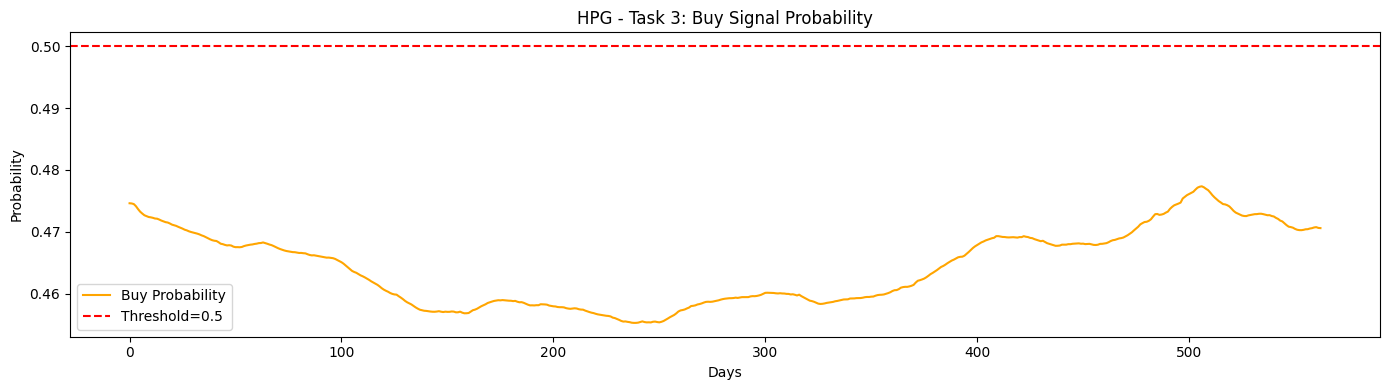


Training Sell Signal Model (Task 3.2)
Class distribution in train - 0: 2430, 1: 192


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
              precision    recall  f1-score   support

   No Signal       0.94      1.00      0.97       528
        Sell       0.00      0.00      0.00        35

    accuracy                           0.94       563
   macro avg       0.47      0.50      0.48       563
weighted avg       0.88      0.94      0.91       563



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


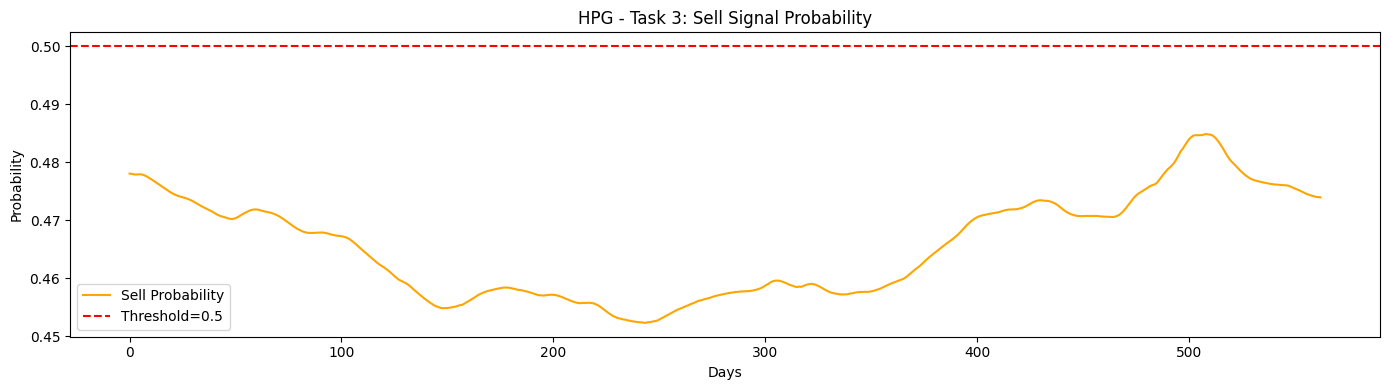

In [26]:
# Task 3.1 & Task 3.2
from tensorflow.keras.layers import Input
from sklearn.metrics import classification_report

def make_classification_dataset(df, window_size, features, label_col,
                                  train_ratio=0.7, val_ratio=0.15):
    data = df[features].values
    labels = df[label_col].values

    scaler = MinMaxScaler()
    data_scaled = scaler.fit_transform(data)

    X, y = [], []
    for i in range(window_size, len(data_scaled)):
        X.append(data_scaled[i - window_size:i])
        y.append(labels[i])

    X, y = np.array(X), np.array(y)

    n = len(X)
    train_end = int(n * train_ratio)
    val_end   = int(n * (train_ratio + val_ratio))

    return (X[:train_end], y[:train_end],
            X[train_end:val_end], y[train_end:val_end],
            X[val_end:], y[val_end:])


def build_lstm_classifier(window_size, n_features):
    model = Sequential([
        LSTM(64, return_sequences=True, input_shape=(window_size, n_features)),
        Dropout(0.2),
        LSTM(32, return_sequences=False),
        Dropout(0.2),
        Dense(1, activation='sigmoid')  # binary classification
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model


# Train Buy and Sell models
for signal in ['Buy', 'Sell']:
    print(f"\n{'='*40}")
    print(f"Training {signal} Signal Model (Task 3.{'1' if signal=='Buy' else '2'})")
    print('='*40)

    X_tr, y_tr, X_v, y_v, X_te, y_te = make_classification_dataset(
        df_hpg_signals, WINDOW_SIZE, VN_FEATURES, signal
    )

    print(f"Class distribution in train - 0: {(y_tr==0).sum()}, 1: {(y_tr==1).sum()}")

    # Handle class imbalance with class weights
    n_pos = (y_tr == 1).sum()
    n_neg = (y_tr == 0).sum()
    class_weight = {0: 1.0, 1: n_neg / n_pos}

    model_sig = build_lstm_classifier(WINDOW_SIZE, len(VN_FEATURES))
    early_stop = EarlyStopping(monitor='val_loss', patience=5,
                                restore_best_weights=True)
    model_sig.fit(
        X_tr, y_tr,
        validation_data=(X_v, y_v),
        epochs=50, batch_size=32,
        class_weight=class_weight,
        callbacks=[early_stop],
        verbose=0
    )

    # Evaluate
    y_prob = model_sig.predict(X_te).flatten()
    y_pred = (y_prob >= 0.5).astype(int)
    print(classification_report(y_te, y_pred,
                                 target_names=['No Signal', signal]))

    # Plot probability over time
    plt.figure(figsize=(14, 4))
    plt.plot(y_prob, label=f'{signal} Probability', color='orange')
    plt.axhline(0.5, color='red', linestyle='--', label='Threshold=0.5')
    plt.title(f'HPG - Task 3: {signal} Signal Probability')
    plt.xlabel('Days')
    plt.ylabel('Probability')
    plt.legend()
    plt.tight_layout()
    plt.show()

Buy signals: 131
Sell signals: 134
Total rows: 3788

Retraining Buy Signal Model
Class weight for Buy: 26.18


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step

Threshold=0.3
              precision    recall  f1-score   support

   No Signal       0.97      0.91      0.94       542
         Buy       0.02      0.06      0.03        18

    accuracy                           0.88       560
   macro avg       0.49      0.48      0.48       560
weighted avg       0.94      0.88      0.91       560


Threshold=0.4
              precision    recall  f1-score   support

   No Signal       0.97      1.00      0.98       542
         Buy       0.00      0.00      0.00        18

    accuracy                           0.97       560
   macro avg       0.48      0.50      0.49       560
weighted avg       0.94      0.97      0.95       560


Threshold=0.5
              precision    recall  f1-score   support

   No Signal       0.97      1.00      0.98       542
         Buy       0.00      0.00      0.00        18

    accuracy                           0.97       560
   macro avg       0.48      0.50      0.49

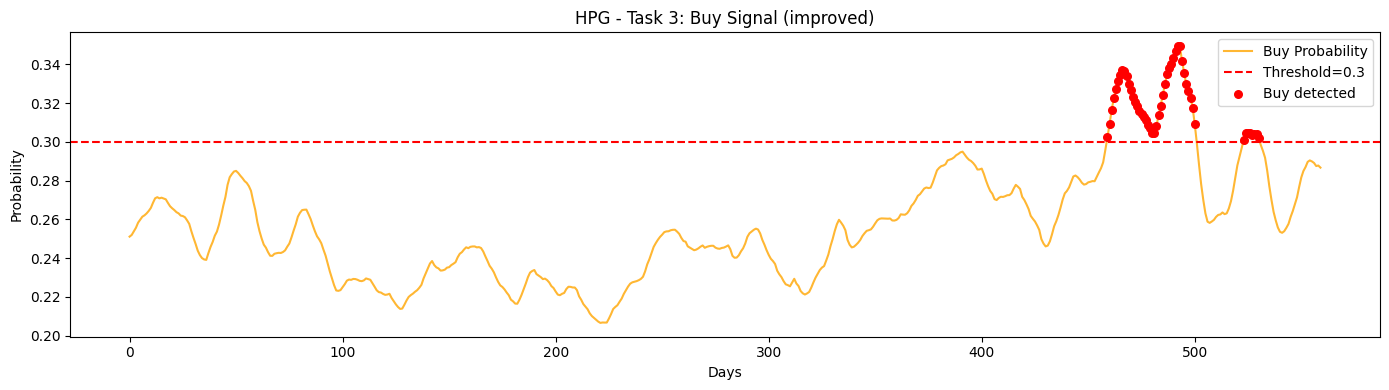


Retraining Sell Signal Model
Class weight for Sell: 23.85


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step

Threshold=0.3
              precision    recall  f1-score   support

   No Signal       0.98      0.72      0.83       546
        Sell       0.03      0.36      0.06        14

    accuracy                           0.71       560
   macro avg       0.50      0.54      0.45       560
weighted avg       0.95      0.71      0.81       560


Threshold=0.4
              precision    recall  f1-score   support

   No Signal       0.98      0.97      0.97       546
        Sell       0.06      0.07      0.06        14

    accuracy                           0.95       560
   macro avg       0.52      0.52      0.52       560
weighted avg       0.95      0.95      0.95       560


Threshold=0.5
              precision    recall  f1-score   support

   No Signal       0.97      1.00      0.99       546
        Sell       0.00      0.00      0.00        14

    accuracy                           0.97       560
   macro avg       0.49      0.50      0.49

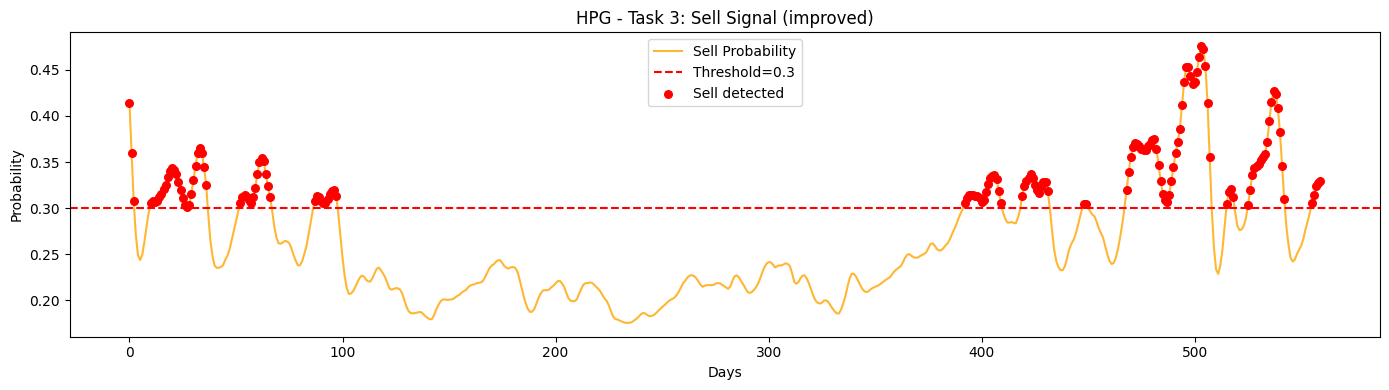

In [27]:
def add_technical_indicators(df):
    df = df.copy()
    # Simple Moving Average
    df['SMA_5']  = df['Close'].rolling(5).mean()
    df['SMA_20'] = df['Close'].rolling(20).mean()
    # RSI
    delta = df['Close'].diff()
    gain  = delta.clip(lower=0).rolling(14).mean()
    loss  = (-delta.clip(upper=0)).rolling(14).mean()
    rs    = gain / (loss + 1e-9)
    df['RSI'] = 100 - (100 / (1 + rs))
    # MACD
    ema12 = df['Close'].ewm(span=12).mean()
    ema26 = df['Close'].ewm(span=26).mean()
    df['MACD'] = ema12 - ema26
    df = df.dropna().reset_index(drop=True)
    return df

def add_better_signals(df, window=10):
    """Better label: local min/max within rolling window"""
    df = df.copy()
    df['Buy']  = 0
    df['Sell'] = 0
    for i in range(window, len(df) - window):
        window_prices = df['Close'].iloc[i-window:i+window+1]
        if df['Close'].iloc[i] == window_prices.min():
            df.loc[i, 'Buy'] = 1
        if df['Close'].iloc[i] == window_prices.max():
            df.loc[i, 'Sell'] = 1
    return df

# Apply
df_hpg_v2 = add_technical_indicators(df_vn_sample)
df_hpg_v2 = add_better_signals(df_hpg_v2, window=10)

VN_FEATURES_V2 = ['Open', 'High', 'Low', 'Close', 'Volume',
                   'SMA_5', 'SMA_20', 'RSI', 'MACD']

print("Buy signals:", df_hpg_v2['Buy'].sum())
print("Sell signals:", df_hpg_v2['Sell'].sum())
print("Total rows:", len(df_hpg_v2))

# Retrain with better features + lower threshold
for signal in ['Buy', 'Sell']:
    print(f"\n{'='*40}")
    print(f"Retraining {signal} Signal Model")
    print('='*40)

    X_tr, y_tr, X_v, y_v, X_te, y_te = make_classification_dataset(
        df_hpg_v2, WINDOW_SIZE, VN_FEATURES_V2, signal
    )

    n_pos = max((y_tr == 1).sum(), 1)
    n_neg = (y_tr == 0).sum()
    class_weight = {0: 1.0, 1: n_neg / n_pos}
    print(f"Class weight for {signal}: {class_weight[1]:.2f}")

    model_sig = build_lstm_classifier(WINDOW_SIZE, len(VN_FEATURES_V2))
    early_stop = EarlyStopping(monitor='val_loss', patience=5,
                                restore_best_weights=True)
    model_sig.fit(
        X_tr, y_tr,
        validation_data=(X_v, y_v),
        epochs=50, batch_size=32,
        class_weight=class_weight,
        callbacks=[early_stop],
        verbose=0
    )

    y_prob = model_sig.predict(X_te).flatten()

    # Try lower threshold since signals are rare
    for threshold in [0.3, 0.4, 0.5]:
        y_pred = (y_prob >= threshold).astype(int)
        print(f"\nThreshold={threshold}")
        print(classification_report(y_te, y_pred,
                                     target_names=['No Signal', signal],
                                     zero_division=0))

    # Plot with best threshold
    best_threshold = 0.3
    y_pred_best = (y_prob >= best_threshold).astype(int)

    plt.figure(figsize=(14, 4))
    plt.plot(y_prob, label=f'{signal} Probability', color='orange', alpha=0.8)
    plt.axhline(best_threshold, color='red', linestyle='--',
                label=f'Threshold={best_threshold}')
    signal_days = np.where(y_pred_best == 1)[0]
    plt.scatter(signal_days, y_prob[signal_days],
                color='red', s=30, zorder=5, label=f'{signal} detected')
    plt.title(f'HPG - Task 3: {signal} Signal (improved)')
    plt.xlabel('Days')
    plt.ylabel('Probability')
    plt.legend()
    plt.tight_layout()
    plt.show()

Buy signals: 893 (23.6%)
Sell signals: 1078 (28.5%)
Total rows: 3783

Training Buy Signal (SMOTE version)
After SMOTE - 0: 1989, 1: 1989


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step

Threshold=0.3
              precision    recall  f1-score   support

   No Signal       0.00      0.00      0.00       417
         Buy       0.25      1.00      0.41       142

    accuracy                           0.25       559
   macro avg       0.13      0.50      0.20       559
weighted avg       0.06      0.25      0.10       559


Threshold=0.4
              precision    recall  f1-score   support

   No Signal       0.00      0.00      0.00       417
         Buy       0.25      1.00      0.41       142

    accuracy                           0.25       559
   macro avg       0.13      0.50      0.20       559
weighted avg       0.06      0.25      0.10       559


Threshold=0.5
              precision    recall  f1-score   support

   No Signal       0.00      0.00      0.00       417
         Buy       0.25      1.00      0.41       142

    accuracy                           0.25       559
   macro avg       0.13      0.50      0.20

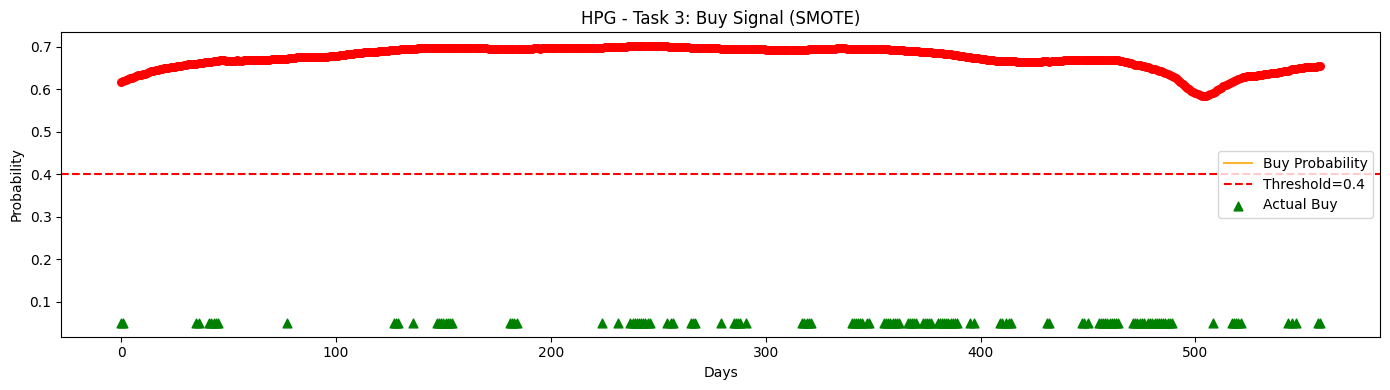


Training Sell Signal (SMOTE version)
After SMOTE - 0: 1842, 1: 1842


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step

Threshold=0.3
              precision    recall  f1-score   support

   No Signal       0.00      0.00      0.00       399
        Sell       0.29      1.00      0.45       160

    accuracy                           0.29       559
   macro avg       0.14      0.50      0.22       559
weighted avg       0.08      0.29      0.13       559


Threshold=0.4
              precision    recall  f1-score   support

   No Signal       0.00      0.00      0.00       399
        Sell       0.29      1.00      0.45       160

    accuracy                           0.29       559
   macro avg       0.14      0.50      0.22       559
weighted avg       0.08      0.29      0.13       559


Threshold=0.5
              precision    recall  f1-score   support

   No Signal       0.71      1.00      0.83       399
        Sell       0.00      0.00      0.00       160

    accuracy                           0.71       559
   macro avg       0.36      0.50      0.42

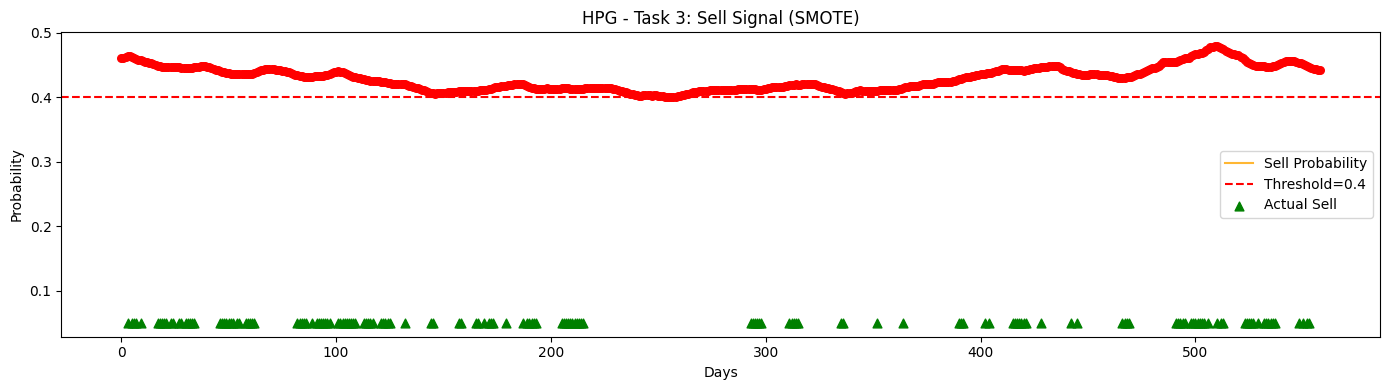

In [28]:
!pip install imbalanced-learn -q

from imblearn.over_sampling import SMOTE

def add_signals_pct(df, window=5, pct_threshold=0.03):
    """
    More signals: buy if price drops >3% in next window,
    sell if price rises >3% in next window
    """
    df = df.copy()
    df['future_return'] = df['Close'].shift(-window) / df['Close'] - 1
    df['Buy']  = (df['future_return'] < -pct_threshold).astype(int)
    df['Sell'] = (df['future_return'] >  pct_threshold).astype(int)
    df = df.dropna().reset_index(drop=True)
    return df

df_hpg_v3 = add_technical_indicators(df_vn_sample)
df_hpg_v3 = add_signals_pct(df_hpg_v3, window=5, pct_threshold=0.03)

print("Buy signals:", df_hpg_v3['Buy'].sum(),
      f"({df_hpg_v3['Buy'].mean()*100:.1f}%)")
print("Sell signals:", df_hpg_v3['Sell'].sum(),
      f"({df_hpg_v3['Sell'].mean()*100:.1f}%)")
print("Total rows:", len(df_hpg_v3))

for signal in ['Buy', 'Sell']:
    print(f"\n{'='*40}")
    print(f"Training {signal} Signal (SMOTE version)")
    print('='*40)

    X_tr, y_tr, X_v, y_v, X_te, y_te = make_classification_dataset(
        df_hpg_v3, WINDOW_SIZE, VN_FEATURES_V2, signal
    )

    # Reshape for SMOTE (needs 2D)
    n_samples, n_steps, n_feats = X_tr.shape
    X_tr_2d = X_tr.reshape(n_samples, n_steps * n_feats)

    # Apply SMOTE to balance classes
    sm = SMOTE(random_state=42)
    X_tr_res, y_tr_res = sm.fit_resample(X_tr_2d, y_tr)
    X_tr_res = X_tr_res.reshape(-1, n_steps, n_feats)

    print(f"After SMOTE - 0: {(y_tr_res==0).sum()}, 1: {(y_tr_res==1).sum()}")

    model_sig = build_lstm_classifier(WINDOW_SIZE, len(VN_FEATURES_V2))
    early_stop = EarlyStopping(monitor='val_loss', patience=5,
                                restore_best_weights=True)
    model_sig.fit(
        X_tr_res, y_tr_res,
        validation_data=(X_v, y_v),
        epochs=50, batch_size=32,
        callbacks=[early_stop],
        verbose=0
    )

    y_prob = model_sig.predict(X_te).flatten()

    for threshold in [0.3, 0.4, 0.5]:
        y_pred = (y_prob >= threshold).astype(int)
        print(f"\nThreshold={threshold}")
        print(classification_report(y_te, y_pred,
                                     target_names=['No Signal', signal],
                                     zero_division=0))

    # Plot
    plt.figure(figsize=(14, 4))
    plt.plot(y_prob, color='orange', label=f'{signal} Probability', alpha=0.8)
    plt.axhline(0.4, color='red', linestyle='--', label='Threshold=0.4')
    detected = np.where(y_prob >= 0.4)[0]
    plt.scatter(detected, y_prob[detected], color='red', s=30, zorder=5)
    actual = np.where(y_te == 1)[0]
    plt.scatter(actual, [0.05]*len(actual), color='green',
                marker='^', s=40, zorder=5, label=f'Actual {signal}')
    plt.title(f'HPG - Task 3: {signal} Signal (SMOTE)')
    plt.xlabel('Days')
    plt.ylabel('Probability')
    plt.legend()
    plt.tight_layout()
    plt.show()

Task 3 — Architecture Comparison: LSTM vs GRU vs CNN vs CNN-LSTM
(Buy signal)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


  LSTM: F1=0.4051 | Time=30.5s
  GRU: F1=0.0000 | Time=11.4s
  CNN: F1=0.4051 | Time=10.9s
  CNN-LSTM: F1=0.4051 | Time=9.0s

--- Task 3: Architecture Comparison Table (Buy Signal) ---
              F1  Precision  Recall  Train Time (s)    Params
LSTM      0.4051      0.254     1.0            30.5   31393.0
GRU       0.0000      0.000     0.0            11.4   90689.0
CNN       0.4051      0.254     1.0            10.9   21345.0
CNN-LSTM  0.4051      0.254     1.0             9.0  100737.0


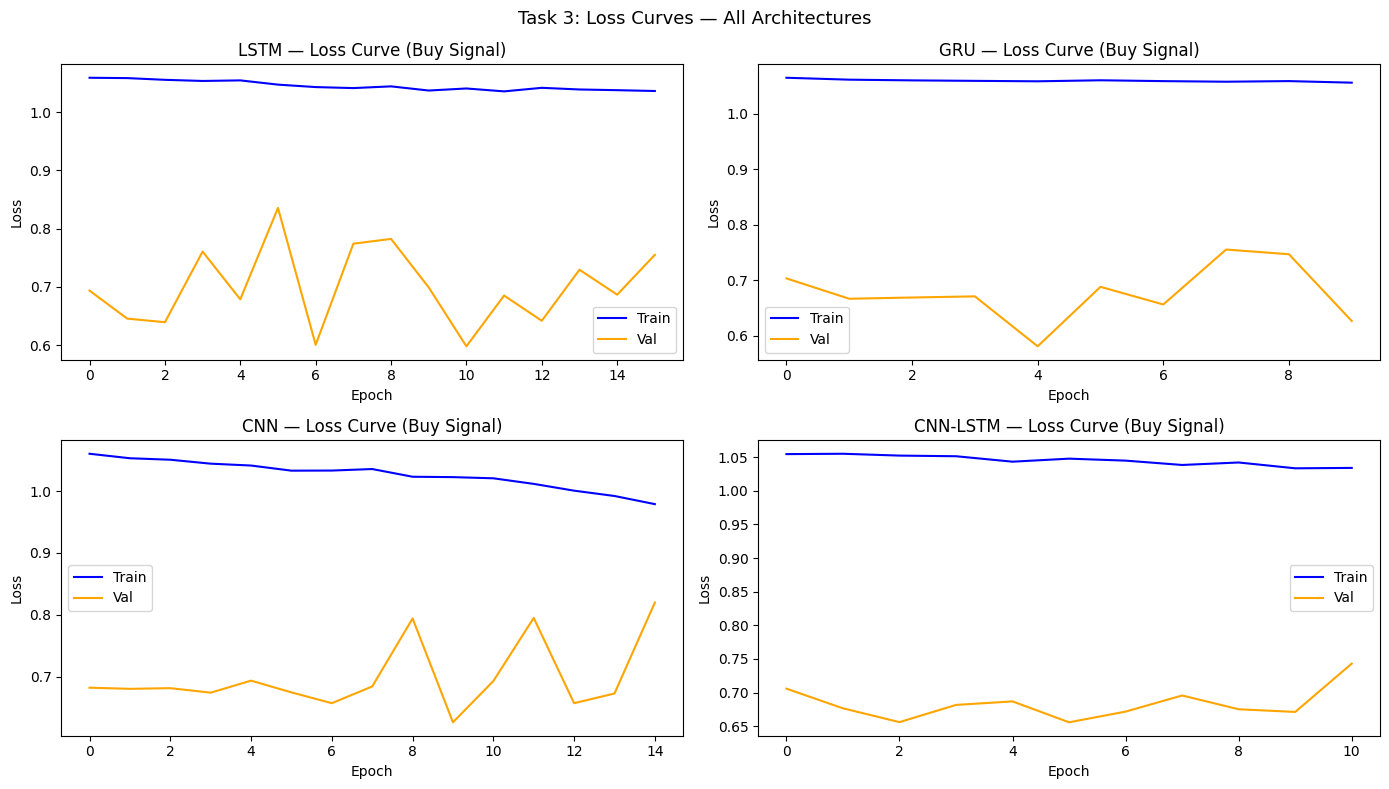

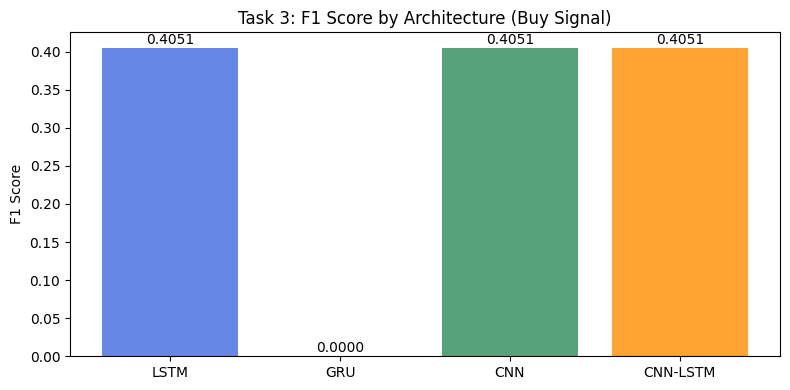

In [29]:
from tensorflow.keras.layers import GRU, Conv1D, MaxPooling1D, Flatten
from sklearn.metrics import classification_report
import time

def build_gru_classifier(window_size, n_features, units=64, lr=1e-3):
    model = Sequential([
        GRU(units, return_sequences=True,
            input_shape=(window_size, n_features)),
        Dropout(0.2),
        GRU(units // 2, return_sequences=False),
        Dropout(0.2),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=Adam(lr), loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

def build_cnn_classifier(window_size, n_features, filters=64, lr=1e-3):
    model = Sequential([
        Conv1D(filters=filters, kernel_size=3, activation='relu',
               input_shape=(window_size, n_features)),
        MaxPooling1D(pool_size=2),
        Conv1D(filters=filters // 2, kernel_size=3, activation='relu'),
        MaxPooling1D(pool_size=2),
        Flatten(),
        Dense(32, activation='relu'),
        Dropout(0.2),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=Adam(lr), loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

def build_cnn_lstm_classifier(window_size, n_features, units=64, filters=64, lr=1e-3):
    model = Sequential([
        Conv1D(filters=filters, kernel_size=3, activation='relu',
               input_shape=(window_size, n_features)),
        MaxPooling1D(pool_size=2),
        LSTM(units, return_sequences=False),
        Dropout(0.2),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=Adam(lr), loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

print("Task 3 — Architecture Comparison: LSTM vs GRU vs CNN vs CNN-LSTM")
print("(Buy signal)")

BEST_UNITS_VN = best_config_2_1['units']
BEST_LR_VN    = best_config_2_1['lr']

arch_classifiers = {
    'LSTM':     build_lstm_classifier(WINDOW_SIZE, len(VN_FEATURES_V2)),
    'GRU':      build_gru_classifier(WINDOW_SIZE, len(VN_FEATURES_V2),
                                      BEST_UNITS_VN, BEST_LR_VN),
    'CNN':      build_cnn_classifier(WINDOW_SIZE, len(VN_FEATURES_V2),
                                      lr=BEST_LR_VN),
    'CNN-LSTM': build_cnn_lstm_classifier(WINDOW_SIZE, len(VN_FEATURES_V2),
                                           BEST_UNITS_VN, lr=BEST_LR_VN),
}

X_tr_c, y_tr_c, X_v_c, y_v_c, X_te_c, y_te_c = make_classification_dataset(
    df_hpg_v3, WINDOW_SIZE, VN_FEATURES_V2, 'Buy'
)
n_pos = max((y_tr_c == 1).sum(), 1)
n_neg = (y_tr_c == 0).sum()
class_weight_c = {0: 1.0, 1: n_neg / n_pos}

arch_clf_results = {}
for name, model in arch_classifiers.items():
    es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    t0 = time.time()
    hist_c = model.fit(X_tr_c, y_tr_c,
                       validation_data=(X_v_c, y_v_c),
                       epochs=50, batch_size=32,
                       class_weight=class_weight_c,
                       callbacks=[es], verbose=0)
    train_time = time.time() - t0
    y_prob_c = model.predict(X_te_c, verbose=0).flatten()
    y_pred_c = (y_prob_c >= 0.4).astype(int)
    from sklearn.metrics import f1_score, precision_score, recall_score
    arch_clf_results[name] = {
        'F1':            f1_score(y_te_c, y_pred_c, zero_division=0),
        'Precision':     precision_score(y_te_c, y_pred_c, zero_division=0),
        'Recall':        recall_score(y_te_c, y_pred_c, zero_division=0),
        'Train Time (s)': round(train_time, 1),
        'Params':        model.count_params(),
        'history':       hist_c,
    }
    print(f"  {name}: F1={arch_clf_results[name]['F1']:.4f} | "
          f"Time={train_time:.1f}s")

df_clf = pd.DataFrame({k: {m: v for m, v in d.items() if m != 'history'}
                        for k, d in arch_clf_results.items()}).T
print("\n--- Task 3: Architecture Comparison Table (Buy Signal) ---")
print(df_clf[['F1', 'Precision', 'Recall',
              'Train Time (s)', 'Params']].round(4).to_string())

# Loss curves
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, name in zip(axes.flatten(), arch_clf_results.keys()):
    h = arch_clf_results[name]['history']
    ax.plot(h.history['loss'],     label='Train', color='blue')
    ax.plot(h.history['val_loss'], label='Val',   color='orange')
    ax.set_title(f'{name} — Loss Curve (Buy Signal)')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()
plt.suptitle('Task 3: Loss Curves — All Architectures', fontsize=13)
plt.tight_layout()
plt.show()

# Bar chart F1
names_c = list(arch_clf_results.keys())
f1s     = [arch_clf_results[n]['F1'] for n in names_c]
colors_c = ['royalblue', 'tomato', 'seagreen', 'darkorange']
plt.figure(figsize=(8, 4))
bars = plt.bar(names_c, f1s, color=colors_c, alpha=0.8)
for bar, v in zip(bars, f1s):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.005,
             f'{v:.4f}', ha='center', fontsize=10)
plt.title('Task 3: F1 Score by Architecture (Buy Signal)')
plt.ylabel('F1 Score')
plt.tight_layout()
plt.show()

Task 3.2 — Architecture Comparison: LSTM vs GRU vs CNN vs CNN-LSTM
(Sell signal)
Sell signal distribution — Train: 764 pos / 1842 neg


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


  LSTM: F1=0.4709 | Precision=0.3117 | Recall=0.9625 | Time=19.1s
  GRU: F1=0.3557 | Precision=0.3333 | Recall=0.3812 | Time=13.9s
  CNN: F1=0.4451 | Precision=0.2873 | Recall=0.9875 | Time=9.9s
  CNN-LSTM: F1=0.4780 | Precision=0.3444 | Recall=0.7812 | Time=7.7s

--- Task 3.2: Architecture Comparison Table (Sell Signal) ---
              F1  Precision  Recall  Train Time (s)    Params
LSTM      0.4709     0.3117  0.9625            19.1   31393.0
GRU       0.3557     0.3333  0.3812            13.9   90689.0
CNN       0.4451     0.2873  0.9875             9.9   21345.0
CNN-LSTM  0.4780     0.3444  0.7812             7.7  100737.0

Best architecture by F1: CNN-LSTM


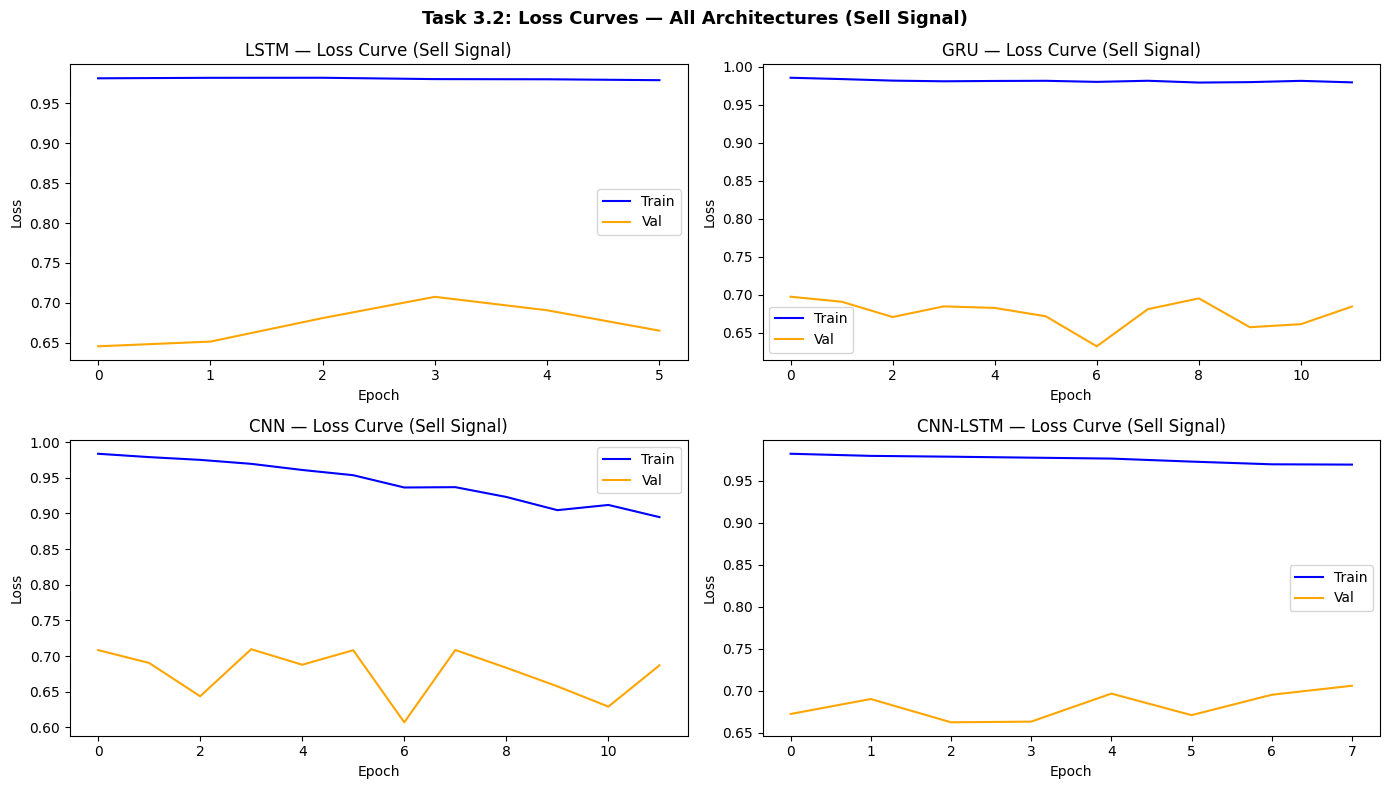

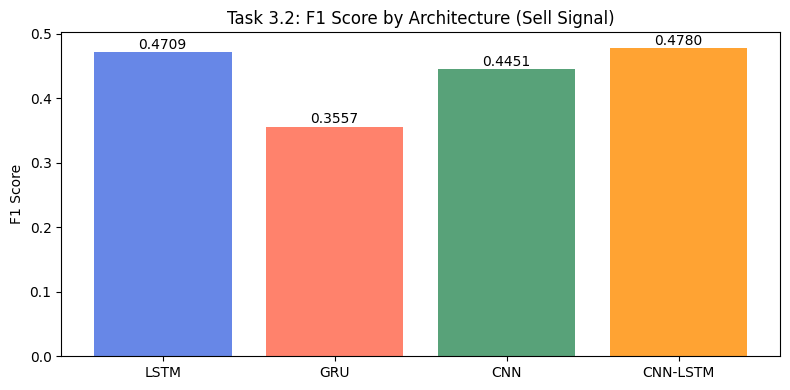

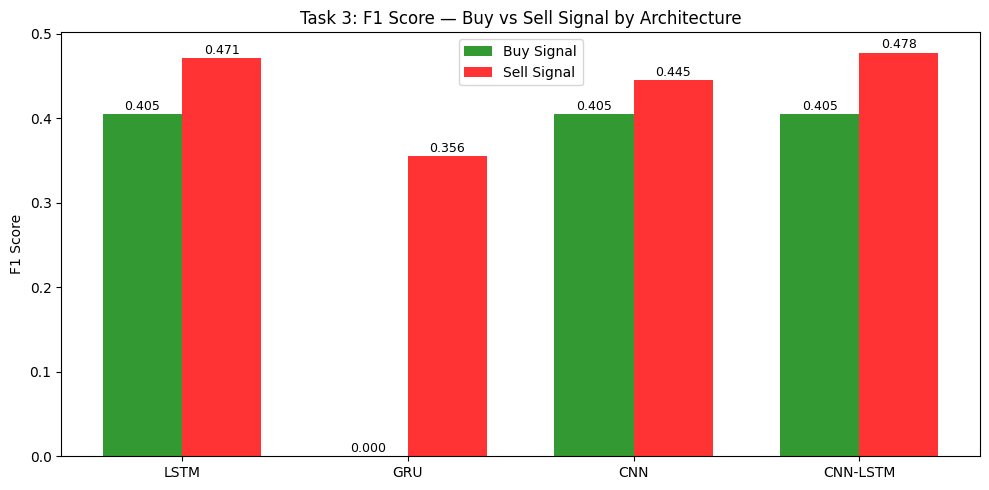


--- Task 3: Combined Summary (Buy + Sell) ---
          Buy F1  Sell F1  Buy Precision  Sell Precision  Buy Recall  Sell Recall  Params
LSTM      0.4051   0.4709          0.254          0.3117         1.0       0.9625   31393
GRU       0.0000   0.3557          0.000          0.3333         0.0       0.3812   90689
CNN       0.4051   0.4451          0.254          0.2873         1.0       0.9875   21345
CNN-LSTM  0.4051   0.4780          0.254          0.3444         1.0       0.7812  100737

Best for Buy Signal:  LSTM (F1=0.4051)
Best for Sell Signal: CNN-LSTM (F1=0.4780)


In [30]:
# ============================================================
# TASK 3.2 — SELL SIGNAL: LSTM vs GRU vs CNN vs CNN-LSTM
# Place AFTER the Task 3 Buy signal architecture comparison cell
# ============================================================

print("Task 3.2 — Architecture Comparison: LSTM vs GRU vs CNN vs CNN-LSTM")
print("(Sell signal)")
print("=" * 55)

# ── Dataset for Sell signal ───────────────────────────────────
X_tr_s, y_tr_s, X_v_s, y_v_s, X_te_s, y_te_s = make_classification_dataset(
    df_hpg_v3, WINDOW_SIZE, VN_FEATURES_V2, 'Sell'
)
n_pos_s = max((y_tr_s == 1).sum(), 1)
n_neg_s = (y_tr_s == 0).sum()
class_weight_s = {0: 1.0, 1: n_neg_s / n_pos_s}

print(f"Sell signal distribution — Train: {(y_tr_s==1).sum()} pos / {(y_tr_s==0).sum()} neg")

# ── Same 4 architectures as Buy signal ───────────────────────
arch_sell = {
    'LSTM':     build_lstm_classifier(WINDOW_SIZE, len(VN_FEATURES_V2)),
    'GRU':      build_gru_classifier(WINDOW_SIZE, len(VN_FEATURES_V2),
                                      BEST_UNITS_VN, BEST_LR_VN),
    'CNN':      build_cnn_classifier(WINDOW_SIZE, len(VN_FEATURES_V2),
                                      lr=BEST_LR_VN),
    'CNN-LSTM': build_cnn_lstm_classifier(WINDOW_SIZE, len(VN_FEATURES_V2),
                                           BEST_UNITS_VN, lr=BEST_LR_VN),
}

arch_sell_results = {}

for name, model in arch_sell.items():
    es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    t0 = time.time()
    hist_s = model.fit(X_tr_s, y_tr_s,
                       validation_data=(X_v_s, y_v_s),
                       epochs=50, batch_size=32,
                       class_weight=class_weight_s,
                       callbacks=[es], verbose=0)
    train_time = time.time() - t0

    y_prob_s = model.predict(X_te_s, verbose=0).flatten()
    y_pred_s = (y_prob_s >= 0.4).astype(int)

    arch_sell_results[name] = {
        'F1':             f1_score(y_te_s, y_pred_s, zero_division=0),
        'Precision':      precision_score(y_te_s, y_pred_s, zero_division=0),
        'Recall':         recall_score(y_te_s, y_pred_s, zero_division=0),
        'Train Time (s)': round(train_time, 1),
        'Params':         model.count_params(),
        'history':        hist_s,
    }
    print(f"  {name}: F1={arch_sell_results[name]['F1']:.4f} | "
          f"Precision={arch_sell_results[name]['Precision']:.4f} | "
          f"Recall={arch_sell_results[name]['Recall']:.4f} | "
          f"Time={train_time:.1f}s")


# ── Summary table ─────────────────────────────────────────────
df_sell = pd.DataFrame({
    k: {m: v for m, v in d.items() if m != 'history'}
    for k, d in arch_sell_results.items()
}).T

print("\n--- Task 3.2: Architecture Comparison Table (Sell Signal) ---")
print(df_sell[['F1', 'Precision', 'Recall',
               'Train Time (s)', 'Params']].round(4).to_string())

best_sell = df_sell['F1'].idxmin()
print(f"\nBest architecture by F1: {df_sell['F1'].idxmax()}")


# ── Plot 1: Loss curves ───────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, name in zip(axes.flatten(), arch_sell_results.keys()):
    h = arch_sell_results[name]['history']
    ax.plot(h.history['loss'],     label='Train', color='blue')
    ax.plot(h.history['val_loss'], label='Val',   color='orange')
    ax.set_title(f'{name} — Loss Curve (Sell Signal)')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()
plt.suptitle('Task 3.2: Loss Curves — All Architectures (Sell Signal)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


# ── Plot 2: F1 bar chart ──────────────────────────────────────
names_s  = list(arch_sell_results.keys())
f1s_s    = [arch_sell_results[n]['F1'] for n in names_s]
colors_s = ['royalblue', 'tomato', 'seagreen', 'darkorange']

plt.figure(figsize=(8, 4))
bars = plt.bar(names_s, f1s_s, color=colors_s, alpha=0.8)
for bar, v in zip(bars, f1s_s):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.005,
             f'{v:.4f}', ha='center', fontsize=10)
plt.title('Task 3.2: F1 Score by Architecture (Sell Signal)')
plt.ylabel('F1 Score')
plt.tight_layout()
plt.show()


# ── Plot 3: Buy vs Sell F1 side-by-side ──────────────────────
# Compare both signals across all architectures in one chart
names_all = list(arch_clf_results.keys())   # from Buy signal cell above
f1_buy  = [arch_clf_results[n]['F1']  for n in names_all]
f1_sell = [arch_sell_results[n]['F1'] for n in names_all]

x = np.arange(len(names_all))
w = 0.35
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - w/2, f1_buy,  w, label='Buy Signal',  color='green', alpha=0.8)
ax.bar(x + w/2, f1_sell, w, label='Sell Signal', color='red',   alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(names_all)
ax.set_title('Task 3: F1 Score — Buy vs Sell Signal by Architecture')
ax.set_ylabel('F1 Score')
ax.legend()
for i, (b, s) in enumerate(zip(f1_buy, f1_sell)):
    ax.text(i - w/2, b + 0.005, f'{b:.3f}', ha='center', fontsize=9)
    ax.text(i + w/2, s + 0.005, f'{s:.3f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()


# ── Combined summary: Buy + Sell ──────────────────────────────
print("\n--- Task 3: Combined Summary (Buy + Sell) ---")
df_combined = pd.DataFrame({
    'Buy F1':       {n: arch_clf_results[n]['F1']  for n in names_all},
    'Sell F1':      {n: arch_sell_results[n]['F1'] for n in names_all},
    'Buy Precision':  {n: arch_clf_results[n]['Precision']  for n in names_all},
    'Sell Precision': {n: arch_sell_results[n]['Precision'] for n in names_all},
    'Buy Recall':   {n: arch_clf_results[n]['Recall']  for n in names_all},
    'Sell Recall':  {n: arch_sell_results[n]['Recall'] for n in names_all},
    'Params':       {n: arch_clf_results[n]['Params']  for n in names_all},
})
print(df_combined.round(4).to_string())

best_buy_arch  = max(names_all, key=lambda n: arch_clf_results[n]['F1'])
best_sell_arch = max(names_all, key=lambda n: arch_sell_results[n]['F1'])
print(f"\nBest for Buy Signal:  {best_buy_arch} "
      f"(F1={arch_clf_results[best_buy_arch]['F1']:.4f})")
print(f"Best for Sell Signal: {best_sell_arch} "
      f"(F1={arch_sell_results[best_sell_arch]['F1']:.4f})")

Evaluating 50 companies...


  0%|          | 0/50 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
  2%|▏         | 1/50 [00:07<05:53,  7.21s/it]/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
  4%|▍         | 2/50 [00:16<06:38,  8.30s/it]/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
  6%|▌      


--- Top 10 Most Profitable Companies ---
             actual_return  predicted_return        mae  volatility
TMS-VNINDEX         2.2380            1.9316  3992.5251      0.0271
SAV-VNINDEX         1.8671            1.6629   747.8781      0.0291
LAF-VNINDEX         1.8000            1.6842   616.2904      0.0498
GMD-VNINDEX         1.7559            1.8128  1827.3025      0.0253
PVD-VNINDEX         1.3129            1.3784   926.8083      0.0343
REE-VNINDEX         1.3004            1.3143  2642.0292      0.0233
FPT-VNINDEX         1.2749            1.0917  6675.1400      0.0187
VSH-VNINDEX         1.2436            0.8716  1795.1350      0.0253
STB-VNINDEX         1.0386            1.0810  1861.4524      0.0292
KDC-VNINDEX         0.8298            0.8267  4585.7974      0.0136


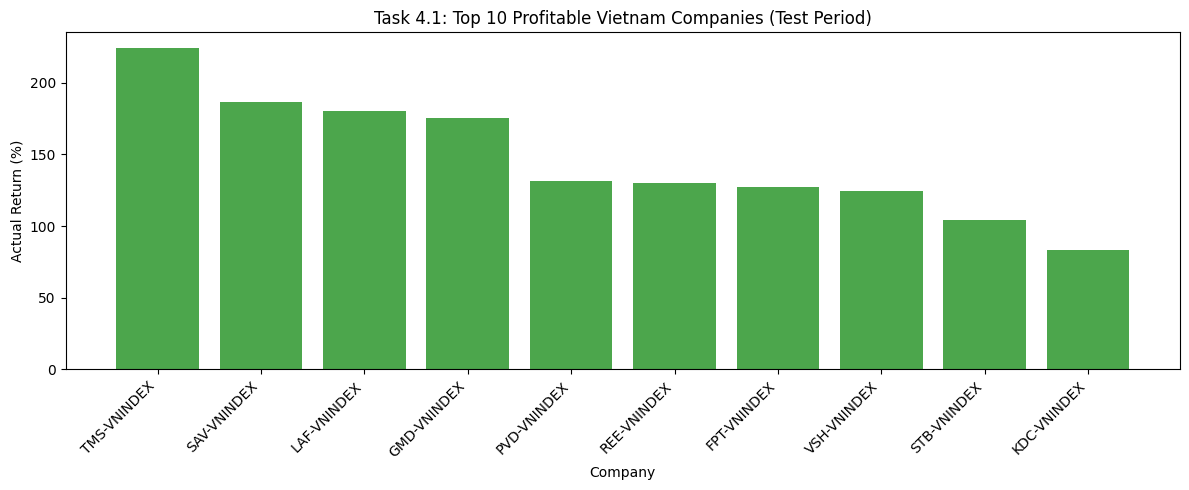

In [31]:
#4.1 Select top profitable companies based on predicted future returns
from tqdm import tqdm

def estimate_profit(df, model, features, window_size, scaler, target_idx, n_features):
    """Estimate average predicted return over test period"""
    _, _, _, _, X_te, y_te, sc = make_dataset(
        df, window_size, features, 'Close'
    )
    if len(X_te) == 0:
        return None
    y_pred = model.predict(X_te, verbose=0)
    y_te_real = inverse_scale(sc, y_te, target_idx, n_features)
    y_pr_real = inverse_scale(sc, y_pred, target_idx, n_features)

    # Estimate profit: average predicted price change
    predicted_return = (y_pr_real[-1] - y_pr_real[0]) / (y_pr_real[0] + 1e-9)
    actual_return    = (y_te_real[-1] - y_te_real[0]) / (y_te_real[0] + 1e-9)
    mae = mean_absolute_error(y_te_real, y_pr_real)
    return {
        'predicted_return': predicted_return,
        'actual_return': actual_return,
        'mae': mae
    }

# Train a shared model then evaluate on multiple VN companies
# Use top 50 companies with most data for speed
vn_companies_sorted = sorted(vn_all_data.items(),
                              key=lambda x: len(x[1]), reverse=True)[:50]

print(f"Evaluating {len(vn_companies_sorted)} companies...")

results = {}
vn_feat_idx = VN_FEATURES.index('Close')

for ticker, df_company in tqdm(vn_companies_sorted):
    try:
        df_company = add_technical_indicators(df_company)
        if len(df_company) < 200:
            continue
        X_tr, y_tr, X_v, y_v, X_te, y_te, sc = make_dataset(
            df_company, WINDOW_SIZE, VN_FEATURES, 'Close'
        )
        if len(X_tr) < 50 or len(X_te) < 10:
            continue

        m = build_lstm_model(WINDOW_SIZE, len(VN_FEATURES))
        es = EarlyStopping(monitor='val_loss', patience=3,
                            restore_best_weights=True)
        m.fit(X_tr, y_tr, validation_data=(X_v, y_v),
              epochs=20, batch_size=32, callbacks=[es], verbose=0)

        y_pred = m.predict(X_te, verbose=0)
        y_te_r = inverse_scale(sc, y_te, vn_feat_idx, len(VN_FEATURES))
        y_pr_r = inverse_scale(sc, y_pred, vn_feat_idx, len(VN_FEATURES))

        actual_return = (y_te_r[-1] - y_te_r[0]) / (y_te_r[0] + 1e-9)
        predicted_return = (y_pr_r[-1] - y_pr_r[0]) / (y_pr_r[0] + 1e-9)
        mae = mean_absolute_error(y_te_r, y_pr_r)
        volatility = np.std(np.diff(y_te_r) / (y_te_r[:-1] + 1e-9))

        results[ticker] = {
            'actual_return': actual_return,
            'predicted_return': predicted_return,
            'mae': mae,
            'volatility': volatility
        }
    except Exception as e:
        continue

# Create results DataFrame
df_results = pd.DataFrame(results).T
df_results = df_results.sort_values('actual_return', ascending=False)
print("\n--- Top 10 Most Profitable Companies ---")
print(df_results.head(10)[['actual_return', 'predicted_return',
                             'mae', 'volatility']].round(4))

# Plot top 10
top10 = df_results.head(10)
plt.figure(figsize=(12, 5))
plt.bar(range(len(top10)), top10['actual_return'] * 100, color='green', alpha=0.7)
plt.xticks(range(len(top10)), top10.index, rotation=45, ha='right')
plt.title('Task 4.1: Top 10 Profitable Vietnam Companies (Test Period)')
plt.xlabel('Company')
plt.ylabel('Actual Return (%)')
plt.tight_layout()
plt.show()

--- Task 4.1: Backtest across representative companies ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  HPG (Steel/Materials): Strategy=49.4%, B&H=-4.1%, Sharpe=0.54


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  FPT (Tech/Telecom): Strategy=51.7%, B&H=129.7%, Sharpe=0.71


...

  VNM (Consumer/FMCG): Strategy=-25.4%, B&H=-11.2%, Sharpe=-0.74


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  VIC (Real Estate): Strategy=-7.8%, B&H=-42.0%, Sharpe=-0.15


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  VCB (Banking): Strategy=16.3%, B&H=23.1%, Sharpe=0.40

--- Task 4.1: Backtest Summary ---
            industry          MAE Strategy Return (%) Buy&Hold Return (%)    Sharpe N Trades
HPG  Steel/Materials     1794.726           49.397163           -4.145699   0.53567       40
FPT     Tech/Telecom  2633.844292            51.67065             129.744  0.706178       76
VNM    Consumer/FMCG  1654.797913          -25.353055          -11.155566 -0.737418       70
VIC      Real Estate  2599.014328           -7.827648          -41.986147 -0.150432       58
VCB          Banking  2252.062774           16.312765           23.108928  0.397339       50


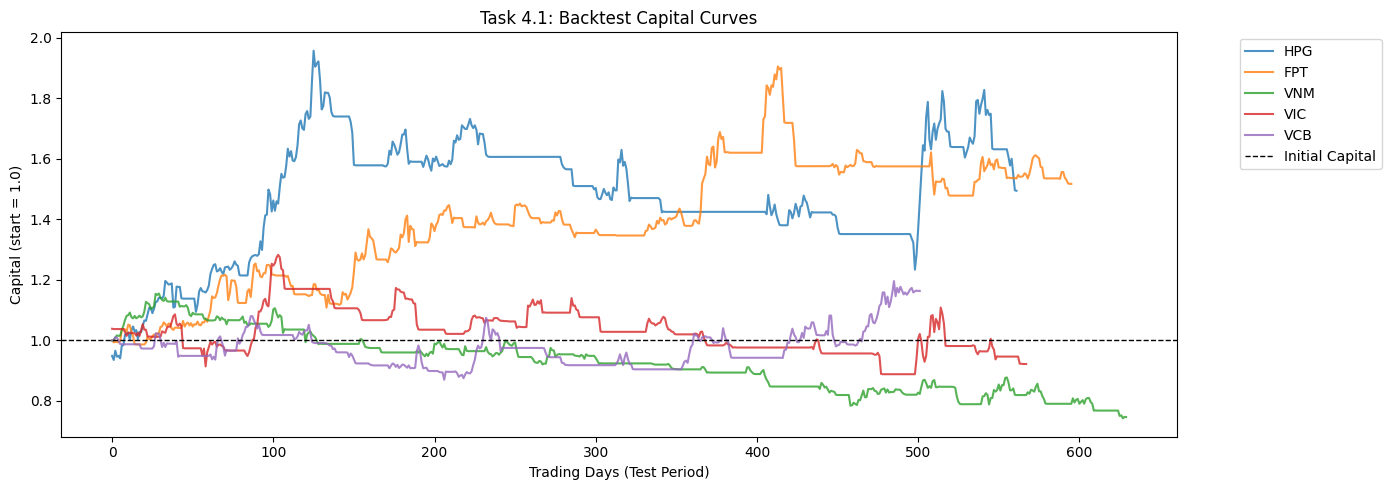

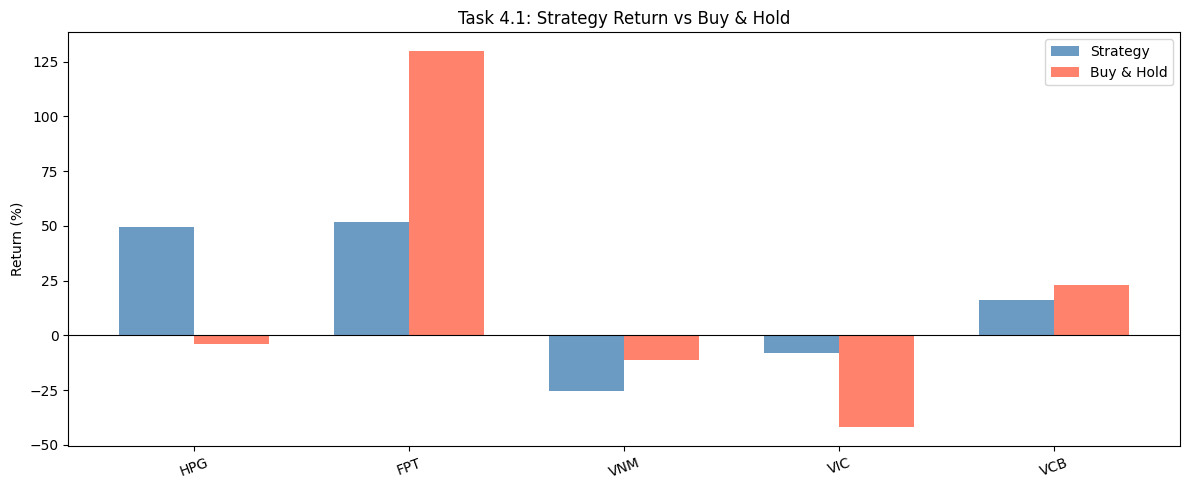


--- Top profitable companies (by Strategy Return) ---
            industry Strategy Return (%)    Sharpe          MAE
FPT     Tech/Telecom            51.67065  0.706178  2633.844292
HPG  Steel/Materials           49.397163   0.53567     1794.726
VCB          Banking           16.312765  0.397339  2252.062774
VIC      Real Estate           -7.827648 -0.150432  2599.014328
VNM    Consumer/FMCG          -25.353055 -0.737418  1654.797913


In [32]:
def backtest_simple(y_true: np.ndarray, y_pred: np.ndarray,
                    transaction_cost: float = 0.001) -> dict:
    n        = min(len(y_true), len(y_pred)) - 1
    capital  = 1.0
    position = 0
    daily_returns = []
    trades = 0

    for t in range(n):
        signal        = 1 if y_pred[t] < y_pred[t + 1] else 0
        actual_return = (y_true[t + 1] - y_true[t]) / (y_true[t] + 1e-9)

        if signal == 1 and position == 0:
            position  = 1
            capital  *= (1 - transaction_cost)
            trades   += 1
        elif signal == 0 and position == 1:
            position  = 0
            capital  *= (1 - transaction_cost)
            trades   += 1

        if position == 1:
            capital *= (1 + actual_return)

        daily_returns.append(capital)

    bnh_return = (y_true[-1] - y_true[0]) / (y_true[0] + 1e-9)
    dr         = np.diff([1.0] + daily_returns)
    sharpe     = (np.mean(dr) / (np.std(dr) + 1e-9)) * np.sqrt(252)

    return {
        'total_return':  capital - 1.0,
        'bnh_return':    bnh_return,
        'sharpe':        sharpe,
        'n_trades':      trades,
        'capital_curve': daily_returns,
    }


print("--- Task 4.1: Backtest across representative companies ---")
backtest_results = {}
vn_feat_idx = VN_FEATURES.index('Close')

for industry, ticker, key in selected_tickers:
    df_co = vn_all_data[key].copy()  # sửa vn_filtered -> vn_all_data
    if len(df_co) < 200:
        continue
    try:
        X_tr_b, y_tr_b, X_vl_b, y_vl_b, X_te_b, y_te_b, sc_b = make_dataset(
            df_co, WINDOW_SIZE, VN_FEATURES, VN_TARGET
        )
        m_b = build_lstm_tunable(WINDOW_SIZE, len(VN_FEATURES),
                                  best_config_2_1['units'],
                                  best_config_2_1['lr'])
        es  = EarlyStopping(monitor='val_loss', patience=5,
                             restore_best_weights=True)
        m_b.fit(X_tr_b, y_tr_b,
                validation_data=(X_vl_b, y_vl_b),
                epochs=30, batch_size=32, callbacks=[es], verbose=0)

        y_pred_b = m_b.predict(X_te_b, verbose=0)
        y_te_rb  = inverse_scale(sc_b, y_te_b,   vn_feat_idx, len(VN_FEATURES))
        y_pr_rb  = inverse_scale(sc_b, y_pred_b, vn_feat_idx, len(VN_FEATURES))

        bt     = backtest_simple(y_te_rb, y_pr_rb)
        mae_b  = mean_absolute_error(y_te_rb, y_pr_rb)
        rmse_b = np.sqrt(mean_squared_error(y_te_rb, y_pr_rb))

        backtest_results[ticker] = {
            'industry':            industry,
            'MAE':                 mae_b,
            'RMSE':                rmse_b,
            'Strategy Return (%)': bt['total_return'] * 100,
            'Buy&Hold Return (%)': bt['bnh_return']   * 100,
            'Sharpe':              bt['sharpe'],
            'N Trades':            bt['n_trades'],
            'capital_curve':       bt['capital_curve'],
        }
        print(f"  {ticker} ({industry}): "
              f"Strategy={bt['total_return']*100:.1f}%, "
              f"B&H={bt['bnh_return']*100:.1f}%, "
              f"Sharpe={bt['sharpe']:.2f}")
    except Exception as e:
        print(f"  {ticker}: error — {e}")


if len(backtest_results) == 0:
    print("Không có kết quả backtest nào!")
else:
    df_bt = pd.DataFrame({
        k: {m: v for m, v in d.items() if m != 'capital_curve'}
        for k, d in backtest_results.items()
    }).T

    print("\n--- Task 4.1: Backtest Summary ---")
    print(df_bt[['industry', 'MAE', 'Strategy Return (%)',
                  'Buy&Hold Return (%)', 'Sharpe', 'N Trades']].round(2).to_string())

    plt.figure(figsize=(14, 5))
    for ticker, d in backtest_results.items():
        plt.plot(d['capital_curve'], label=ticker, alpha=0.8)
    plt.axhline(1.0, color='black', linestyle='--', linewidth=1,
                label='Initial Capital')
    plt.title('Task 4.1: Backtest Capital Curves')
    plt.xlabel('Trading Days (Test Period)')
    plt.ylabel('Capital (start = 1.0)')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

    x = np.arange(len(df_bt))
    w = 0.35
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.bar(x - w/2,
           df_bt['Strategy Return (%)'].astype(float),
           w, label='Strategy', color='steelblue', alpha=0.8)
    ax.bar(x + w/2,
           df_bt['Buy&Hold Return (%)'].astype(float),
           w, label='Buy & Hold', color='tomato', alpha=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(df_bt.index, rotation=20)
    ax.set_title('Task 4.1: Strategy Return vs Buy & Hold')
    ax.set_ylabel('Return (%)')
    ax.axhline(0, color='black', linewidth=0.8)
    ax.legend()
    plt.tight_layout()
    plt.show()

    df_bt_sorted = df_bt.sort_values('Strategy Return (%)', ascending=False)
    print("\n--- Top profitable companies (by Strategy Return) ---")
    print(df_bt_sorted[['industry', 'Strategy Return (%)',
                          'Sharpe', 'MAE']].round(2).to_string())

Task 4.1 — Architecture Comparison: LSTM vs GRU vs CNN (HPG regression)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


  LSTM: MAE=1398.6516 | RMSE=1763.4088 | Time=15.8s
  GRU: MAE=864.7509 | RMSE=1086.7023 | Time=31.6s
  CNN: MAE=2331.8210 | RMSE=2962.5716 | Time=13.8s

--- Task 4.1: Architecture Comparison Table ---
            MAE       RMSE  Train Time (s)    Params
LSTM  1398.6516  1763.4088            15.8  118081.0
GRU    864.7509  1086.7023            31.6   89153.0
CNN   2331.8210  2962.5716            13.8   20577.0


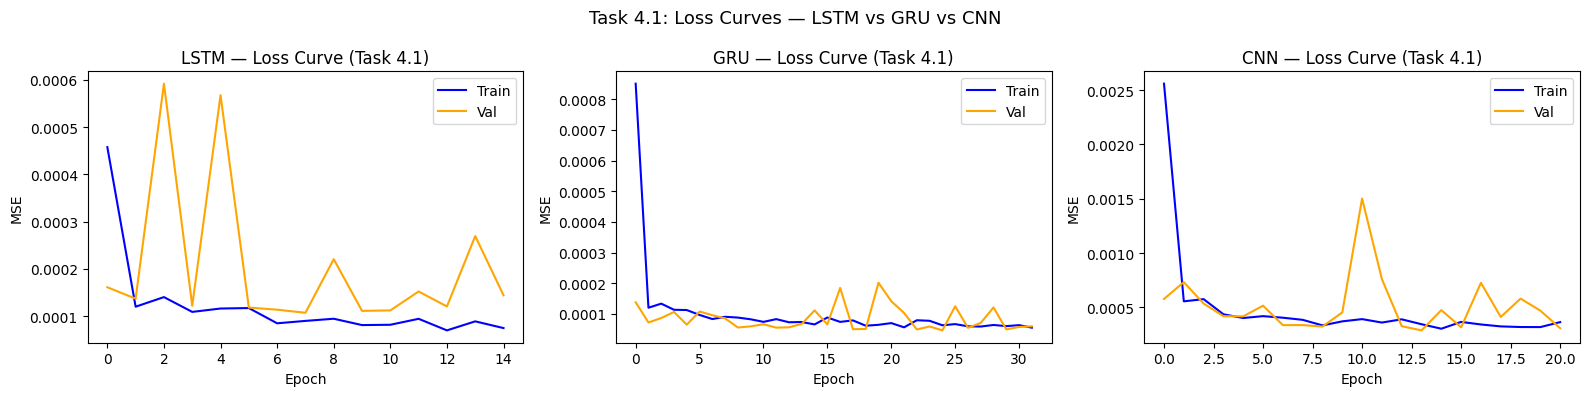

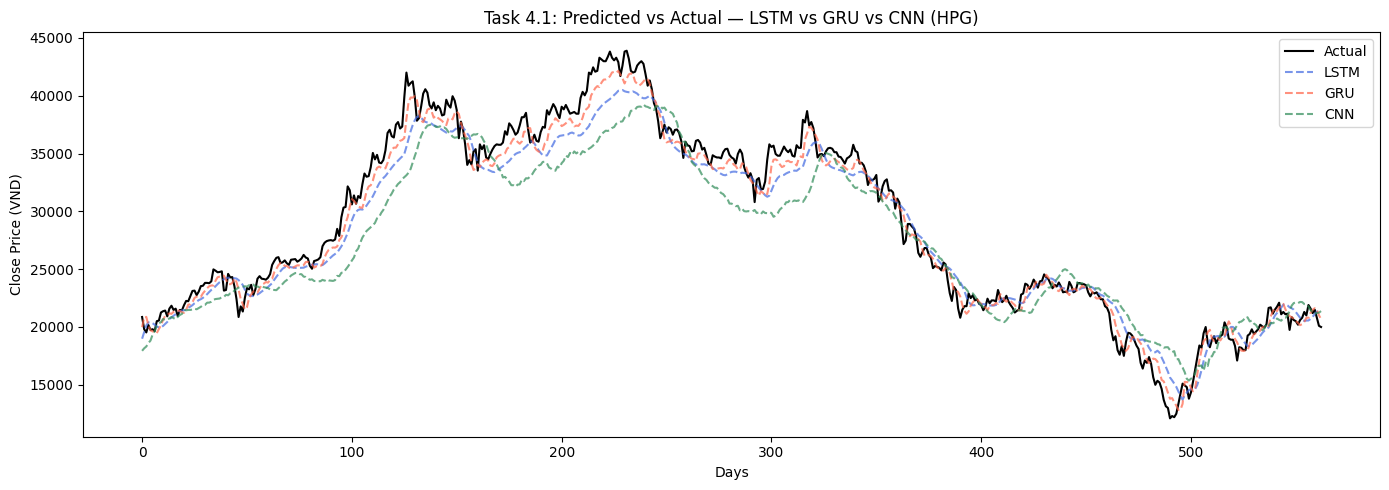

In [33]:
def build_gru_regressor(window_size, n_features, units=64, lr=1e-3):
    model = Sequential([
        GRU(units, return_sequences=True,
            input_shape=(window_size, n_features)),
        Dropout(0.2),
        GRU(units // 2, return_sequences=False),
        Dropout(0.2),
        Dense(1)
    ])
    model.compile(optimizer=Adam(lr), loss='mse', metrics=['mae'])
    return model

def build_cnn_regressor(window_size, n_features, filters=64, lr=1e-3):
    model = Sequential([
        Conv1D(filters=filters, kernel_size=3, activation='relu',
               input_shape=(window_size, n_features)),
        MaxPooling1D(pool_size=2),
        Conv1D(filters=filters // 2, kernel_size=3, activation='relu'),
        MaxPooling1D(pool_size=2),
        Flatten(),
        Dense(32, activation='relu'),
        Dropout(0.2),
        Dense(1)
    ])
    model.compile(optimizer=Adam(lr), loss='mse', metrics=['mae'])
    return model

print("Task 4.1 — Architecture Comparison: LSTM vs GRU vs CNN (HPG regression)")

arch_reg = {
    'LSTM': build_lstm_tunable(WINDOW_SIZE, len(VN_FEATURES),
                                BEST_UNITS_VN, BEST_LR_VN),
    'GRU':  build_gru_regressor(WINDOW_SIZE, len(VN_FEATURES),
                                 BEST_UNITS_VN, BEST_LR_VN),
    'CNN':  build_cnn_regressor(WINDOW_SIZE, len(VN_FEATURES),
                                 lr=BEST_LR_VN),
}

arch_reg_results  = {}
arch_reg_histories = {}

X_tr_r, y_tr_r, X_vl_r, y_vl_r, X_te_r, y_te_r, sc_r = make_dataset(
    df_vn_sample, WINDOW_SIZE, VN_FEATURES, VN_TARGET
)

for name, model in arch_reg.items():
    es = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)
    t0 = time.time()
    hist_r = model.fit(X_tr_r, y_tr_r,
                       validation_data=(X_vl_r, y_vl_r),
                       epochs=50, batch_size=32,
                       callbacks=[es], verbose=0)
    train_time = time.time() - t0
    y_pred_r  = model.predict(X_te_r, verbose=0)
    y_te_rr   = inverse_scale(sc_r, y_te_r,   vn_target_idx, len(VN_FEATURES))
    y_pr_rr   = inverse_scale(sc_r, y_pred_r, vn_target_idx, len(VN_FEATURES))
    mae_r  = mean_absolute_error(y_te_rr, y_pr_rr)
    rmse_r = np.sqrt(mean_squared_error(y_te_rr, y_pr_rr))
    arch_reg_results[name]   = {'MAE': mae_r, 'RMSE': rmse_r,
                                 'Train Time (s)': round(train_time, 1),
                                 'Params': model.count_params(),
                                 'y_true': y_te_rr, 'y_pred': y_pr_rr}
    arch_reg_histories[name] = hist_r
    print(f"  {name}: MAE={mae_r:.4f} | RMSE={rmse_r:.4f} | Time={train_time:.1f}s")

df_reg = pd.DataFrame({k: {m: v for m, v in d.items()
                             if m not in ('y_true', 'y_pred')}
                        for k, d in arch_reg_results.items()}).T
print("\n--- Task 4.1: Architecture Comparison Table ---")
print(df_reg[['MAE', 'RMSE', 'Train Time (s)', 'Params']].round(4).to_string())

# Loss curves
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, name in zip(axes, arch_reg_histories.keys()):
    h = arch_reg_histories[name]
    ax.plot(h.history['loss'],     label='Train', color='blue')
    ax.plot(h.history['val_loss'], label='Val',   color='orange')
    ax.set_title(f'{name} — Loss Curve (Task 4.1)')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE')
    ax.legend()
plt.suptitle('Task 4.1: Loss Curves — LSTM vs GRU vs CNN', fontsize=13)
plt.tight_layout()
plt.show()

# Prediction overlay
plt.figure(figsize=(14, 5))
plt.plot(arch_reg_results['LSTM']['y_true'],
         label='Actual', color='black', linewidth=1.5)
for name, color in zip(arch_reg.keys(), ['royalblue', 'tomato', 'seagreen']):
    plt.plot(arch_reg_results[name]['y_pred'],
             label=f'{name}', color=color, alpha=0.7, linestyle='--')
plt.title('Task 4.1: Predicted vs Actual — LSTM vs GRU vs CNN (HPG)')
plt.xlabel('Days')
plt.ylabel('Close Price (VND)')
plt.legend()
plt.tight_layout()
plt.show()

TASK 4.2 — Risk Scoring for Vietnam Companies


  0%|          | 0/50 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
  2%|▏         | 1/50 [00:09<07:24,  9.07s/it]/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
  4%|▍         | 2/50 [00:20<08:21, 10.44s/it]/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
  6%|▌      


Risk table built for 50 companies.
       volatility  max_drawdown   var_95  downside_dev   sharpe  lstm_error
count     50.0000       50.0000  50.0000       50.0000  50.0000     50.0000
mean       0.0266       -0.8742  -0.0444        0.0171   0.3670      0.0551
std        0.0046        0.0729   0.0065        0.0034   0.1661      0.0212
min        0.0182       -0.9814  -0.0637        0.0121  -0.1072      0.0209
25%        0.0239       -0.9289  -0.0481        0.0154   0.2740      0.0415
50%        0.0259       -0.8922  -0.0457        0.0166   0.3613      0.0567
75%        0.0294       -0.8162  -0.0407        0.0184   0.4740      0.0654
max        0.0412       -0.6562  -0.0291        0.0306   0.7974      0.1185

--- Top 10 RISKIEST companies (should EXCLUDE) ---
                volatility  max_drawdown  var_95  sharpe  risk_score
S99-HNXIndex        0.0412       -0.9814 -0.0637  0.3097      0.8922
AGF-UpcomIndex      0.0313       -0.9610 -0.0507  0.1272      0.7223
BVS-HNXIndex        0

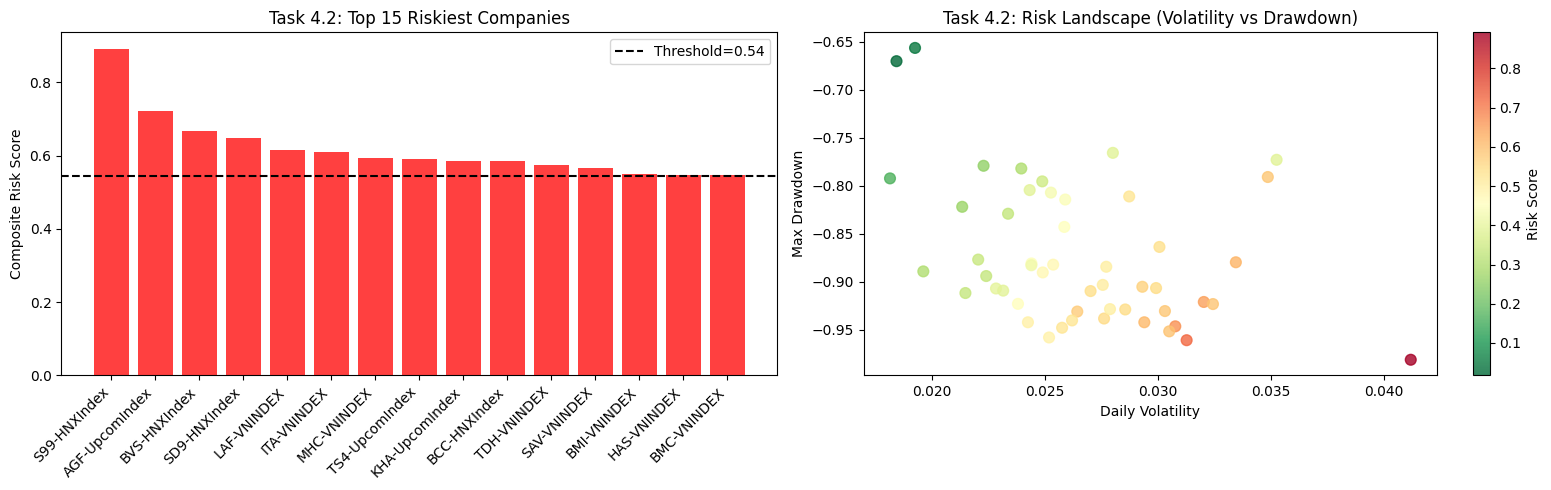

In [34]:
# ============================================================
# TASK 4.2 — Risk Management
# Goal: Score each company's risk, identify which to EXCLUDE
# Methodology: Volatility + Max Drawdown + VaR + LSTM prediction
#              error combined into a composite Risk Score
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from tensorflow.keras.callbacks import EarlyStopping

# ── Helper: compute risk metrics from price series ──────────
def compute_risk_metrics(prices: np.ndarray) -> dict:
    """
    prices: 1-D array of Close prices (chronological order)
    Returns a dict of raw risk metrics.
    """
    returns = np.diff(prices) / (prices[:-1] + 1e-9)

    # 1. Daily volatility (std of daily returns)
    volatility = float(np.std(returns))

    # 2. Maximum Drawdown
    cumulative = np.cumprod(1 + returns)
    peak = np.maximum.accumulate(cumulative)
    drawdown = (cumulative - peak) / (peak + 1e-9)
    max_drawdown = float(np.min(drawdown))       # negative value

    # 3. Value at Risk (5th percentile of daily returns — historical method)
    var_95 = float(np.percentile(returns, 5))    # negative = loss

    # 4. Downside deviation (semi-deviation below 0)
    negative_returns = returns[returns < 0]
    downside_dev = float(np.std(negative_returns)) if len(negative_returns) > 0 else 0.0

    # 5. Sharpe-like ratio (mean return / volatility, annualised)
    mean_daily_return = float(np.mean(returns))
    sharpe = (mean_daily_return / (volatility + 1e-9)) * np.sqrt(252)

    return {
        'volatility': volatility,
        'max_drawdown': max_drawdown,      # negative → deeper drawdown = worse
        'var_95': var_95,                  # negative → bigger loss = worse
        'downside_dev': downside_dev,
        'sharpe': sharpe                   # higher = better
    }


def compute_lstm_prediction_error(df, features, window_size):
    """
    Train a quick LSTM and return the normalised MAE on the test set.
    Higher error → model is uncertain about this stock → proxy for risk.
    """
    try:
        X_tr, y_tr, X_v, y_v, X_te, y_te, sc = make_dataset(
            df, window_size, features, 'Close'
        )
        if len(X_tr) < 30 or len(X_te) < 5:
            return None
        m = build_lstm_model(window_size, len(features))
        es = EarlyStopping(monitor='val_loss', patience=3,
                           restore_best_weights=True)
        m.fit(X_tr, y_tr, validation_data=(X_v, y_v),
              epochs=15, batch_size=32, callbacks=[es], verbose=0)
        y_pred = m.predict(X_te, verbose=0)
        feat_idx = features.index('Close')
        y_te_r  = inverse_scale(sc, y_te,  feat_idx, len(features))
        y_pr_r  = inverse_scale(sc, y_pred, feat_idx, len(features))
        # Normalise MAE by mean price so it's scale-independent
        norm_mae = mean_absolute_error(y_te_r, y_pr_r) / (np.mean(y_te_r) + 1e-9)
        return float(norm_mae)
    except Exception:
        return None


# ── Build risk table for all companies ──────────────────────
print("=" * 55)
print("TASK 4.2 — Risk Scoring for Vietnam Companies")
print("=" * 55)

risk_records = {}

for ticker, df_co in tqdm(vn_companies_sorted):
    try:
        df_co = add_technical_indicators(df_co)
        if len(df_co) < 200:
            continue

        prices = df_co['Close'].values

        metrics = compute_risk_metrics(prices)
        norm_mae = compute_lstm_prediction_error(df_co, VN_FEATURES, WINDOW_SIZE)
        if norm_mae is None:
            continue

        metrics['lstm_error'] = norm_mae
        risk_records[ticker] = metrics

    except Exception:
        continue

df_risk = pd.DataFrame(risk_records).T.astype(float)
print(f"\nRisk table built for {len(df_risk)} companies.")
print(df_risk.describe().round(4))


# ── Composite Risk Score (0 = safe, 1 = very risky) ─────────
#
# We normalise each metric to [0, 1] and combine:
#   • Higher volatility    → higher risk  (+)
#   • Deeper drawdown      → higher risk  (−, so negate)
#   • Worse VaR            → higher risk  (−, so negate)
#   • Higher downside_dev  → higher risk  (+)
#   • Higher lstm_error    → higher risk  (+)
#   • Higher sharpe        → LOWER risk   (−, so negate when scoring)
#
# Weights chosen to reflect financial intuition:
#   drawdown and VaR carry more weight (tail-risk matters most)

def minmax_norm(series):
    mn, mx = series.min(), series.max()
    if mx == mn:
        return pd.Series(0.5, index=series.index)
    return (series - mn) / (mx - mn)

df_risk['vol_score']      = minmax_norm(df_risk['volatility'])
df_risk['dd_score']       = minmax_norm(-df_risk['max_drawdown'])   # negate: deeper = worse
df_risk['var_score']      = minmax_norm(-df_risk['var_95'])         # negate: bigger loss = worse
df_risk['down_score']     = minmax_norm(df_risk['downside_dev'])
df_risk['sharpe_score']   = minmax_norm(-df_risk['sharpe'])         # negate: lower Sharpe = riskier
df_risk['lstm_score']     = minmax_norm(df_risk['lstm_error'])

WEIGHTS = {
    'vol_score':    0.20,
    'dd_score':     0.25,
    'var_score':    0.25,
    'down_score':   0.10,
    'sharpe_score': 0.10,
    'lstm_score':   0.10,
}

df_risk['risk_score'] = sum(
    df_risk[col] * w for col, w in WEIGHTS.items()
)

df_risk.sort_values('risk_score', ascending=False, inplace=True)

print("\n--- Top 10 RISKIEST companies (should EXCLUDE) ---")
risky_cols = ['volatility', 'max_drawdown', 'var_95', 'sharpe', 'risk_score']
print(df_risk.head(10)[risky_cols].round(4))

print("\n--- Top 10 SAFEST companies ---")
print(df_risk.tail(10)[risky_cols].round(4))

# Threshold: top-30% risk score → flag for exclusion
RISK_THRESHOLD = df_risk['risk_score'].quantile(0.70)
risky_companies = df_risk[df_risk['risk_score'] >= RISK_THRESHOLD].index.tolist()
safe_companies  = df_risk[df_risk['risk_score'] <  RISK_THRESHOLD].index.tolist()
print(f"\nRisk threshold (70th pct): {RISK_THRESHOLD:.4f}")
print(f"Companies flagged as RISKY: {len(risky_companies)}")
print(f"Companies considered SAFE:  {len(safe_companies)}")

# ── Visualise risk scores ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Bar: top 15 riskiest
top15_risky = df_risk.head(15)
axes[0].bar(range(len(top15_risky)), top15_risky['risk_score'],
            color='red', alpha=0.75)
axes[0].axhline(RISK_THRESHOLD, color='black', linestyle='--',
                label=f'Threshold={RISK_THRESHOLD:.2f}')
axes[0].set_xticks(range(len(top15_risky)))
axes[0].set_xticklabels(top15_risky.index, rotation=45, ha='right')
axes[0].set_title('Task 4.2: Top 15 Riskiest Companies')
axes[0].set_ylabel('Composite Risk Score')
axes[0].legend()

# Scatter: volatility vs max drawdown, colour = risk score
sc_plot = axes[1].scatter(
    df_risk['volatility'],
    df_risk['max_drawdown'],
    c=df_risk['risk_score'],
    cmap='RdYlGn_r',
    s=60, alpha=0.8
)
plt.colorbar(sc_plot, ax=axes[1], label='Risk Score')
axes[1].set_xlabel('Daily Volatility')
axes[1].set_ylabel('Max Drawdown')
axes[1].set_title('Task 4.2: Risk Landscape (Volatility vs Drawdown)')

plt.tight_layout()
plt.show()


TASK 4.3 — Portfolio Composition

Investable universe after risk filter: 35 companies

--- Strategy A: Risk-Taking Portfolio (top 10) ---
              actual_return  volatility  sharpe  score_aggressive
TMS-VNINDEX          2.2380      0.0287  0.5359            0.9205
GMD-VNINDEX          1.7559      0.0228  0.4824            0.7656
REE-VNINDEX          1.3004      0.0221  0.6609            0.6890
VSH-VNINDEX          1.2436      0.0353  0.4801            0.6177
FPT-VNINDEX          1.2749      0.0196  0.4419            0.6151
PVD-VNINDEX          1.3129      0.0270  0.1975            0.5516
KDC-VNINDEX          0.8298      0.0215  0.6084            0.5378
STB-VNINDEX          1.0386      0.0234  0.3266            0.5121
SJS-VNINDEX          0.8053      0.0279  0.5365            0.5089
PLC-HNXIndex         0.6697      0.0301  0.4346            0.4389

--- Strategy B: Prudent Portfolio (top 10) ---
             actual_return  volatility  sharpe  score_prudent
REE-VNINDEX         1.300

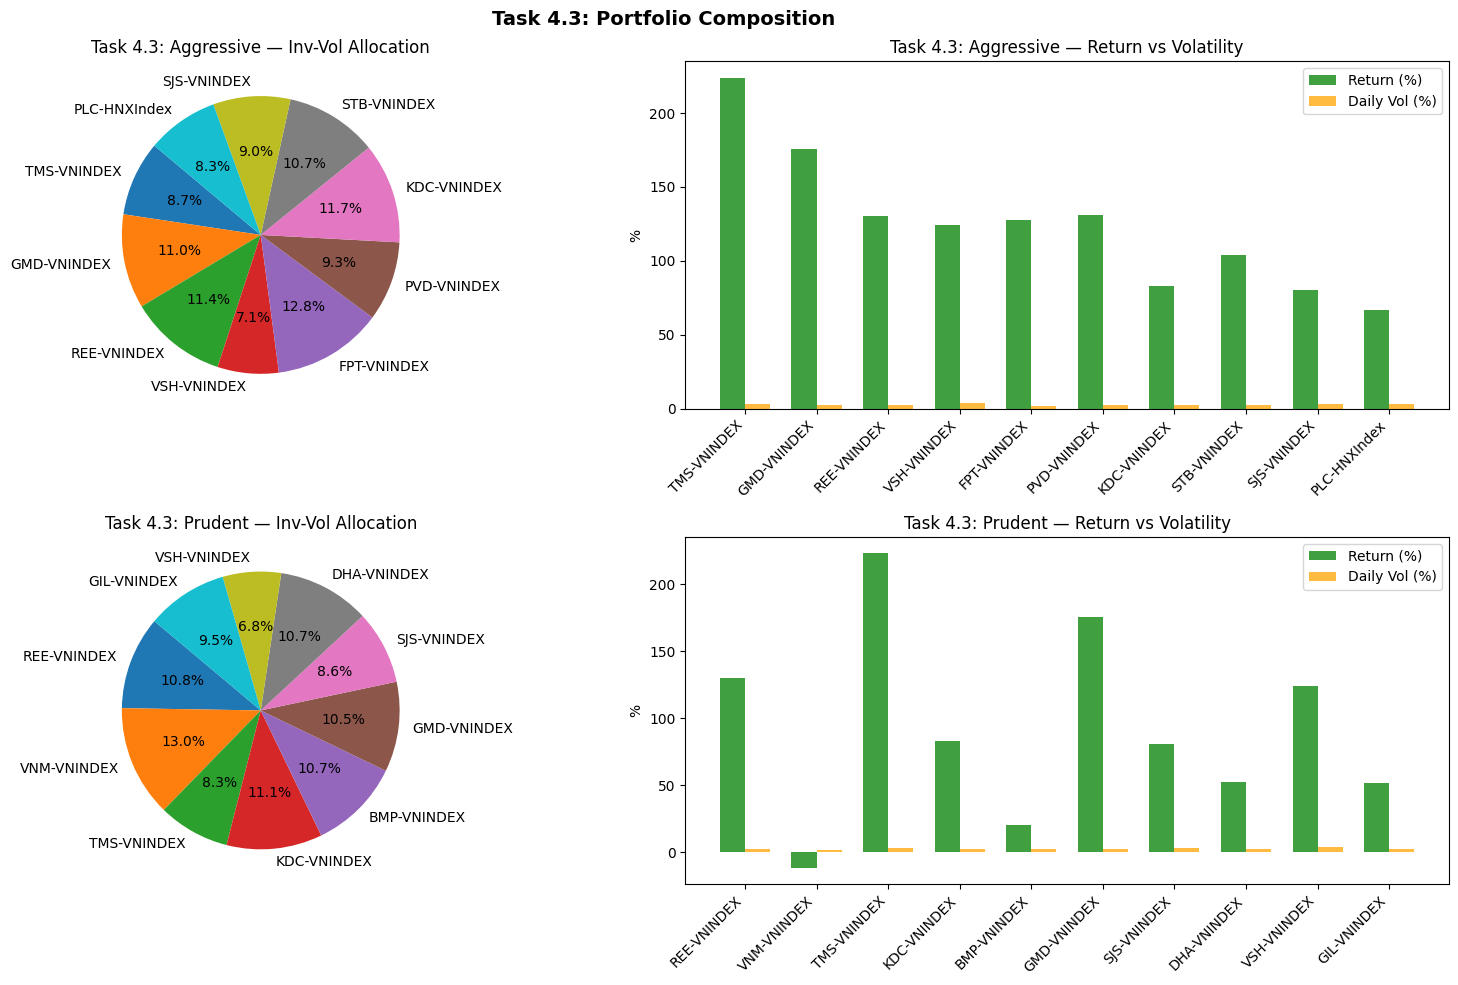


--- Portfolio Summary Comparison ---
  Strategy  Avg Return (%)  Avg Volatility (%)  Avg Sharpe  Avg Risk Score
Aggressive        124.6905              2.5836      0.4705          0.4189
   Prudent         92.8952              2.4667      0.5857          0.3518


In [35]:
# ============================================================
# TASK 4.3 — Portfolio Composition
# Goal: Combine profitability (Task 4.1) + risk (Task 4.2)
#       to build an optimal portfolio using two strategies:
#         A) Risk-taking investor  → prioritise return
#         B) Prudent investor      → prioritise risk-adjusted return
# ============================================================

print("\n" + "=" * 55)
print("TASK 4.3 — Portfolio Composition")
print("=" * 55)

# ── Merge profit + risk tables ───────────────────────────────
# df_results was built in Task 4.1 (actual/predicted return, volatility)
# df_risk  was built in Task 4.2 (risk_score, sharpe, …)

df_portfolio = df_results[['actual_return', 'predicted_return', 'mae']].copy()
df_portfolio = df_portfolio.join(
    df_risk[['volatility', 'max_drawdown', 'sharpe', 'risk_score']],
    how='inner'
)
df_portfolio.dropna(inplace=True)

# Exclude companies flagged as risky from the investable universe
df_investable = df_portfolio[~df_portfolio.index.isin(risky_companies)].copy()
print(f"\nInvestable universe after risk filter: {len(df_investable)} companies")

# ── Score each company ───────────────────────────────────────
df_investable['return_score'] = minmax_norm(df_investable['actual_return'])
df_investable['risk_adj_score'] = minmax_norm(df_investable['sharpe'])   # Sharpe = return/risk

# Strategy A: Risk-taking → weight return 80%, risk 20%
df_investable['score_aggressive'] = (
    0.80 * df_investable['return_score'] +
    0.20 * df_investable['risk_adj_score']
)

# Strategy B: Prudent → weight Sharpe 70%, return 30%
df_investable['score_prudent'] = (
    0.30 * df_investable['return_score'] +
    0.70 * df_investable['risk_adj_score']
)

TOP_N = 10  # portfolio size

portfolio_aggressive = df_investable.nlargest(TOP_N, 'score_aggressive')
portfolio_prudent    = df_investable.nlargest(TOP_N, 'score_prudent')

print(f"\n--- Strategy A: Risk-Taking Portfolio (top {TOP_N}) ---")
print(portfolio_aggressive[['actual_return', 'volatility', 'sharpe',
                              'score_aggressive']].round(4))

print(f"\n--- Strategy B: Prudent Portfolio (top {TOP_N}) ---")
print(portfolio_prudent[['actual_return', 'volatility', 'sharpe',
                           'score_prudent']].round(4))


# ── Mean-Variance weight allocation (Equal Risk Contribution) ─
def equal_risk_contribution_weights(vols: np.ndarray) -> np.ndarray:
    """
    Simple ERC: allocate inversely proportional to volatility.
    Lower-volatility stocks get higher weight.
    """
    inv_vol = 1.0 / (vols + 1e-9)
    return inv_vol / inv_vol.sum()


def inverse_vol_weights(vols: np.ndarray) -> np.ndarray:
    """Alias — same as ERC for this case."""
    return equal_risk_contribution_weights(vols)


def equal_weights(n: int) -> np.ndarray:
    return np.ones(n) / n


for strategy_name, port_df, score_col in [
    ("Risk-Taking (Aggressive)", portfolio_aggressive, 'score_aggressive'),
    ("Prudent (Conservative)",   portfolio_prudent,    'score_prudent'),
]:
    print(f"\n{'─'*50}")
    print(f"Portfolio: {strategy_name}")

    vols = port_df['volatility'].values

    # Two allocation methods
    w_equal   = equal_weights(len(port_df))
    w_inv_vol = inverse_vol_weights(vols)

    # Expected portfolio metrics (using actual test returns as proxy)
    rets = port_df['actual_return'].values

    port_return_eq    = float(np.dot(w_equal,   rets))
    port_return_iv    = float(np.dot(w_inv_vol, rets))
    port_vol_eq       = float(np.dot(w_equal,   vols))
    port_vol_iv       = float(np.dot(w_inv_vol, vols))
    sharpe_eq         = port_return_eq / (port_vol_eq + 1e-9) * np.sqrt(252)
    sharpe_iv         = port_return_iv / (port_vol_iv + 1e-9) * np.sqrt(252)

    print(f"  Equal weight     → Return={port_return_eq*100:.2f}%  "
          f"Vol={port_vol_eq*100:.2f}%  Sharpe={sharpe_eq:.2f}")
    print(f"  Inv-vol weight   → Return={port_return_iv*100:.2f}%  "
          f"Vol={port_vol_iv*100:.2f}%  Sharpe={sharpe_iv:.2f}")

    # Pick best allocation
    best_weights = w_inv_vol if sharpe_iv >= sharpe_eq else w_equal
    best_label   = "Inv-vol" if sharpe_iv >= sharpe_eq else "Equal"
    print(f"  → Best allocation: {best_label}")
    for ticker, w in zip(port_df.index, best_weights):
        print(f"     {ticker}: {w*100:.1f}%")


# ── Visualise both portfolios ────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for row, (strategy_name, port_df, score_col) in enumerate([
    ("Aggressive", portfolio_aggressive, 'score_aggressive'),
    ("Prudent",    portfolio_prudent,    'score_prudent'),
]):
    vols    = port_df['volatility'].values
    w_alloc = inverse_vol_weights(vols)

    # Pie chart — allocation
    axes[row, 0].pie(
        w_alloc,
        labels=port_df.index,
        autopct='%1.1f%%',
        startangle=140,
        colors=plt.cm.tab10.colors[:len(port_df)]
    )
    axes[row, 0].set_title(f'Task 4.3: {strategy_name} — Inv-Vol Allocation')

    # Bar chart — return vs volatility
    x = np.arange(len(port_df))
    w = 0.35
    axes[row, 1].bar(x - w/2, port_df['actual_return'] * 100,
                     w, label='Return (%)', color='green', alpha=0.75)
    axes[row, 1].bar(x + w/2, port_df['volatility'] * 100,
                     w, label='Daily Vol (%)', color='orange', alpha=0.75)
    axes[row, 1].set_xticks(x)
    axes[row, 1].set_xticklabels(port_df.index, rotation=45, ha='right')
    axes[row, 1].set_title(f'Task 4.3: {strategy_name} — Return vs Volatility')
    axes[row, 1].set_ylabel('%')
    axes[row, 1].legend()

plt.suptitle('Task 4.3: Portfolio Composition', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Summary comparison table ─────────────────────────────────
print("\n--- Portfolio Summary Comparison ---")
summary = pd.DataFrame({
    'Strategy':       ['Aggressive', 'Prudent'],
    'Avg Return (%)': [
        portfolio_aggressive['actual_return'].mean() * 100,
        portfolio_prudent['actual_return'].mean() * 100,
    ],
    'Avg Volatility (%)': [
        portfolio_aggressive['volatility'].mean() * 100,
        portfolio_prudent['volatility'].mean() * 100,
    ],
    'Avg Sharpe': [
        portfolio_aggressive['sharpe'].mean(),
        portfolio_prudent['sharpe'].mean(),
    ],
    'Avg Risk Score': [
        portfolio_aggressive['risk_score'].mean(),
        portfolio_prudent['risk_score'].mean(),
    ],
})
print(summary.round(4).to_string(index=False))

In [37]:
import pickle, shutil, json

# Export model
best_config_2_1['model'].save("best_lstm_vn.keras")
shutil.make_archive("best_lstm_vn", "zip", ".", "best_lstm_vn.keras")

# Export scaler
with open("scaler_vn.pkl", "wb") as f:
    pickle.dump(sc_vn, f)

# Export VN_FEATURES
with open("vn_features.json", "w") as f:
    json.dump(VN_FEATURES, f)

print("Done! Download 3 files:")
print("  - best_lstm_vn.zip")
print("  - scaler_vn.pkl")
print("  - vn_features.json")

Done! Download 3 files:
  - best_lstm_vn.zip
  - scaler_vn.pkl
  - vn_features.json
